In [91]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import itertools
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import scipy.stats as stats
import statsmodels.stats.multitest as multitest

sns.set(font_scale=2) 
sns.set_style("ticks")
import warnings
warnings.filterwarnings("ignore")

warm_gray = (190/255, 184/255, 177/255)
cool_gray = (119/255, 136/255, 153/255)
dual = ['#B9529F','gray']
triple = ['gray','Tab:red', 'Tab:blue']
ZD = {'Pre':'gray', 'Agg+': 'Tab:red', 'ZD7288': warm_gray}
triple_ff = ['gray', 'Tab:red','Tab:blue']
sixtus = ['gray', 'Tab:red', 'Tab:blue','gray', 'Tab:red', 'gray']
six = ['gray', 'Tab:red', 'Tab:blue','gray', 'gray', 'Tab:red']
seven = ['gray', 'Tab:red', 'Tab:blue','gray', 'gray', 'Tab:red', 'Tab:red']
nine = ['gray', 'Tab:red', 'Tab:blue','gray', 'gray', 'Tab:red', 'Tab:red', 'Tab:red', 'Tab:red']
npy = ['gray','darkgreen']
agrp = ['gray','tab:brown']
ant = ['Tab:red', 'Tab:red','Tab:red', 'Tab:red']

In [2]:
def preprocess_plot(df, cat_name , name,  palette, order, plotting = False):
    ls = ['Cm(pF)', 'Firing_freq_(Hz)_I0','Instant_freq_(Hz)', 'isi_(ms)',  'CaT',  'Ih_at_-120mV', 'AP_ampl', 'AP_halfwidth', 'AP_time_to_peak','area(mV_ms)', 'rheobase_at_-60mV_(pA)', 'AHP_(mV)', 'Vm',
       'Input_Resistance', 'sPSC_frequency', 'sPSC_Amplitude(pA)','sPSCs_Rise time', 'sPSCs (decay)']

    for column in ls:
        df[column] = pd.to_numeric(df[column])

        if column in ['isi_(ms)', 'AP_ampl', 'AP_halfwidth', 'AP_time_to_peak','area(mV_ms)', 'AHP_(mV)']:
            param_df = df[df.I_zero != 'silent']
        
        
        else:
            param_df = df
        
        try:
            unique_cat = df[cat_name].unique()
            combos = list(itertools.combinations(unique_cat, 2))

            for combo in combos:
                should_plot = False
                # _, p = stats.ttest_ind(param_df[(param_df[cat_name] == combo[0])][column].dropna(),
                #                         param_df[(param_df[cat_name] == combo[1])][column].dropna(),
                #                     equal_var = False)

                _, p = stats.mannwhitneyu(param_df[(param_df[cat_name] == combo[0])][column].dropna(),
                                        param_df[(param_df[cat_name] == combo[1])][column].dropna())
            
                print(column, combo, p)
               

           
        except ValueError:
            
            continue

        if plotting:
            try:
                print(param_df.groupby(cat_name)[column].mean())
                

                sns.set(rc={"figure.figsize": (3, 3)})
                sns.set(font_scale=2.5) 
                sns.set_style("ticks")

                ax = sns.boxplot(x=cat_name, y=column, data = param_df, order = order, palette = palette, 
                                saturation=8, linewidth=1.7, showfliers = False, boxprops=dict(alpha=0.5))
                ax = sns.stripplot(x=cat_name, y=column, data = param_df, order=order, 
                                jitter=True, dodge=False, marker='o', size=7, linewidth=1, edgecolor='gray', palette = palette, alpha=0.5, zorder=0)
                ax.set_xlabel('')
                ax.set_xticklabels( ('Pre', 'Agg+', 'Agg-',  'Y-KD') , rotation=45)
                ax.yaxis.set_major_locator(plt.MaxNLocator(2))
                plt.ylabel(column.replace('_', ' '))

                sns.despine()
                
                plt.savefig(f'output_figures/{column}.png',
                    dpi=300,bbox_inches='tight', transparent=True)
                plt.savefig(f'/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Figure_3/linked_figure3/{column}.pdf',
                    dpi=300,bbox_inches='tight', transparent=True)
                plt.show()
            except KeyError:
                pass
                

def proportion(df, column1, column2, cols):
    prop = pd.crosstab(df[column1], df[column2], margins = True).reset_index()
    prop = prop.set_index(column1)
    print(prop)
    prop = prop.iloc[:-1, :-1]
    stat, p, dof, expected  = stats.chi2_contingency(prop)
    print(p)
    
    prop = prop.apply(lambda x: x.div(x.sum()).mul(100), axis=1)
    
    
    prop = prop[cols]
    prop = prop.reset_index()
    return prop

def prop_plot(df, column):
    df.plot(x = column, 
              kind = 'bar', 
              stacked = True,  
              mark_right = False,
              color = ['black', 'darkgray','gray'],
              figsize = (3,5), alpha = 0.7)
    plt.xticks(rotation = 0)
    ax = plt.gca()
    plt.ylabel('Percentage (%)')
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)

def remove_outlier(df_in, col_name):
    q1 = df_in[col_name].quantile(0.25)
    q3 = df_in[col_name].quantile(0.75)
    iqr = q3-q1 #Interquartile range
    fence_low  = q1-1.5*iqr
    fence_high = q3+1.5*iqr
    df_out = df_in.loc[(df_in[col_name] > fence_low) & (df_in[col_name] < fence_high)]
    return df_out

# Ephys analysis

In [3]:
ls = ['Cm(pF)', 'Firing_freq_(Hz)_I0','Instant_freq_(Hz)', 'isi_(ms)',  'CaT',  'Ih_at_-120mV', 'AP_ampl', 'AP_halfwidth', 'AP_time_to_peak','area(mV_ms)', 'rheobase_at_-60mV_(pA)', 'AHP_(mV)', 'Vm',
       'Input_Resistance', 'sPSC_frequency', 'sPSC_Amplitude(pA)','sPSCs_Rise time', 'sPSCs (decay)']

include_gal = True

df = pd.read_csv('ephys_analysis_MC.csv')
df['experiment_day'] = df['experiment_day'].apply(lambda x: str(x).upper()[:13])
df.loc[df.Behaviour_6hFD =='No_FD','Behaviour_6hFD'] = 'Pre'
# df.loc[df.Behaviour_6hFD.isin(['Agg+', 'Agg-']),'Behaviour_6hFD'] = 'Post'
df.rename(columns = {'Instant_freq_(Hz)_1/ISI':'Instant_freq_(Hz)'}, inplace =True)


cat = df.Behaviour_6hFD.unique()

if include_gal:
       gal = df[(df.Gal_positive == 'yes') & (df.Behaviour_6hFD == 'Pre')] 
       no_gal = df[(df.Gal_positive == 'no') & (df.Behaviour_6hFD == 'Pre')]
       
       ephys = pd.concat([df[(df.Gal_positive.isin(['Unknown','no']) & (df.Behaviour_6hFD == 'Pre'))], df[(df.Gal_positive == 'Unknown') & (df.Behaviour_6hFD != 'Pre')]])
       sample_num= int(no_gal.shape[0]/4)
       ephys = pd.concat([ephys, gal.sample(n = sample_num, random_state = 62)]).reset_index(drop = True)

else:
       ephys = df[df.Gal_positive == 'Unknown']
  
# ephys.loc[ephys.Behaviour_6hFD.isin([ 'npy_100_paired']),'Behaviour_6hFD'] = 'npy_100'
     
# ephys.loc[ephys.Behaviour_6hFD.isin(['npy_10', 'npy_100']),'Behaviour_6hFD'] = 'npy'

ephys.to_csv('sampled_ephys_data.csv')

In [4]:
behav = pd.read_csv('ephys_behav.csv')
ephys_behav = pd.merge(ephys, behav, on  = 'ID_mouse')
ephys_behav.columns = [col.replace('(', '_').replace(')', '_') for col in ephys_behav.columns]
ephys_behav.columns = [col.replace(' ', '_').replace('-', '_') for col in ephys_behav.columns]

In [5]:
percent_columns = ['Ih_at__120mV', 'CaT', 'Adaptive', 'Firing_freq__Hz__I0'] 
percentages_df = pd.DataFrame(index=ephys_behav['ID_mouse'].unique())

for column in percent_columns:
    percentages = ephys_behav.groupby('ID_mouse')[column].apply(lambda x: (x == 0).sum() / len(x) * 100)
    percentages_df[column + '_percent_nonzero'] = percentages

silent_percentages = ephys_behav.groupby('ID_mouse')['I_zero_reclassified'].apply(lambda x: (x == 'silent').sum() / len(x) * 100).reset_index(name='I_zero_reclassified' + '_percent_silent')
percentages_df = percentages_df.reset_index()
percentages_df.rename(columns={'index': 'ID_mouse'}, inplace=True)
percentages_df = pd.merge(percentages_df, silent_percentages, on='ID_mouse', how='outer')

percentages_df = pd.merge(percentages_df, behav, on = 'ID_mouse')




In [6]:
for y in percentages_df.columns[1:-6]:
    if y != 'attack_since_contact':  # Skip the contact_latency column
        formula = 'attack_since_contact ~ ' + y
        try:
            model = smf.ols(formula, data=percentages_df).fit()
            anova_results = sm.stats.anova_lm(model, typ=2)
            
            if model.pvalues[y] <0.05:
                print(model.pvalues[y], y, model.rsquared)

                sns.lmplot(x = 'attack_since_contact', y = y, data = percentages_df)
           
        except Exception as e:
            continue

0.01944928104928148 sPSC_Amplitude_pA_ 0.31337716718782116


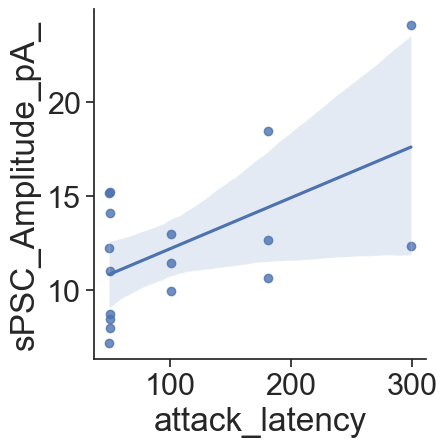

In [7]:
#ephys correlation with behaviour metric
for y in ephys_behav.columns[8:-8]:
    if y != 'contact_latency':  # Skip the contact_latency column
        formula = 'attack_latency ~ ' + y
        try:
            model = smf.ols(formula, data=ephys_behav).fit()
            anova_results = sm.stats.anova_lm(model, typ=2)
            
            if model.pvalues[y] <0.05:
                print(model.pvalues[y], y, model.rsquared)

                sns.lmplot(x = 'attack_latency', y = y, data = ephys_behav)
                plt.show()
           
        except Exception as e:
            continue
    

In [8]:
ephys.Behaviour_6hFD.unique()

array(['Pre', 'Agg+', 'Agg-', 'npy_antag', 'npy1r_antag', 'npy2r_antag',
       'npy_10_paired', 'npy_10', 'npy_100_paired', 'npy_100', 'agrp_100',
       'ZD7288', 'ZD7288_20', 'npykd'], dtype=object)

## All properties

In [9]:
# filter_cat = ['Pre', 'Agg+', 'Agg-', 'npy_10', 'npy_antag', 'npy1r_antag', 'npy2r_antag' ,'ZD7288']

# # set categorical variables
# ephys['Behaviour_6hFD'] = pd.Categorical(ephys['Behaviour_6hFD'], categories=filter_cat, ordered=True)


# preprocess_plot(ephys[ephys.Behaviour_6hFD.isin(filter_cat)],'Behaviour_6hFD', 'pan', 
#                 palette=['Gray', 'Tab:red', 'Tab:Blue', 'Gray', 'Tab:red', 'Tab:red', 'Gray'], order = filter_cat,
#                   plotting= True)


## Individual plots - panMPOA

In [10]:
# subset df for those groups needed for firing freq. plot
ephys2 = ephys.loc[(ephys['Behaviour_6hFD'] == 'Pre') | (ephys['Behaviour_6hFD'] == 'Agg-') |(ephys['Behaviour_6hFD'] == 'Agg+')]

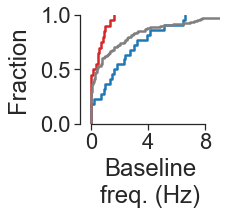

In [11]:
# Firing frequency

sns.set(rc={"figure.figsize": (2.5, 2.0)})
sns.set(font_scale=2) 
sns.set_style("ticks")

cum = sns.ecdfplot(data=ephys2, x="Firing_freq_(Hz)_I0", hue="Behaviour_6hFD", palette = triple_ff, linewidth=2.5, legend=False,
                   stat='proportion')
cum.set_xlabel('Baseline\nfreq. (Hz)',labelpad=5)
cum.set_ylabel('Fraction',labelpad=10)
cum.xaxis.set_major_locator(plt.MaxNLocator(3))
plt.xlim(right=9)
sns.despine(trim=True)

plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Figure_3/linked_figure3/ff.pdf',
            dpi=300,bbox_inches='tight', transparent=True)

In [12]:
# mouse and cell numbers
filtered = ephys2.dropna(subset=['Firing_freq_(Hz)_I0'])
mouse_counts = filtered.groupby('Behaviour_6hFD')['ID_mouse'].nunique()
print(f"\033[1mMouse numbers:\033[0m\n \n{mouse_counts}") 
cell_counts = ephys2.groupby('Behaviour_6hFD')['Firing_freq_(Hz)_I0'].count()
print(f"\n\033[1mCell counts:\033[0m\n \n{cell_counts}")

Mouse numbers:
 
Behaviour_6hFD
Agg+     6
Agg-     3
Pre     17
Name: ID_mouse, dtype: int64

Cell counts:
 
Behaviour_6hFD
Agg+     20
Agg-     22
Pre     105
Name: Firing_freq_(Hz)_I0, dtype: int64


In [13]:
# Stats
ephys2_pre = ephys2.loc[ephys2['Behaviour_6hFD'] == 'Pre', 'Firing_freq_(Hz)_I0'].dropna()
ephys2_agg = ephys2.loc[ephys2['Behaviour_6hFD'] == 'Agg+', 'Firing_freq_(Hz)_I0'].dropna()
ephys2_noagg = ephys2.loc[ephys2['Behaviour_6hFD'] == 'Agg-', 'Firing_freq_(Hz)_I0'].dropna()

from scipy.stats import mannwhitneyu

# Pre vs Agg+
u_statistic, p_value = mannwhitneyu(ephys2_pre, ephys2_agg)
print("Mann-Whitney U Statistic:", u_statistic)
print("P-value Pre vs Agg+:", p_value)
# Pre vs Agg-
u_statistic, p_value = mannwhitneyu(ephys2_pre, ephys2_noagg)
print("Mann-Whitney U Statistic:", u_statistic)
print("P-value Pre vs Agg-:", p_value)
# Agg- vs Agg+
u_statistic, p_value = mannwhitneyu(ephys2_noagg, ephys2_agg)
print("Mann-Whitney U Statistic:", u_statistic)
print("P-value Agg- vs Agg+:", p_value)

Mann-Whitney U Statistic: 1328.0
P-value Pre vs Agg+: 0.05827899141391609
Mann-Whitney U Statistic: 850.0
P-value Pre vs Agg-: 0.050500440681557957
Mann-Whitney U Statistic: 352.5
P-value Agg- vs Agg+: 0.0007392103156646884


In [14]:
# stats - one-way ANOVA
from scipy.stats import f_oneway

filtered_groups = ['Pre', 'Agg+', 'Agg-']
ephys_filtered = ephys2[ephys2['Behaviour_6hFD'].isin(filtered_groups)]
ephys_filtered = ephys_filtered.dropna(subset=['Behaviour_6hFD', 'Firing_freq_(Hz)_I0'])
groups = ephys_filtered.groupby('Behaviour_6hFD')['Firing_freq_(Hz)_I0'].apply(lambda x: x.dropna().tolist())
anova_result = f_oneway(*groups)
print("One-way ANOVA p-value:", anova_result.pvalue)

# Tukey HSD
tukey_results = pairwise_tukeyhsd(ephys_filtered['Firing_freq_(Hz)_I0'], ephys_filtered['Behaviour_6hFD'])
print(tukey_results)

One-way ANOVA p-value: 0.043543836800807964
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
  Agg+   Agg-   1.7918 0.0413  0.0565 3.5271   True
  Agg+    Pre   1.2215 0.0912 -0.1488 2.5918  False
  Agg-    Pre  -0.5703  0.562 -1.8872 0.7467  False
---------------------------------------------------


In [15]:
# subset df for those groups needed for firing freq. plot - ALL GROUPS
ephys2_all = ephys.loc[(ephys['Behaviour_6hFD'] == 'Pre') | (ephys['Behaviour_6hFD'] == 'Agg-') |(ephys['Behaviour_6hFD'] == 'Agg+') |
                      (ephys['Behaviour_6hFD'] == 'npy_antag') | (ephys['Behaviour_6hFD'] == 'npy_KD_dummy') |(ephys['Behaviour_6hFD'] == 'ZD7288')]

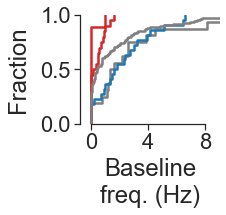

In [16]:
# Firing frequency - VERSION WITH ALL GROUPS

sns.set(rc={"figure.figsize": (2.5, 2.0)})
sns.set(font_scale=2) 
sns.set_style("ticks")

cum = sns.ecdfplot(data=ephys2_all, x="Firing_freq_(Hz)_I0", hue="Behaviour_6hFD", palette = sixtus, linewidth=2.5, legend=False, stat='proportion')
cum.set_xlabel('Baseline\nfreq. (Hz)',labelpad=5)
cum.set_ylabel('Fraction',labelpad=10)
cum.xaxis.set_major_locator(plt.MaxNLocator(3))
plt.xlim(right=9)
sns.despine(trim=True)

# plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Figure_3/linked_figure3/ff_all.pdf',
#             dpi=300,bbox_inches='tight', transparent=True)

In [17]:
# subset df for ZD
ephys2_zd = ephys.loc[(ephys['Behaviour_6hFD'] == 'Pre') | (ephys['Behaviour_6hFD'] == 'Agg+') |(ephys['Behaviour_6hFD'] == 'ZD7288')]

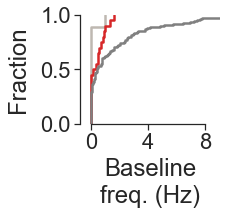

In [18]:
# Firing frequency - ZD

sns.set(rc={"figure.figsize": (2.5, 2.0)})
sns.set(font_scale=2) 
sns.set_style("ticks")

cum = sns.ecdfplot(data=ephys2_zd, x="Firing_freq_(Hz)_I0", hue="Behaviour_6hFD", palette = ZD, linewidth=2.5, legend=False, stat='proportion')
cum.set_xlabel('Baseline\nfreq. (Hz)',labelpad=5)
cum.set_ylabel('Fraction',labelpad=10)
cum.xaxis.set_major_locator(plt.MaxNLocator(3))
plt.xlim(right=9)
sns.despine(trim=True)

plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Figure_3/linked_figure3/ff_zd.pdf',
            dpi=300,bbox_inches='tight', transparent=True)

In [19]:
# subset df for Agg+/KD
ephys2_kd = ephys.loc[(ephys['Behaviour_6hFD'] == 'Agg+') |(ephys['Behaviour_6hFD'] == 'npykd')]

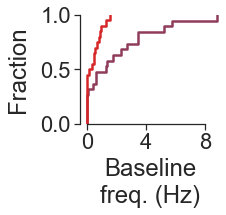

In [20]:
sns.set(rc={"figure.figsize": (2.5, 2.0)})
sns.set(font_scale=2) 
sns.set_style("ticks")

cum = sns.ecdfplot(data=ephys2_kd, x="Firing_freq_(Hz)_I0", hue="Behaviour_6hFD", palette = ['Tab:red', '#8F3B5A'], linewidth=2.5, legend=False,
                   stat='proportion')
cum.set_xlabel('Baseline\nfreq. (Hz)',labelpad=5)
cum.set_ylabel('Fraction',labelpad=10)
cum.xaxis.set_major_locator(plt.MaxNLocator(3))
plt.xlim(right=9)
sns.despine(trim=True)

# plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Figure_3/linked_figure3/ff_kd.pdf',
#             dpi=300,bbox_inches='tight', transparent=True)

In [21]:
# Stats
ephys2_kd_agg = ephys2_kd.loc[ephys2_kd['Behaviour_6hFD'] == 'Agg+', 'Firing_freq_(Hz)_I0'].dropna()
ephys2_kd_y = ephys2_kd.loc[ephys2_kd['Behaviour_6hFD'] == 'npykd', 'Firing_freq_(Hz)_I0'].dropna()

u_statistic, p_value = mannwhitneyu(ephys2_kd_agg, ephys2_kd_y)
print("Mann-Whitney U Statistic:", u_statistic)
print("P-value Pre vs Agg+:", p_value)

Mann-Whitney U Statistic: 112.5
P-value Pre vs Agg+: 0.026735672074107823


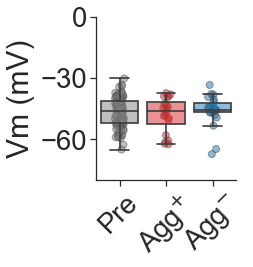

In [22]:
# Membrane voltage / RMP

sns.set(rc={"figure.figsize": (2.5, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

ax = sns.boxplot(x='Behaviour_6hFD', y='Vm', data = ephys, order=['Pre', 'Agg+', 'Agg-'], saturation=8, 
                 linewidth=1.7, showfliers = False, palette = triple)
ax = sns.stripplot(x='Behaviour_6hFD', y='Vm', data = ephys, order=['Pre', 'Agg+', 'Agg-'], jitter=True, dodge=False, 
                   marker='o', size=7, linewidth=1, edgecolor='gray', palette = triple, alpha=0.5, zorder=0)
ax.set_xlabel('')
ax.set_ylabel('Vm (mV)', labelpad=5)

ax.set_xticklabels(('Pre', r'Agg$^{+}$', r'Agg$^{-}$'), rotation=45)

ax.yaxis.set_major_locator(plt.MaxNLocator(3))
plt.ylim(-80, 0)
sns.despine(bottom=False, trim=False)

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, .5))
    
# plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Figure_3/linked_figure3/Vm.pdf',
#             dpi=300,bbox_inches='tight', transparent=True)

In [23]:
ephys.Behaviour_6hFD.unique()

array(['Pre', 'Agg+', 'Agg-', 'npy_antag', 'npy1r_antag', 'npy2r_antag',
       'npy_10_paired', 'npy_10', 'npy_100_paired', 'npy_100', 'agrp_100',
       'ZD7288', 'ZD7288_20', 'npykd'], dtype=object)

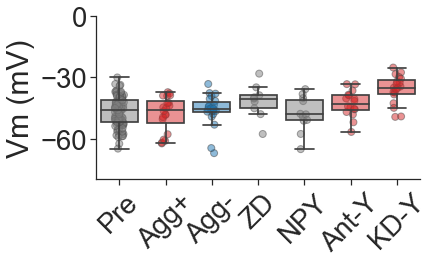

In [24]:
# Membrane voltage / RMP - VERSION WITH ALL GROUPS

sns.set(rc={"figure.figsize": (5.8, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

ax = sns.boxplot(x='Behaviour_6hFD', y='Vm', data = ephys, order=['Pre', 'Agg+', 'Agg-', 'ZD7288', 'npy_100','npy_antag', 'npykd'], saturation=8, 
                 linewidth=1.7, showfliers = False, palette = seven)
ax = sns.stripplot(x='Behaviour_6hFD', y='Vm', data = ephys, order=['Pre', 'Agg+', 'Agg-', 'ZD7288', 'npy_100','npy_antag', 'npykd'], jitter=True, 
                   dodge=False, marker='o', size=7, linewidth=1, edgecolor='gray', palette = seven, alpha=0.5, zorder=0)
ax.set_xlabel('')
ax.set_ylabel('Vm (mV)', labelpad=5)

ax.set_xticklabels( ('Pre', 'Agg+', 'Agg-', 'ZD','NPY','Ant-Y', 'KD-Y'), rotation=45)
ax.yaxis.set_major_locator(plt.MaxNLocator(3))
plt.ylim(-80, 0)
sns.despine(bottom=False, trim=False)

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, .5))
    
# plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Figure_3/linked_figure3/Vm_all.pdf',
#             dpi=300,bbox_inches='tight', transparent=True)

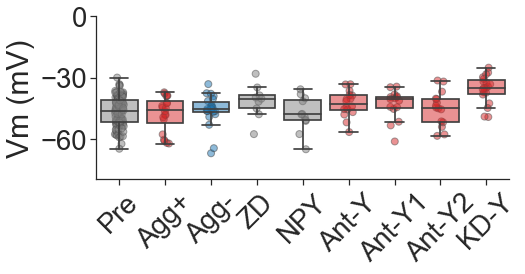

In [25]:
# Membrane voltage / RMP - VERSION WITH ALL GROUPS INCL. Y1/Y2 ANT

sns.set(rc={"figure.figsize": (7.4, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

ax = sns.boxplot(x='Behaviour_6hFD', y='Vm', data = ephys, order=['Pre', 'Agg+', 'Agg-', 'ZD7288', 'npy_100','npy_antag', 'npy1r_antag', 'npy2r_antag','npykd'], saturation=8, 
                 linewidth=1.7, showfliers = False, palette = nine)
ax = sns.stripplot(x='Behaviour_6hFD', y='Vm', data = ephys, order=['Pre', 'Agg+', 'Agg-', 'ZD7288', 'npy_100','npy_antag', 'npy1r_antag', 'npy2r_antag','npykd'], jitter=True, 
                   dodge=False, marker='o', size=7, linewidth=1, edgecolor='gray', palette = nine, alpha=0.5, zorder=0)
ax.set_xlabel('')
ax.set_ylabel('Vm (mV)', labelpad=5)

ax.set_xticklabels( ('Pre', 'Agg+', 'Agg-', 'ZD','NPY','Ant-Y','Ant-Y1','Ant-Y2','KD-Y'), rotation=45)
ax.yaxis.set_major_locator(plt.MaxNLocator(3))
plt.ylim(-80, 0)
sns.despine(bottom=False, trim=False)

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, .5))
    
# plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_8/linked_figure_S8/Vm_all_Y12.pdf',
#             dpi=300,bbox_inches='tight', transparent=True)

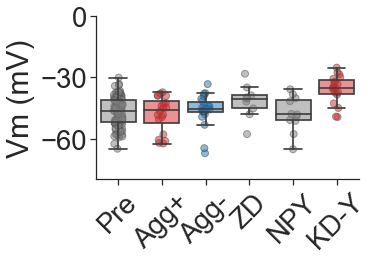

In [26]:
# Membrane voltage / RMP - VERSION WITH ALL GROUPS but w/o ANT

sns.set(rc={"figure.figsize": (4.7, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

ax = sns.boxplot(x='Behaviour_6hFD', y='Vm', data = ephys, order=['Pre', 'Agg+', 'Agg-', 'ZD7288', 'npy_100','npykd'], saturation=8, 
                 linewidth=1.7, showfliers = False, palette = six)
ax = sns.stripplot(x='Behaviour_6hFD', y='Vm', data = ephys, order=['Pre', 'Agg+', 'Agg-', 'ZD7288', 'npy_100','npykd'], jitter=True, 
                   dodge=False, marker='o', size=7, linewidth=1, edgecolor='gray', palette = six, alpha=0.5, zorder=0)
ax.set_xlabel('')
ax.set_ylabel('Vm (mV)', labelpad=5)

ax.set_xticklabels( ('Pre', 'Agg+', 'Agg-', 'ZD','NPY','KD-Y'), rotation=45)
ax.yaxis.set_major_locator(plt.MaxNLocator(3))
plt.ylim(-80, 0)
sns.despine(bottom=False, trim=False)

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, .5))
    
plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_8/linked_figure_S8/Vm_all_Y12.pdf',
            dpi=300,bbox_inches='tight', transparent=True)

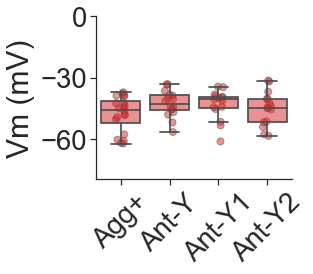

In [27]:
# Membrane voltage / RMP - VERSION WITH only ANT

sns.set(rc={"figure.figsize": (3.5, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

ax = sns.boxplot(x='Behaviour_6hFD', y='Vm', data = ephys, order=['Agg+', 'npy_antag', 'npy1r_antag', 'npy2r_antag'], saturation=8, 
                 linewidth=1.7, showfliers = False, palette = ant)
ax = sns.stripplot(x='Behaviour_6hFD', y='Vm', data = ephys, order=['Agg+', 'npy_antag', 'npy1r_antag', 'npy2r_antag'], jitter=True, 
                   dodge=False, marker='o', size=7, linewidth=1, edgecolor='gray', palette = ant, alpha=0.5, zorder=0)
ax.set_xlabel('')
ax.set_ylabel('Vm (mV)', labelpad=5)

ax.set_xticklabels( ('Agg+', 'Ant-Y','Ant-Y1','Ant-Y2'), rotation=45)
ax.yaxis.set_major_locator(plt.MaxNLocator(3))
plt.ylim(-80, 0)
sns.despine(bottom=False, trim=False)

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, .5))
    
plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_8/linked_figure_S8/Vm_Ant.pdf',
            dpi=300,bbox_inches='tight', transparent=True)

In [28]:
# STATS ====================================================================

# even though results are grouped in these plots, these are separate experiments, i.e. (1) Pre vs Agg- vs Agg+, (2) Pre vs ZD, Pre vs NPY,
# (3) Agg+ vs Ant-Y, (Agg+ vs Ant-Y1, Agg+ vs Ant-Y2), Agg+ vs KD-Y --> for (1) use ANOVA w/ Tukey; 
# for (2) and (3) use U test w/ Benjamini-Hochberg correction

# (1) ANOVA (Pre, Agg+, Agg-) ===============================================

group_summary = ephys.groupby('Behaviour_6hFD')['Vm'].agg(['count', 'var'])
# print(group_summary)

# filter for the groups we want
groups_to_include = ['Pre', 'Agg+', 'Agg-'] # , 'ZD7288', 'npy_100', 'npy_antag', 'npykd'
ephys2 = ephys[ephys['Behaviour_6hFD'].isin(groups_to_include)]

# Ensure 'Vm' is numeric and 'Behaviour_6hFD' is categorical
ephys2['Vm'] = pd.to_numeric(ephys2['Vm'], errors='coerce')
ephys2['Behaviour_6hFD'] = ephys2['Behaviour_6hFD'].astype('category')

# Drop rows with missing 'Vm' values
ephys2 = ephys2.dropna(subset=['Vm'])

# One-way ANOVA
from scipy.stats import f_oneway
from statsmodels.stats.multicomp import pairwise_tukeyhsd

if all(group_summary['count'] > 1) and all(group_summary['var'] > 0):
    anova_result = f_oneway(
        ephys2['Vm'][ephys2['Behaviour_6hFD'] == 'Pre'],
        ephys2['Vm'][ephys2['Behaviour_6hFD'] == 'Agg+'],
        ephys2['Vm'][ephys2['Behaviour_6hFD'] == 'Agg-']
    )

    print("One-way ANOVA p-value:", anova_result.pvalue)

    # Tukey HSD test for multiple comparisons
    tukey_results = pairwise_tukeyhsd(ephys2['Vm'], ephys2['Behaviour_6hFD'])
    print(tukey_results)
else:
    print("Not all groups have sufficient data or variance for ANOVA.")
    
# (2) U test: Pre vs ZD, Pre vs NPY ==========================================

group_pre = ephys[ephys['Behaviour_6hFD'] == 'Pre']['Vm'].dropna()
group_zd = ephys[ephys['Behaviour_6hFD'] == 'ZD7288']['Vm'].dropna()
group_npy = ephys[ephys['Behaviour_6hFD'] == 'npy_100']['Vm'].dropna()

u_statistic2, p_value2 = mannwhitneyu(group_pre, group_zd)
u_statistic3, p_value3 = mannwhitneyu(group_pre, group_npy)

# Benjamini-Hochberg correction
from statsmodels.stats.multitest import multipletests
p_values = [p_value2, p_value3]
reject, p_adjusted, _, _ = multipletests(p_values, alpha=0.05, method='fdr_bh')

print(f"\nMann-Whitney U test between 'Pre' and 'ZD7288': {p_value2}")
print(f"Mann-Whitney U test between 'Pre' and 'NPY': {p_value3}")
print("Corrected p-values:", p_adjusted)

# (3) U test: Agg+ vs Ant-Y, Agg+ vs Ant-Y1, Agg+ vs Ant-Y2, Agg+ vs KD-Y ==========================================

group_agg = ephys[ephys['Behaviour_6hFD'] == 'Agg+']['Vm'].dropna()
group_ant = ephys[ephys['Behaviour_6hFD'] == 'npy_antag']['Vm'].dropna()
group_ant1 = ephys[ephys['Behaviour_6hFD'] == 'npy1r_antag']['Vm'].dropna()
group_ant2 = ephys[ephys['Behaviour_6hFD'] == 'npy2r_antag']['Vm'].dropna()
group_kd = ephys[ephys['Behaviour_6hFD'] == 'npykd']['Vm'].dropna()

u_statistic4, p_value4 = mannwhitneyu(group_agg, group_ant)
u_statistic5, p_value5 = mannwhitneyu(group_agg, group_ant1)
u_statistic6, p_value6 = mannwhitneyu(group_agg, group_ant2)
u_statistic7, p_value7 = mannwhitneyu(group_agg, group_kd)

p_values = [p_value4, p_value5, p_value6, p_value7]
reject, p_adjusted, _, _ = multipletests(p_values, alpha=0.05, method='fdr_bh')

print(f"\nMann-Whitney U test between 'Agg+' and 'Ant-Y': {p_value4}")
print(f"Mann-Whitney U test between 'Agg+' and 'Ant-Y1': {p_value5}")
print(f"Mann-Whitney U test between 'Agg+' and 'Ant-Y2': {p_value6}")
print(f"Mann-Whitney U test between 'Agg+' and 'KD-Y': {p_value7}")
print("Corrected p-values:", p_adjusted)

One-way ANOVA p-value: 0.7014779050639248
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
  Agg+   Agg-   1.8983 0.6836 -3.5028 7.2994  False
  Agg+    Pre   1.1754 0.7914  -3.093 5.4438  False
  Agg-    Pre  -0.7229 0.9085 -4.8254 3.3795  False
---------------------------------------------------

Mann-Whitney U test between 'Pre' and 'ZD7288': 0.05696856621362753
Mann-Whitney U test between 'Pre' and 'NPY': 0.8753209216358904
Corrected p-values: [0.11393713 0.87532092]

Mann-Whitney U test between 'Agg+' and 'Ant-Y': 0.10110085963698442
Mann-Whitney U test between 'Agg+' and 'Ant-Y1': 0.14705851921929672
Mann-Whitney U test between 'Agg+' and 'Ant-Y2': 0.4735797982690084
Mann-Whitney U test between 'Agg+' and 'KD-Y': 5.530373549353605e-05
Corrected p-values: [1.96078026e-01 1.96078026e-01 4.73579798e-01 2.21214942e-04]


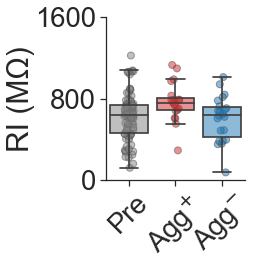

In [29]:
# Input resistance

sns.set(rc={"figure.figsize": (2.5, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

ax = sns.boxplot(x='Behaviour_6hFD', y='Input_Resistance', data = ephys, order=['Pre', 'Agg+', 'Agg-'], saturation=8, 
                 linewidth=1.7, showfliers = False, palette = triple)
ax = sns.stripplot(x='Behaviour_6hFD', y='Input_Resistance', data = ephys, order = ['Pre', 'Agg+', 'Agg-'], jitter=True, dodge=False, 
                   marker='o', size=7, linewidth=1, edgecolor='gray', palette = triple, alpha=0.5, zorder=0)
ax.set_xlabel('')
ax.set_ylabel('RI (MΩ)', labelpad=0)

ax.set_xticklabels(('Pre', r'Agg$^{+}$', r'Agg$^{-}$'), rotation=45)

ax.yaxis.set_major_locator(plt.MaxNLocator(2))
plt.ylim(0, 1600)
sns.despine(bottom=False, trim=False)

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, .5))
    
# plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Figure_3/linked_figure3/Ri.pdf',
#             dpi=300,bbox_inches='tight', transparent=True)

In [30]:
# stats - ANOVA + Tukey
pre_group = ephys[ephys['Behaviour_6hFD'] == 'Pre']['Input_Resistance'].dropna()
agg_plus_group = ephys[ephys['Behaviour_6hFD'] == 'Agg+']['Input_Resistance'].dropna()
agg_minus_group = ephys[ephys['Behaviour_6hFD'] == 'Agg-']['Input_Resistance'].dropna()

anova_result = f_oneway(pre_group, agg_plus_group, agg_minus_group)
print("One-way ANOVA p-value:", anova_result.pvalue)

all_input_resistances = np.concatenate([pre_group, agg_plus_group, agg_minus_group])
group_labels = ['Pre'] * len(pre_group) + ['Agg+'] * len(agg_plus_group) + ['Agg-'] * len(agg_minus_group)
tukey_results = pairwise_tukeyhsd(all_input_resistances, group_labels)
print(tukey_results)

One-way ANOVA p-value: 0.03374063938471321
  Multiple Comparison of Means - Tukey HSD, FWER=0.05   
group1 group2  meandiff p-adj    lower    upper   reject
--------------------------------------------------------
  Agg+   Agg- -160.9268 0.0578 -326.0425   4.1889  False
  Agg+    Pre -140.4934  0.038 -274.7271  -6.2597   True
  Agg-    Pre   20.4334 0.9224 -106.1518 147.0186  False
--------------------------------------------------------


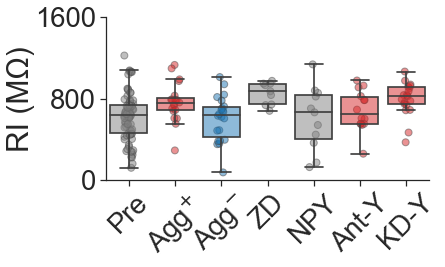

In [31]:
# Input resistance - VERSION WITH ALL GROUPS

sns.set(rc={"figure.figsize": (5.8, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

ax = sns.boxplot(x='Behaviour_6hFD', y='Input_Resistance', data = ephys, order=['Pre', 'Agg+', 'Agg-', 'ZD7288', 'npy_100','npy_antag', 'npykd'], 
                 saturation=8, linewidth=1.7, showfliers = False, palette = seven)
ax = sns.stripplot(x='Behaviour_6hFD', y='Input_Resistance', data = ephys, order=['Pre', 'Agg+', 'Agg-', 'ZD7288', 'npy_100','npy_antag', 'npykd'], 
                   jitter=True, dodge=False, marker='o', size=7, linewidth=1, edgecolor='gray', palette = seven, alpha=0.5, zorder=0)
ax.set_xlabel('')
ax.set_ylabel('RI (MΩ)', labelpad=0)

ax.set_xticklabels( ('Pre', r'Agg$^{+}$', r'Agg$^{-}$', 'ZD', 'NPY' ,'Ant-Y', 'KD-Y'), rotation=45)

ax.yaxis.set_major_locator(plt.MaxNLocator(2))
plt.ylim(0, 1600)
sns.despine(bottom=False, trim=False)

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, .5))
    
# plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Figure_3/linked_figure3/Ri_all.pdf',
#             dpi=300,bbox_inches='tight', transparent=True)

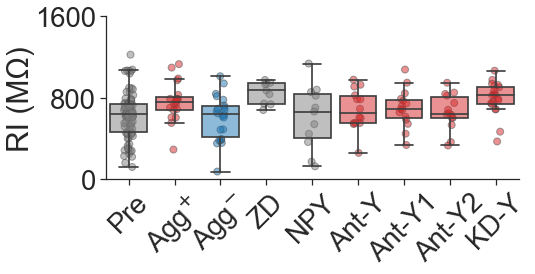

In [32]:
# Input resistance - VERSION WITH ALL GROUPS INCL Y1/2

sns.set(rc={"figure.figsize": (7.4, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

ax = sns.boxplot(x='Behaviour_6hFD', y='Input_Resistance', data = ephys, order=['Pre', 'Agg+', 'Agg-', 'ZD7288', 'npy_100','npy_antag', 'npy1r_antag', 'npy2r_antag','npykd'], 
                 saturation=8, linewidth=1.7, showfliers = False, palette = nine)
ax = sns.stripplot(x='Behaviour_6hFD', y='Input_Resistance', data = ephys, order=['Pre', 'Agg+', 'Agg-', 'ZD7288', 'npy_100','npy_antag', 'npy1r_antag', 'npy2r_antag','npykd'], 
                   jitter=True, dodge=False, marker='o', size=7, linewidth=1, edgecolor='gray', palette = nine, alpha=0.5, zorder=0)
ax.set_xlabel('')
ax.set_ylabel('RI (MΩ)', labelpad=0)

ax.set_xticklabels( ('Pre', r'Agg$^{+}$', r'Agg$^{-}$', 'ZD', 'NPY' ,'Ant-Y','Ant-Y1','Ant-Y2', 'KD-Y'), rotation=45)

ax.yaxis.set_major_locator(plt.MaxNLocator(2))
plt.ylim(0, 1600)
sns.despine(bottom=False, trim=False)

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, .5))
    
# plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_8/linked_figure_S8/Ri_all_Y12.pdf',
#             dpi=300,bbox_inches='tight', transparent=True)

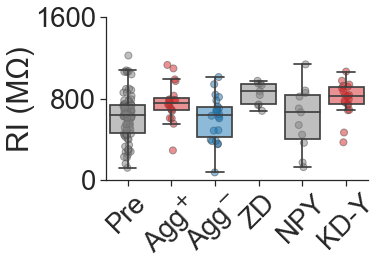

In [33]:
# Input resistance - VERSION WITH ALL GROUPS w/o Ant

sns.set(rc={"figure.figsize": (4.7, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

ax = sns.boxplot(x='Behaviour_6hFD', y='Input_Resistance', data = ephys, order=['Pre', 'Agg+', 'Agg-', 'ZD7288', 'npy_100','npykd'], 
                 saturation=8, linewidth=1.7, showfliers = False, palette = six)
ax = sns.stripplot(x='Behaviour_6hFD', y='Input_Resistance', data = ephys, order=['Pre', 'Agg+', 'Agg-', 'ZD7288', 'npy_100','npykd'], 
                   jitter=True, dodge=False, marker='o', size=7, linewidth=1, edgecolor='gray', palette = six, alpha=0.5, zorder=0)
ax.set_xlabel('')
ax.set_ylabel('RI (MΩ)', labelpad=0)

ax.set_xticklabels( ('Pre', r'Agg$^{+}$', r'Agg$^{-}$', 'ZD', 'NPY' , 'KD-Y'), rotation=45)

ax.yaxis.set_major_locator(plt.MaxNLocator(2))
plt.ylim(0, 1600)
sns.despine(bottom=False, trim=False)

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, .5))
    
plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_8/linked_figure_S8/Ri_all_Y12.pdf',
            dpi=300,bbox_inches='tight', transparent=True)

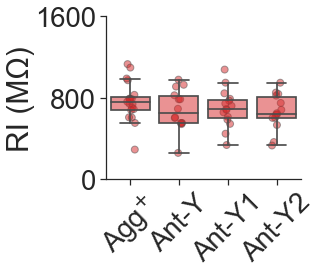

In [34]:
# Input resistance - VERSION w/ only Ant
sns.set(rc={"figure.figsize": (3.5, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

ax = sns.boxplot(x='Behaviour_6hFD', y='Input_Resistance', data = ephys, order=['Agg+', 'npy_antag', 'npy1r_antag', 'npy2r_antag'], 
                 saturation=8, linewidth=1.7, showfliers = False, palette = ant)
ax = sns.stripplot(x='Behaviour_6hFD', y='Input_Resistance', data = ephys, order=['Agg+', 'npy_antag', 'npy1r_antag', 'npy2r_antag'], 
                   jitter=True, dodge=False, marker='o', size=7, linewidth=1, edgecolor='gray', palette = ant, alpha=0.5, zorder=0)
ax.set_xlabel('')
ax.set_ylabel('RI (MΩ)', labelpad=0)

ax.set_xticklabels( (r'Agg$^{+}$','Ant-Y','Ant-Y1','Ant-Y2'), rotation=45)

ax.yaxis.set_major_locator(plt.MaxNLocator(2))
plt.ylim(0, 1600)
sns.despine(bottom=False, trim=False)

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, .5))
    
plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_8/linked_figure_S8/Ri_ant.pdf',
            dpi=300,bbox_inches='tight', transparent=True)

In [35]:
# STATS ====================================================================

# even though results are grouped in these plots, these are separate experiments, i.e. (1) Pre vs Agg- vs Agg+, (2) Pre vs ZD, Pre vs NPY,
# (3) Agg+ vs Ant-Y, (Agg+ vs Ant-Y1, Agg+ vs Ant-Y2), Agg+ vs KD-Y --> for (1) use ANOVA w/ Tukey; 
# for (2) and (3) use U test w/ Benjamini-Hochberg correction

# (1) ANOVA (Pre, Agg+, Agg-) ===============================================

group_summary = ephys.groupby('Behaviour_6hFD')['Input_Resistance'].agg(['count', 'var'])
# print(group_summary)

# filter for the groups we want
groups_to_include = ['Pre', 'Agg+', 'Agg-'] # , 'ZD7288', 'npy_100', 'npy_antag', 'npykd'
ephys3 = ephys[ephys['Behaviour_6hFD'].isin(groups_to_include)]

# Ensure 'Input_Resistance' is numeric and 'Behaviour_6hFD' is categorical
ephys3['Input_Resistance'] = pd.to_numeric(ephys3['Input_Resistance'], errors='coerce')
ephys3['Behaviour_6hFD'] = ephys3['Behaviour_6hFD'].astype('category')

# Drop rows with missing values
ephys3 = ephys3.dropna(subset=['Input_Resistance'])

# One-way ANOVA
from scipy.stats import f_oneway
from statsmodels.stats.multicomp import pairwise_tukeyhsd

if all(group_summary['count'] > 1) and all(group_summary['var'] > 0):
    anova_result = f_oneway(
        ephys3['Input_Resistance'][ephys3['Behaviour_6hFD'] == 'Pre'],
        ephys3['Input_Resistance'][ephys3['Behaviour_6hFD'] == 'Agg+'],
        ephys3['Input_Resistance'][ephys3['Behaviour_6hFD'] == 'Agg-']
    )

    print("One-way ANOVA p-value:", anova_result.pvalue)

    # Tukey HSD test for multiple comparisons
    tukey_results = pairwise_tukeyhsd(ephys3['Input_Resistance'], ephys3['Behaviour_6hFD'])
    print(tukey_results)
else:
    print("Not all groups have sufficient data or variance for ANOVA.")
    
# (2) U test: Pre vs ZD, Pre vs NPY ==========================================

group_pre = ephys[ephys['Behaviour_6hFD'] == 'Pre']['Input_Resistance'].dropna()
group_zd = ephys[ephys['Behaviour_6hFD'] == 'ZD7288']['Input_Resistance'].dropna()
group_npy = ephys[ephys['Behaviour_6hFD'] == 'npy_100']['Input_Resistance'].dropna()

u_statistic2, p_value2 = mannwhitneyu(group_pre, group_zd)
u_statistic3, p_value3 = mannwhitneyu(group_pre, group_npy)

# Benjamini-Hochberg correction
from statsmodels.stats.multitest import multipletests
p_values = [p_value2, p_value3]
reject, p_adjusted, _, _ = multipletests(p_values, alpha=0.05, method='fdr_bh')

print(f"\nMann-Whitney U test between 'Pre' and 'ZD7288': {p_value2}")
print(f"Mann-Whitney U test between 'Pre' and 'NPY': {p_value3}")
print("Corrected p-values:", p_adjusted)

# (3) U test: Agg+ vs Ant-Y, Agg+ vs Ant-Y1, Agg+ vs Ant-Y2, Agg+ vs KD-Y ==========================================

group_agg = ephys[ephys['Behaviour_6hFD'] == 'Agg+']['Input_Resistance'].dropna()
group_ant = ephys[ephys['Behaviour_6hFD'] == 'npy_antag']['Input_Resistance'].dropna()
group_ant1 = ephys[ephys['Behaviour_6hFD'] == 'npy1r_antag']['Input_Resistance'].dropna()
group_ant2 = ephys[ephys['Behaviour_6hFD'] == 'npy2r_antag']['Input_Resistance'].dropna()
group_kd = ephys[ephys['Behaviour_6hFD'] == 'npykd']['Input_Resistance'].dropna()

u_statistic4, p_value4 = mannwhitneyu(group_agg, group_ant)
u_statistic5, p_value5 = mannwhitneyu(group_agg, group_ant1)
u_statistic6, p_value6 = mannwhitneyu(group_agg, group_ant2)
u_statistic7, p_value7 = mannwhitneyu(group_agg, group_kd)

p_values = [p_value4, p_value5, p_value6, p_value7]
reject, p_adjusted, _, _ = multipletests(p_values, alpha=0.05, method='fdr_bh')

print(f"\nMann-Whitney U test between 'Agg+' and 'Ant-Y': {p_value4}")
print(f"Mann-Whitney U test between 'Agg+' and 'Ant-Y1': {p_value5}")
print(f"Mann-Whitney U test between 'Agg+' and 'Ant-Y2': {p_value6}")
print(f"Mann-Whitney U test between 'Agg+' and 'KD-Y': {p_value7}")
print("Corrected p-values:", p_adjusted)

One-way ANOVA p-value: 0.03374063938471321
  Multiple Comparison of Means - Tukey HSD, FWER=0.05   
group1 group2  meandiff p-adj    lower    upper   reject
--------------------------------------------------------
  Agg+   Agg- -160.9268 0.0578 -326.0425   4.1889  False
  Agg+    Pre -140.4934  0.038 -274.7271  -6.2597   True
  Agg-    Pre   20.4334 0.9224 -106.1518 147.0186  False
--------------------------------------------------------

Mann-Whitney U test between 'Pre' and 'ZD7288': 0.0012071520714673186
Mann-Whitney U test between 'Pre' and 'NPY': 0.9952539650482173
Corrected p-values: [0.0024143  0.99525397]

Mann-Whitney U test between 'Agg+' and 'Ant-Y': 0.17194793289971422
Mann-Whitney U test between 'Agg+' and 'Ant-Y1': 0.25238104262144023
Mann-Whitney U test between 'Agg+' and 'Ant-Y2': 0.14011244626592897
Mann-Whitney U test between 'Agg+' and 'KD-Y': 0.30686792369038496
Corrected p-values: [0.30686792 0.30686792 0.30686792 0.30686792]


In [36]:
# cell numbers
group_counts = ephys['Behaviour_6hFD'].value_counts()
# print(group_counts)
# mice per group
unique_id_counts = ephys.groupby('Behaviour_6hFD')['ID_mouse'].nunique()
# print(unique_id_counts)

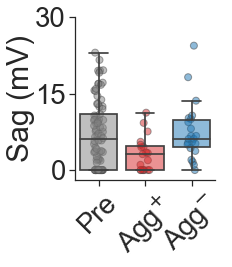

In [37]:
# Ih
sns.set(rc={"figure.figsize": (2.5, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

ax = sns.boxplot(x='Behaviour_6hFD', y='Ih_at_-120mV', data = ephys, order=['Pre', 'Agg+', 'Agg-'], saturation=8, 
                 linewidth=1.7, showfliers = False, palette = triple)
ax = sns.stripplot(x='Behaviour_6hFD', y='Ih_at_-120mV', data = ephys, order = ['Pre', 'Agg+', 'Agg-'], jitter=True, dodge=False, 
                   marker='o', size=7, linewidth=1, edgecolor='gray', palette = triple, alpha=0.5, zorder=0)
ax.set_xlabel('')
ax.set_ylabel('Sag (mV)', labelpad=0)

ax.set_xticklabels( ('Pre', r'Agg$^{+}$', r'Agg$^{-}$'), rotation=45)
ax.yaxis.set_major_locator(plt.MaxNLocator(3))
plt.ylim(-2, 30)
sns.despine(bottom=False, trim=False)

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, .5))
    
# plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Figure_3/linked_figure3/Ih.pdf',
#             dpi=300,bbox_inches='tight', transparent=True)

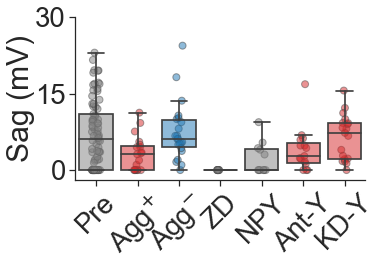

In [38]:
# Ih - VERSION WITH ALL GROUPS
sns.set(rc={"figure.figsize": (5.2, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

ax = sns.boxplot(x='Behaviour_6hFD', y='Ih_at_-120mV', data = ephys, order=['Pre', 'Agg+', 'Agg-', 'ZD7288', 'npy_100','npy_antag', 'npykd'],
                 saturation=8, linewidth=1.7, showfliers = False, palette = seven)
ax = sns.stripplot(x='Behaviour_6hFD', y='Ih_at_-120mV', data = ephys, order=['Pre', 'Agg+', 'Agg-', 'ZD7288', 'npy_100','npy_antag', 'npykd'],
                   jitter=True, dodge=False, marker='o', size=7, linewidth=1, edgecolor='gray', palette = seven, alpha=0.5, zorder=0)
ax.set_xlabel('')
ax.set_ylabel('Sag (mV)', labelpad=0)

ax.set_xticklabels( ('Pre', r'Agg$^{+}$', r'Agg$^{-}$','ZD','NPY','Ant-Y', 'KD-Y'), rotation=45)

ax.yaxis.set_major_locator(plt.MaxNLocator(3))
plt.ylim(-2, 30)
sns.despine(bottom=False, trim=False)

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, .5))
    
# plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Figure_3/linked_figure3/Ih_all.pdf',
#             dpi=300,bbox_inches='tight', transparent=True)

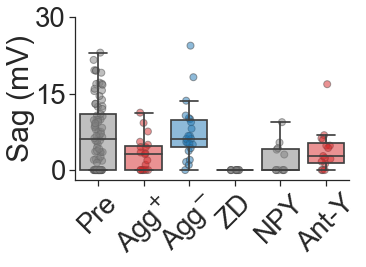

In [39]:
# Ih - VERSION without KD-Y
sns.set(rc={"figure.figsize": (4.9, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

ax = sns.boxplot(x='Behaviour_6hFD', y='Ih_at_-120mV', data = ephys, order=['Pre', 'Agg+', 'Agg-', 'ZD7288', 'npy_100','npy_antag'],
                 saturation=8, linewidth=1.7, showfliers = False, palette = seven)
ax = sns.stripplot(x='Behaviour_6hFD', y='Ih_at_-120mV', data = ephys, order=['Pre', 'Agg+', 'Agg-', 'ZD7288', 'npy_100','npy_antag'],
                   jitter=True, dodge=False, marker='o', size=7, linewidth=1, edgecolor='gray', palette = seven, alpha=0.5, zorder=0)
ax.set_xlabel('')
ax.set_ylabel('Sag (mV)', labelpad=0)

ax.set_xticklabels( ('Pre', r'Agg$^{+}$', r'Agg$^{-}$','ZD','NPY','Ant-Y'), rotation=45)

ax.yaxis.set_major_locator(plt.MaxNLocator(3))
plt.ylim(-2, 30)
sns.despine(bottom=False, trim=False)

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, .5))
    
# plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Figure_3/linked_figure3/Ih_noKD.pdf',
#             dpi=300,bbox_inches='tight', transparent=True)

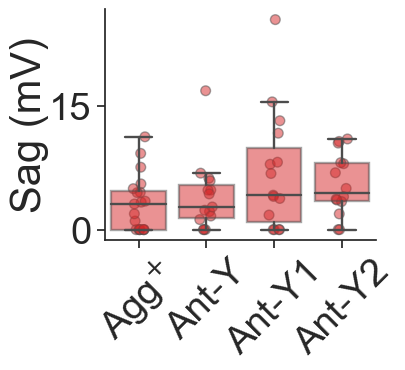

In [21]:
# Input resistance - VERSION w/ only Ant
sns.set(rc={"figure.figsize": (3.5, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

ax = sns.boxplot(x='Behaviour_6hFD', y='Ih_at_-120mV', data = ephys, order=['Agg+', 'npy_antag', 'npy1r_antag', 'npy2r_antag'], 
                 saturation=8, linewidth=1.7, showfliers = False, palette = ant, boxprops=dict(alpha=.5))
ax = sns.stripplot(x='Behaviour_6hFD', y='Ih_at_-120mV', data = ephys, order=['Agg+', 'npy_antag', 'npy1r_antag', 'npy2r_antag'], 
                   jitter=True, dodge=False, marker='o', size=7, linewidth=1, edgecolor='gray', palette = ant, alpha=0.5, zorder=0)
ax.set_xlabel('')
ax.set_ylabel('Sag (mV)', labelpad=0)

ax.set_xticklabels( (r'Agg$^{+}$','Ant-Y','Ant-Y1','Ant-Y2'), rotation=45)

ax.yaxis.set_major_locator(plt.MaxNLocator(2))
sns.despine(bottom=False, trim=False)

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, .5))
    
plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_8/linked_figure_S8/Ih_ant.pdf',
            dpi=300,bbox_inches='tight', transparent=True)

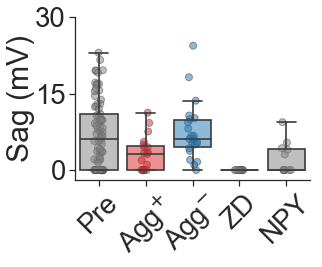

In [40]:
# Ih - VERSION without KD-Y and Ant-Y
sns.set(rc={"figure.figsize": (4.2, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

ax = sns.boxplot(x='Behaviour_6hFD', y='Ih_at_-120mV', data = ephys, order=['Pre', 'Agg+', 'Agg-', 'ZD7288', 'npy_100'],
                 saturation=8, linewidth=1.7, showfliers = False, palette = six)
ax = sns.stripplot(x='Behaviour_6hFD', y='Ih_at_-120mV', data = ephys, order=['Pre', 'Agg+', 'Agg-', 'ZD7288', 'npy_100'],
                   jitter=True, dodge=False, marker='o', size=7, linewidth=1, edgecolor='gray', palette = six, alpha=0.5, zorder=0)
ax.set_xlabel('')
ax.set_ylabel('Sag (mV)', labelpad=0)

ax.set_xticklabels( ('Pre', r'Agg$^{+}$', r'Agg$^{-}$','ZD','NPY'), rotation=45)

ax.yaxis.set_major_locator(plt.MaxNLocator(3))
plt.ylim(-2, 30)
sns.despine(bottom=False, trim=False)

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, .5))
    
plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Figure_3/linked_figure3/Ih_noKD.pdf',
            dpi=300,bbox_inches='tight', transparent=True)

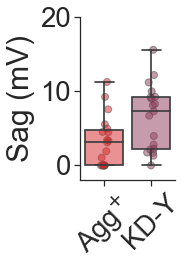

In [41]:
# Ih - only Agg+ and KD-Y
sns.set(rc={"figure.figsize": (1.7, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

ax = sns.boxplot(x='Behaviour_6hFD', y='Ih_at_-120mV', data = ephys, order=['Agg+', 'npykd'],
                 saturation=8, linewidth=1.7, showfliers = False, palette = ['Tab:red', '#8F3B5A'])
ax = sns.stripplot(x='Behaviour_6hFD', y='Ih_at_-120mV', data = ephys, order=['Agg+', 'npykd'],
                   jitter=True, dodge=False, marker='o', size=7, linewidth=1, edgecolor='gray', palette = ['Tab:red', '#8F3B5A'], alpha=0.5, zorder=0)
ax.set_xlabel('')
ax.set_ylabel('Sag (mV)', labelpad=5)

ax.set_xticklabels( (r'Agg$^{+}$', 'KD-Y'), rotation=45)

ax.yaxis.set_major_locator(plt.MaxNLocator(3))
plt.ylim(-2, 20)
ax.set_yticks([0, 10, 20])
sns.despine(bottom=False, trim=False)

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, .5))
    
plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Figure_3/linked_figure3/Ih_KD.pdf',
            dpi=300,bbox_inches='tight', transparent=True)

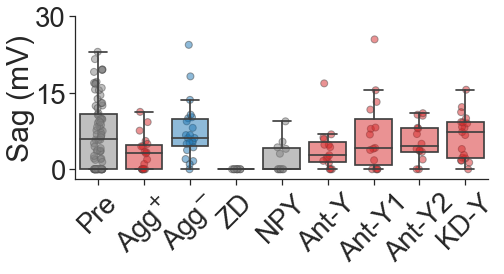

In [42]:
# Ih - VERSION WITH ALL GROUPS INCL Y1/2
sns.set(rc={"figure.figsize": (7.4, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

ax = sns.boxplot(x='Behaviour_6hFD', y='Ih_at_-120mV', data = ephys, order=['Pre', 'Agg+', 'Agg-', 'ZD7288', 'npy_100','npy_antag', 'npy1r_antag', 'npy2r_antag','npykd'],
                 saturation=8, linewidth=1.7, showfliers = False, palette = nine)
ax = sns.stripplot(x='Behaviour_6hFD', y='Ih_at_-120mV', data = ephys, order=['Pre', 'Agg+', 'Agg-', 'ZD7288', 'npy_100','npy_antag', 'npy1r_antag', 'npy2r_antag','npykd'],
                   jitter=True, dodge=False, marker='o', size=7, linewidth=1, edgecolor='gray', palette = nine, alpha=0.5, zorder=0)
ax.set_xlabel('')
ax.set_ylabel('Sag (mV)', labelpad=0)

ax.set_xticklabels( ('Pre', r'Agg$^{+}$', r'Agg$^{-}$','ZD','NPY','Ant-Y','Ant-Y1','Ant-Y2' ,'KD-Y'), rotation=45)

ax.yaxis.set_major_locator(plt.MaxNLocator(3))
plt.ylim(-2, 30)
sns.despine(bottom=False, trim=False)

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, .5))
    
plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_8/linked_figure_S8/Ih_all_Y12.pdf',
            dpi=300,bbox_inches='tight', transparent=True)

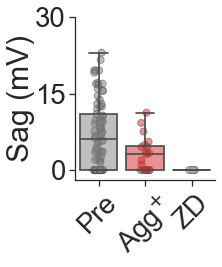

In [43]:
# Ih - ZD
sns.set(rc={"figure.figsize": (2.5, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

ax = sns.boxplot(x='Behaviour_6hFD', y='Ih_at_-120mV', data = ephys, order=['Pre', 'Agg+', 'ZD7288'], saturation=8, 
                 linewidth=1.7, showfliers = False, palette = ZD)
ax = sns.stripplot(x='Behaviour_6hFD', y='Ih_at_-120mV', data = ephys, order = ['Pre', 'Agg+', 'ZD7288'], jitter=True, dodge=False, 
                   marker='o', size=7, linewidth=1, edgecolor='gray', palette = ZD, alpha=0.5, zorder=0)
ax.set_xlabel('')
ax.set_ylabel('Sag (mV)', labelpad=0)

ax.set_xticklabels( ('Pre', r'Agg$^{+}$', 'ZD'), rotation=45)
ax.yaxis.set_major_locator(plt.MaxNLocator(3))
plt.ylim(-2, 30)
sns.despine(bottom=False, trim=False)

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, .5))
    
plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Figure_3/linked_figure3/Ih_ZD.pdf',
            dpi=300,bbox_inches='tight', transparent=True)

In [44]:
# cell and mouse numbers
cell_counts = ephys.groupby('Behaviour_6hFD')['Ih_at_-120mV'].count()
print(f"\n\033[1mCell counts:\033[0m\n \n{cell_counts}")
filtered = ephys.dropna(subset=['Ih_at_-120mV'])
mouse_counts = filtered.groupby('Behaviour_6hFD')['ID_mouse'].nunique()
print(f"\033[1mMouse numbers:\033[0m\n \n{mouse_counts}") 


Cell counts:
 
Behaviour_6hFD
Agg+              19
Agg-              22
Pre               82
ZD7288             9
ZD7288_20          3
agrp_100          15
npy1r_antag       15
npy2r_antag       14
npy_10            10
npy_100           11
npy_100_paired     3
npy_10_paired      5
npy_antag         15
npykd             19
Name: Ih_at_-120mV, dtype: int64
Mouse numbers:
 
Behaviour_6hFD
Agg+               6
Agg-               3
Pre               15
ZD7288             1
ZD7288_20          1
agrp_100           5
npy1r_antag        2
npy2r_antag        3
npy_10             3
npy_100            4
npy_100_paired     0
npy_10_paired      0
npy_antag          3
npykd              3
Name: ID_mouse, dtype: int64


In [45]:
# STATS ====================================================================

# even though results are grouped in these plots, these are separate experiments, i.e. (1) Pre vs Agg- vs Agg+, (2) Pre vs ZD, Pre vs NPY,
# (3) Agg+ vs Ant-Y, (Agg+ vs Ant-Y1, Agg+ vs Ant-Y2), Agg+ vs KD-Y --> for (1) use ANOVA w/ Tukey; 
# for (2) and (3) use U test w/ Benjamini-Hochberg correction

# (1) ANOVA (Pre, Agg+, Agg-) ===============================================

groups_to_include = ['Pre', 'Agg+', 'Agg-'] # , 'ZD7288', 'npy_100', 'npy_antag', 'npykd'
ephys4 = ephys[ephys['Behaviour_6hFD'].isin(groups_to_include)]

# Ensure 'Ih_at_-120mV' is numeric and 'Behaviour_6hFD' is categorical
ephys4['Ih_at_-120mV'] = pd.to_numeric(ephys4['Ih_at_-120mV'], errors='coerce')
ephys4['Behaviour_6hFD'] = ephys4['Behaviour_6hFD'].astype('category')

# Drop rows with missing values
ephys4 = ephys4.dropna(subset=['Ih_at_-120mV'])

# One-way ANOVA
from scipy.stats import f_oneway
from statsmodels.stats.multicomp import pairwise_tukeyhsd

anova_result = f_oneway(
        ephys4['Ih_at_-120mV'][ephys4['Behaviour_6hFD'] == 'Pre'],
        ephys4['Ih_at_-120mV'][ephys4['Behaviour_6hFD'] == 'Agg+'],
        ephys4['Ih_at_-120mV'][ephys4['Behaviour_6hFD'] == 'Agg-']
        )

print("One-way ANOVA p-value:", anova_result.pvalue)

# Tukey HSD test for multiple comparisons
tukey_results = pairwise_tukeyhsd(ephys4['Ih_at_-120mV'], ephys4['Behaviour_6hFD'])
print(tukey_results)
    
# (2) U test: Pre vs ZD, Pre vs NPY ==========================================

group_pre = ephys[ephys['Behaviour_6hFD'] == 'Pre']['Ih_at_-120mV'].dropna()
group_zd = ephys[ephys['Behaviour_6hFD'] == 'ZD7288']['Ih_at_-120mV'].dropna()
group_npy = ephys[ephys['Behaviour_6hFD'] == 'npy_100']['Ih_at_-120mV'].dropna()

u_statistic2, p_value2 = mannwhitneyu(group_pre, group_zd)
u_statistic3, p_value3 = mannwhitneyu(group_pre, group_npy)

# Benjamini-Hochberg correction
from statsmodels.stats.multitest import multipletests
p_values = [p_value2, p_value3]
reject, p_adjusted, _, _ = multipletests(p_values, alpha=0.05, method='fdr_bh')

print(f"\nMann-Whitney U test between 'Pre' and 'ZD7288': {p_value2}")
print(f"Mann-Whitney U test between 'Pre' and 'NPY': {p_value3}")
print("Corrected p-values:", p_adjusted)

# (3) U test: Agg+ vs Ant-Y, Agg+ vs Ant-Y1, Agg+ vs Ant-Y2, Agg+ vs KD-Y ==========================================

group_agg = ephys[ephys['Behaviour_6hFD'] == 'Agg+']['Ih_at_-120mV'].dropna()
group_ant = ephys[ephys['Behaviour_6hFD'] == 'npy_antag']['Ih_at_-120mV'].dropna()
group_ant1 = ephys[ephys['Behaviour_6hFD'] == 'npy1r_antag']['Ih_at_-120mV'].dropna()
group_ant2 = ephys[ephys['Behaviour_6hFD'] == 'npy2r_antag']['Ih_at_-120mV'].dropna()
group_kd = ephys[ephys['Behaviour_6hFD'] == 'npykd']['Ih_at_-120mV'].dropna()

u_statistic4, p_value4 = mannwhitneyu(group_agg, group_ant)
u_statistic5, p_value5 = mannwhitneyu(group_agg, group_ant1)
u_statistic6, p_value6 = mannwhitneyu(group_agg, group_ant2)
u_statistic7, p_value7 = mannwhitneyu(group_agg, group_kd)

p_values = [p_value4, p_value5, p_value6, p_value7] #p_value5, p_value6, 
reject, p_adjusted, _, _ = multipletests(p_values, alpha=0.05, method='fdr_bh')

print(f"\nMann-Whitney U test between 'Agg+' and 'Ant-Y': {p_value4}")
print(f"Mann-Whitney U test between 'Agg+' and 'Ant-Y1': {p_value5}")
print(f"Mann-Whitney U test between 'Agg+' and 'Ant-Y2': {p_value6}")
print(f"Mann-Whitney U test between 'Agg+' and 'KD-Y': {p_value7}")
print("Corrected p-values:", p_adjusted)

One-way ANOVA p-value: 0.03704512164803374
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
  Agg+   Agg-    4.272 0.0653 -0.2111 8.7551  False
  Agg+    Pre   3.7795 0.0402  0.1349 7.4241   True
  Agg-    Pre  -0.4925 0.9383 -3.9294 2.9444  False
---------------------------------------------------

Mann-Whitney U test between 'Pre' and 'ZD7288': 0.00038696578446780085
Mann-Whitney U test between 'Pre' and 'NPY': 0.024780518861118175
Corrected p-values: [0.00077393 0.02478052]

Mann-Whitney U test between 'Agg+' and 'Ant-Y': 0.5386710215379917
Mann-Whitney U test between 'Agg+' and 'Ant-Y1': 0.14801446810494848
Mann-Whitney U test between 'Agg+' and 'Ant-Y2': 0.08049097466065859
Mann-Whitney U test between 'Agg+' and 'KD-Y': 0.023913065919995057
Corrected p-values: [0.53867102 0.19735262 0.16098195 0.09565226]


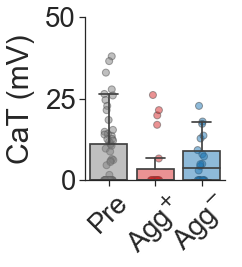

In [46]:
# CaT
sns.set(rc={"figure.figsize": (2.5, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

ax = sns.boxplot(x='Behaviour_6hFD', y='CaT', data = ephys, order=['Pre', 'Agg+', 'Agg-'], saturation=8, 
                 linewidth=1.7, showfliers = False, palette = triple)
ax = sns.stripplot(x='Behaviour_6hFD', y='CaT', data = ephys, order=['Pre', 'Agg+', 'Agg-'], jitter=True, dodge=False, 
                   marker='o', size=7, linewidth=1, edgecolor='gray', palette = triple, alpha=0.5, zorder=0)
ax.set_xlabel('')
ax.set_ylabel('CaT (mV)', labelpad=10)

ax.set_xticklabels( ('Pre', r'Agg$^{+}$', r'Agg$^{-}$'), rotation=45)
plt.ylim(0, 50)
ax.yaxis.set_major_locator(plt.MaxNLocator(2))
sns.despine(bottom=False, trim=False)

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, .5))
    
# plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_5/linked_figure_S5/cat.pdf',
#             dpi=300,bbox_inches='tight', transparent=True)

In [47]:
# stats - ANOVA + Tukey
pre_group = ephys[ephys['Behaviour_6hFD'] == 'Pre']['CaT'].dropna()
agg_plus_group = ephys[ephys['Behaviour_6hFD'] == 'Agg+']['CaT'].dropna()
agg_minus_group = ephys[ephys['Behaviour_6hFD'] == 'Agg-']['CaT'].dropna()

anova_result = f_oneway(pre_group, agg_plus_group, agg_minus_group)
print("One-way ANOVA p-value:", anova_result.pvalue)

One-way ANOVA p-value: 0.8932845300921585


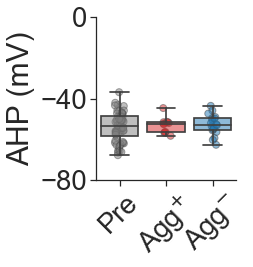

In [48]:
# AHP

ephys_filtered = ephys[ephys['AHP_(mV)'] != 0]

sns.set(rc={"figure.figsize": (2.5, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

ax = sns.boxplot(x='Behaviour_6hFD', y='AHP_(mV)', data = ephys_filtered, order=['Pre', 'Agg+', 'Agg-'], saturation=8, 
                 linewidth=1.7, showfliers = False, palette = triple)
ax = sns.stripplot(x='Behaviour_6hFD', y='AHP_(mV)', data = ephys_filtered, order=['Pre', 'Agg+', 'Agg-'], jitter=True, dodge=False, 
                   marker='o', size=7, linewidth=1, edgecolor='gray', palette = triple, alpha=0.5, zorder=0)
ax.set_xlabel('')
ax.set_ylabel('AHP (mV)', labelpad=5)

ax.set_xticklabels( ('Pre', r'Agg$^{+}$', r'Agg$^{-}$'), rotation=45)
plt.ylim(-80, 0)
ax.yaxis.set_major_locator(plt.MaxNLocator(2))
sns.despine(bottom=False, trim=False)

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, .5))
    
# plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_5/linked_figure_S5/ahp.pdf',
#             dpi=300,bbox_inches='tight', transparent=True)

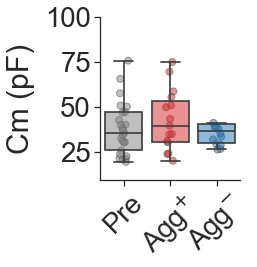

In [49]:
# Cm
sns.set(rc={"figure.figsize": (2.5, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

ax = sns.boxplot(x='Behaviour_6hFD', y='Cm(pF)', data = ephys, order=['Pre', 'Agg+', 'Agg-'], saturation=8, 
                 linewidth=1.7, showfliers = False, palette = triple)
ax = sns.stripplot(x='Behaviour_6hFD', y='Cm(pF)', data = ephys, order=['Pre', 'Agg+', 'Agg-'], jitter=True, dodge=False, 
                   marker='o', size=7, linewidth=1, edgecolor='gray', alpha=0.5, zorder=0, palette = triple)
ax.set_xlabel('')
ax.set_ylabel('Cm (pF)', labelpad=10)

ax.set_xticklabels( ('Pre', r'Agg$^{+}$', r'Agg$^{-}$'), rotation=45)
ax.yaxis.set_major_locator(plt.MaxNLocator(4))
plt.ylim(top=100)
sns.despine(bottom=False, trim=False)

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, .5))
        
plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_5/linked_figure_S5/Cm.pdf',
            dpi=300,bbox_inches='tight', transparent=True)

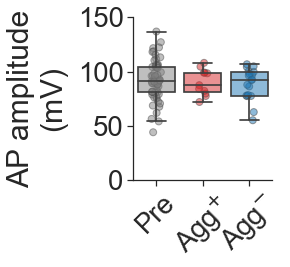

In [50]:
# AP_ampl
ephys_filt = ephys[ephys['AP_ampl'] != 0]

sns.set(rc={"figure.figsize": (2.5, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

ax = sns.boxplot(x='Behaviour_6hFD', y='AP_ampl', data = ephys_filt, order=['Pre', 'Agg+', 'Agg-'], saturation=8, 
                 linewidth=1.7, showfliers = False, palette = triple)
ax = sns.stripplot(x='Behaviour_6hFD', y='AP_ampl', data = ephys_filt, order=['Pre', 'Agg+', 'Agg-'], jitter=True, dodge=False, 
                   marker='o', size=7, linewidth=1, edgecolor='gray', alpha=0.5, zorder=0, palette = triple)
ax.set_xlabel('')
ax.set_ylabel('AP amplitude\n(mV)', labelpad=10)

ax.set_xticklabels( ('Pre', r'Agg$^{+}$', r'Agg$^{-}$'), rotation=45)
plt.ylim(0,150)
ax.yaxis.set_major_locator(plt.MaxNLocator(3))
sns.despine(bottom=False, trim=False)

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, .5))
        
# plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_5/linked_figure_S5/AP_ampl.pdf',
#             dpi=300,bbox_inches='tight', transparent=True)

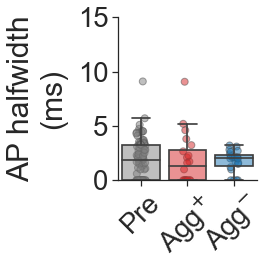

In [51]:
# AP_halfwidth
sns.set(rc={"figure.figsize": (2.5, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

ax = sns.boxplot(x='Behaviour_6hFD', y='AP_halfwidth', data = ephys, order=['Pre', 'Agg+', 'Agg-'], saturation=8, 
                 linewidth=1.7, showfliers = False, palette = triple)
ax = sns.stripplot(x='Behaviour_6hFD', y='AP_halfwidth', data = ephys, order=['Pre', 'Agg+', 'Agg-'], jitter=True, dodge=False, 
                   marker='o', size=7, linewidth=1, edgecolor='gray', alpha=0.5, zorder=0, palette = triple)
ax.set_xlabel('')
ax.set_ylabel('AP halfwidth\n(ms)', labelpad=10)

ax.set_xticklabels( ('Pre', r'Agg$^{+}$', r'Agg$^{-}$'), rotation=45)
ax.yaxis.set_major_locator(plt.MaxNLocator(3))
plt.ylim(0,15)
sns.despine(bottom=False, trim=False)

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, .5))
        
# plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_5/linked_figure_S5/AP_halfwidth.pdf',
#             dpi=300,bbox_inches='tight', transparent=True)

In [52]:
# stats - ANOVA + Tukey
pre_group = ephys[ephys['Behaviour_6hFD'] == 'Pre']['AP_halfwidth'].dropna()
agg_plus_group = ephys[ephys['Behaviour_6hFD'] == 'Agg+']['AP_halfwidth'].dropna()
agg_minus_group = ephys[ephys['Behaviour_6hFD'] == 'Agg-']['AP_halfwidth'].dropna()

anova_result = f_oneway(pre_group, agg_plus_group, agg_minus_group)
print("One-way ANOVA p-value:", anova_result.pvalue)

One-way ANOVA p-value: 0.9113375804199654


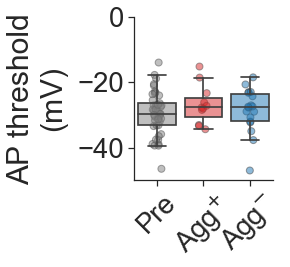

In [53]:
# AP threshold - loaded from a different excel sheet currently, but will add to main ephys.csv file
ap_thresh = pd.read_csv('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Figure_3/Analysis/AP threshold/APthreshold_v1.csv')

sns.set(rc={"figure.figsize": (2.5, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

ax = sns.boxplot(x='state', y='AP_threshold_mV', data = ap_thresh, order=['Pre', 'Agg+', 'Agg-'], saturation=8, 
                 linewidth=1.7, showfliers = False, palette = triple)
ax = sns.stripplot(x='state', y='AP_threshold_mV', data = ap_thresh, order=['Pre', 'Agg+', 'Agg-'], jitter=True, dodge=False, 
                   marker='o', size=7, linewidth=1, edgecolor='gray', alpha=0.5, zorder=0, palette = triple)
ax.set_xlabel('')
ax.set_ylabel('AP threshold\n(mV)', labelpad=10)

ax.set_xticklabels( ('Pre', r'Agg$^{+}$', r'Agg$^{-}$'), rotation=45)
ax.yaxis.set_major_locator(plt.MaxNLocator(3))
plt.ylim(-50, 0)
sns.despine(bottom=False, trim=False)

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, .5))
        
plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_5/linked_figure_S5/AP_threshold.pdf',
            dpi=300,bbox_inches='tight', transparent=True)

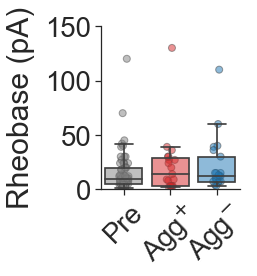

In [54]:
# rheobase_at_-60mV_(pA)
sns.set(rc={"figure.figsize": (2.5, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

ax = sns.boxplot(x='Behaviour_6hFD', y='rheobase_at_-60mV_(pA)', data = ephys, order=['Pre', 'Agg+', 'Agg-'], saturation=8, 
                 linewidth=1.7, showfliers = False, palette = triple)
ax = sns.stripplot(x='Behaviour_6hFD', y='rheobase_at_-60mV_(pA)', data = ephys, order=['Pre', 'Agg+', 'Agg-'], jitter=True, dodge=False, 
                   marker='o', size=7, linewidth=1, edgecolor='gray', alpha=0.5, zorder=0, palette = triple)
ax.set_xlabel('')
ax.set_ylabel('Rheobase (pA)', labelpad=10)

ax.set_xticklabels( ('Pre', r'Agg$^{+}$', r'Agg$^{-}$'), rotation=45)
ax.yaxis.set_major_locator(plt.MaxNLocator(3))
plt.ylim(0,150)
sns.despine(bottom=False, trim=False)

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, .5))
        
# plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_5/linked_figure_S5/rheo.pdf',
#             dpi=300,bbox_inches='tight', transparent=True)

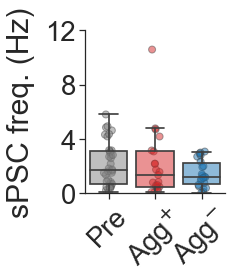

In [55]:
# sPSC_frequency
sns.set(rc={"figure.figsize": (2.5, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

ax = sns.boxplot(x='Behaviour_6hFD', y='sPSC_frequency', data = ephys, order=['Pre', 'Agg+', 'Agg-'], saturation=8, 
                 linewidth=1.7, showfliers = False, palette = triple)
ax = sns.stripplot(x='Behaviour_6hFD', y='sPSC_frequency', data = ephys, order=['Pre', 'Agg+', 'Agg-'], jitter=True, dodge=False, 
                   marker='o', size=7, linewidth=1, edgecolor='gray', alpha=0.5, zorder=0, palette = triple)
ax.set_xlabel('')
ax.set_ylabel('sPSC freq. (Hz)', labelpad=10)

ax.set_xticklabels( ('Pre', r'Agg$^{+}$', r'Agg$^{-}$'), rotation=45)
ax.yaxis.set_major_locator(plt.MaxNLocator(3))
plt.ylim(0,12)
sns.despine(bottom=False, trim=False)

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, .5))
        
plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_5/linked_figure_S5/sPSC_freq.pdf',
            dpi=300,bbox_inches='tight', transparent=True)

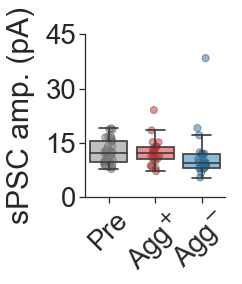

In [56]:
# sPSC_amp
sns.set(rc={"figure.figsize": (2.5, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

ax = sns.boxplot(x='Behaviour_6hFD', y='sPSC_Amplitude(pA)', data = ephys, order=['Pre', 'Agg+', 'Agg-'], saturation=8, 
                 linewidth=1.7, showfliers = False, palette = triple)
ax = sns.stripplot(x='Behaviour_6hFD', y='sPSC_Amplitude(pA)', data = ephys, order=['Pre', 'Agg+', 'Agg-'], jitter=True, dodge=False, 
                   marker='o', size=7, linewidth=1, edgecolor='gray', alpha=0.5, zorder=0, palette = triple)
ax.set_xlabel('')
ax.set_ylabel('sPSC amp. (pA)', labelpad=10)

ax.set_xticklabels(('Pre', r'Agg$^{+}$', r'Agg$^{-}$'), rotation=45)

ax.yaxis.set_major_locator(plt.MaxNLocator(3))
plt.ylim(0,45)
sns.despine(bottom=False, trim=False)

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, .5))
        
plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_5/linked_figure_S5/sPSC_amp.pdf',
            dpi=300,bbox_inches='tight', transparent=True)

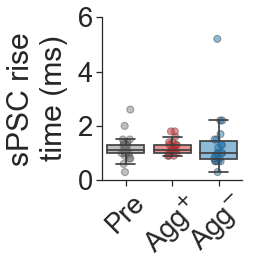

In [57]:
# sPSC rise time
sns.set(rc={"figure.figsize": (2.5, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

ax = sns.boxplot(x='Behaviour_6hFD', y='sPSCs_Rise time', data = ephys, order=['Pre', 'Agg+', 'Agg-'], saturation=8, 
                 linewidth=1.7, showfliers = False, palette = triple)
ax = sns.stripplot(x='Behaviour_6hFD', y='sPSCs_Rise time', data = ephys, order=['Pre', 'Agg+', 'Agg-'], jitter=True, dodge=False, 
                   marker='o', size=7, linewidth=1, edgecolor='gray', alpha=0.5, zorder=0, palette = triple)
ax.set_xlabel('')
ax.set_ylabel('sPSC rise\ntime (ms)', labelpad=10)

ax.set_xticklabels( ('Pre', r'Agg$^{+}$', r'Agg$^{-}$'), rotation=45)
ax.yaxis.set_major_locator(plt.MaxNLocator(3))
plt.ylim(0,6)
sns.despine(bottom=False, trim=False)

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, .5))
        
plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_5/linked_figure_S5/sPSC_rise.pdf',
            dpi=300,bbox_inches='tight', transparent=True)

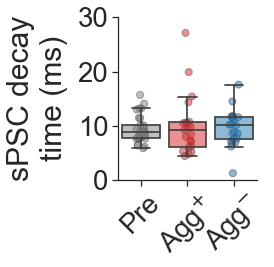

In [58]:
# sPSC decay time
sns.set(rc={"figure.figsize": (2.5, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

ax = sns.boxplot(x='Behaviour_6hFD', y='sPSCs (decay)', data = ephys, order=['Pre', 'Agg+', 'Agg-'], saturation=8, 
                 linewidth=1.7, showfliers = False, palette = triple)
ax = sns.stripplot(x='Behaviour_6hFD', y='sPSCs (decay)', data = ephys, order=['Pre', 'Agg+', 'Agg-'], jitter=True, dodge=False, 
                   marker='o', size=7, linewidth=1, edgecolor='gray', alpha=0.5, zorder=0, palette = triple)
ax.set_xlabel('')
ax.set_ylabel('sPSC decay\ntime (ms)', labelpad=10)

ax.set_xticklabels( ('Pre', r'Agg$^{+}$', r'Agg$^{-}$'), rotation=45)
ax.yaxis.set_major_locator(plt.MaxNLocator(3))
plt.ylim(0,30)
sns.despine(bottom=False, trim=False)

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, .5))
        
plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_5/linked_figure_S5/sPSC_decay.pdf',
            dpi=300,bbox_inches='tight', transparent=True)

## Gal+ vs Gal-

In [59]:
# gal = ephys[(ephys['Gal_positive'] == 'yes') & (ephys['Behaviour_6hFD'] == 'Agg+')]
# no_gal = ephys[(ephys['Gal_positive'] == 'no') & (ephys['Behaviour_6hFD'] == 'Agg+')]
# gals = pd.concat([gal,no_gal], axis = 0)
# len(no_gal)

In [60]:
# count_yes_agg = ((ephys['Gal_positive'] == 'yes') & (ephys['Behaviour_6hFD'] == 'Agg+')).sum()
# count_no_agg = ((ephys['Gal_positive'] == 'no') & (ephys['Behaviour_6hFD'] == 'Agg+')).sum()
# print(f"Number of Gal+ (Agg+) cells: {count_yes_agg}")
# print(f"Number of Gal- (Agg+) cells: {count_no_agg}")

In [61]:
# preprocess_plot(ephys[(ephys.Gal_positive.isin(['no', 'yes'])) & (ephys.Behaviour_6hFD.isin(['Agg-', 'Agg+']))], 
#                 'Gal_positive', 'gal', palette=['Gray', 'Tab:red'], order = ['no', 'yes'], plotting= True)

In [12]:
trial = ephys[ephys.Behaviour_6hFD.isin(['Pre'])]
trial = trial.rename(columns={'Ih_at_-120mV': 'ih_current', 
                              'Firing_freq_(Hz)_I0': 'firing_freq', 
                              'sPSC_Amplitude(pA)': 'sPSC_Amplitude'})
model = smf.ols('Input_Resistance ~  ih_current  ', data=trial).fit()
#model.summary()
sm.stats.anova_lm(model, typ=2)

,sum_sq,df,F,PR(>F)
ih_current,2.581054e+05,1.0,5.37375,0.02303
Residual,3.794432e+06,79.0,NaN,NaN


In [13]:
print("Coefficient of determination (R^2):", model.rsquared)

Coefficient of determination (R^2): 0.06368983080676316


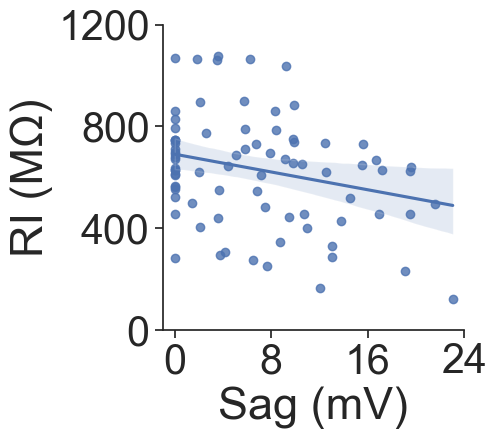

In [14]:
sns.set(font_scale=2.7) 
sns.set_style("ticks")
sns.lmplot(x = 'ih_current', y = 'Input_Resistance', data = trial, palette = ['darkgray', '#F97306', 'blue'], aspect=1.1)
plt.ylabel('RI (MΩ)')
plt.xlabel('Sag (mV)')
plt.ylim(0, 1200)
plt.yticks([0, 400, 800, 1200])
plt.xticks([0, 8, 16, 24])
plt.xlim(-1, 24)

plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_5/linked_figure_S5/ih_input_resistance.pdf',
            dpi=300,bbox_inches='tight', transparent=True)

In [65]:
# l = 'Instant_freq_(Hz)'
# max = ephys[l].max()
# cs = ['darkgray', '#F97306', 'Tab:blue']
# conds = ['Pre', 'Agg+', 'Agg-']
# fig, ax = plt.subplots(figsize=(2, 2))
# sns.ecdfplot(data=ephys[ephys.Behaviour_6hFD.isin(conds)], x=l, hue="Behaviour_6hFD", palette = cs, ax = ax)
# sns.despine()
# plt.legend(loc='center left', bbox_to_anchor=(1.05, 1), fontsize = 16)

# plt.savefig(f'output_figures/ECDF_{l}.png',dpi = 300, bbox_inches = 'tight')
# plt.show()

### Individual plots Gal+ vs Gal-

In [66]:
gals = df[(df.Gal_positive.isin(['yes', 'no'])) & (df.Behaviour_6hFD != 'Pre')]

In [67]:
print(f"Number of Gal+ neurons: {(gals['Gal_positive'] == 'yes').sum()} from {gals[gals['Gal_positive'] == 'yes']['ID_mouse'].nunique()} mice")
print(f"Number of Gal- neurons: {(gals['Gal_positive'] == 'no').sum()} from {gals[gals['Gal_positive'] == 'no']['ID_mouse'].nunique()} mice")

Number of Gal+ neurons: 9 from 3 mice
Number of Gal- neurons: 10 from 4 mice


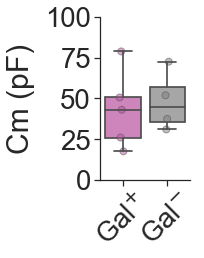

In [68]:
# Cm Gal+ vs Gal- 
sns.set(rc={"figure.figsize": (1.6, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

ax = sns.boxplot(x='Gal_positive', y='Cm(pF)', data = gals, saturation=8, linewidth=1.7, showfliers = False, palette = dual)
ax = sns.stripplot(x='Gal_positive', y='Cm(pF)', data = gals, jitter=True, dodge=False, marker='o', size=7, linewidth=1, 
                   edgecolor='gray', alpha=0.5, zorder=1, palette = dual)
ax.set_xlabel('')
ax.set_ylabel('Cm (pF)', labelpad=10)

ax.set_xticklabels((r'Gal$^{+}$', r'Gal$^{-}$'), rotation=45)

ax.yaxis.set_major_locator(plt.MaxNLocator(4))
plt.ylim(0,100)
sns.despine()

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, .7))
        
plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_6/linked_figure_S6/Cm.pdf',
            dpi=300,bbox_inches='tight', transparent=True)

In [69]:
# gals

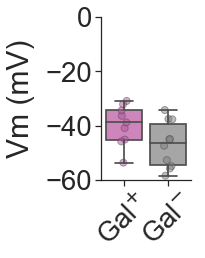

In [70]:
# Vm Gal+ vs Gal- 
sns.set(rc={"figure.figsize": (1.6, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

ax = sns.boxplot(x='Gal_positive', y='Vm', data = gals, saturation=8, linewidth=1.7, showfliers = False, palette = dual)
ax = sns.stripplot(x='Gal_positive', y='Vm', data = gals, jitter=True, dodge=False, marker='o', size=7, linewidth=1, 
                   edgecolor='gray', alpha=0.5, zorder=1, palette = dual)
ax.set_xlabel('')
ax.set_ylabel('Vm (mV)', labelpad=10)

ax.set_xticklabels((r'Gal$^{+}$', r'Gal$^{-}$'), rotation=45)
ax.yaxis.set_major_locator(plt.MaxNLocator(3))
plt.ylim(-60, 0)
sns.despine()

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, .7))
        
plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_6/linked_figure_S6/Vm.pdf',
            dpi=300,bbox_inches='tight', transparent=True)

In [71]:
# stats - U test
gal_positive_data = gals[gals['Gal_positive'] == 'yes']['Vm']
gal_negative_data = gals[gals['Gal_positive'] == 'no']['Vm']
u_statistic, p_value = mannwhitneyu(gal_positive_data, gal_negative_data)
print("Mann-Whitney U test p-value:", p_value)

Mann-Whitney U test p-value: 0.11134688653314041


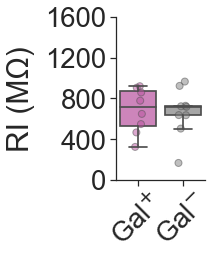

In [72]:
# RI Gal+ vs Gal- 
sns.set(rc={"figure.figsize": (1.6, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

ax = sns.boxplot(x='Gal_positive', y='Input_Resistance', data = gals, saturation=8, linewidth=1.7, showfliers = False, palette = dual)
ax = sns.stripplot(x='Gal_positive', y='Input_Resistance', data = gals, jitter=True, dodge=False, marker='o', size=7, linewidth=1, 
                   edgecolor='gray', alpha=0.5, zorder=1, palette = dual)
ax.set_xlabel('')
ax.set_ylabel('RI (MΩ)', labelpad=10)

ax.set_xticklabels((r'Gal$^{+}$', r'Gal$^{-}$'), rotation=45)
ax.yaxis.set_major_locator(plt.MaxNLocator(4))
plt.ylim(0, 1600)
sns.despine()

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, .7))
        
plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_6/linked_figure_S6/Ri.pdf',
            dpi=300,bbox_inches='tight', transparent=True)

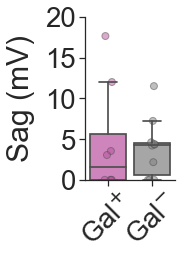

In [73]:
# Ih Gal+ vs Gal- 
sns.set(rc={"figure.figsize": (1.6, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

ax = sns.boxplot(x='Gal_positive', y='Ih_at_-120mV', data = gals, saturation=8, linewidth=1.7, showfliers = False, palette = dual)
ax = sns.stripplot(x='Gal_positive', y='Ih_at_-120mV', data = gals, jitter=True, dodge=False, marker='o', size=7, linewidth=1, 
                   edgecolor='gray', alpha=0.5, zorder=1, palette = dual)
ax.set_xlabel('')
ax.set_ylabel('Sag (mV)', labelpad=10)

ax.set_xticklabels((r'Gal$^{+}$', r'Gal$^{-}$'), rotation=45)
ax.yaxis.set_major_locator(plt.MaxNLocator(4))
plt.ylim(0, 20)
sns.despine()

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, .7))
        
plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_6/linked_figure_S6/Ih.pdf',
            dpi=300,bbox_inches='tight', transparent=True)

In [74]:
# stats - U test
gal_positive_sag = gals[gals['Gal_positive'] == 'yes']['Ih_at_-120mV'].dropna()
gal_negative_sag = gals[gals['Gal_positive'] == 'no']['Ih_at_-120mV'].dropna()
u_statistic, p_value = mannwhitneyu(gal_positive_sag, gal_negative_sag)
print("Mann-Whitney U test p-value:", p_value)

Mann-Whitney U test p-value: 0.6146465622110426


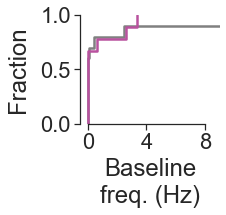

In [75]:
# Firing frequency Gal+ vs Gal-
sns.set(rc={"figure.figsize": (2.5, 2.0)})
sns.set(font_scale=2) 
sns.set_style("ticks")

cum = sns.ecdfplot(data=gals, x="Firing_freq_(Hz)_I0", hue="Gal_positive", palette = dual, linewidth=2.5, legend=False, stat='proportion')
cum.set_xlabel('Baseline\nfreq. (Hz)',labelpad=5)
cum.set_ylabel('Fraction',labelpad=10)
cum.xaxis.set_major_locator(plt.MaxNLocator(3))
plt.xlim(right=9)
sns.despine(trim=True)

plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_6/linked_figure_S6/ff.pdf',
            dpi=300,bbox_inches='tight', transparent=True)

## Silent proportion

I_zero_reclassified  phasic  silent  tonic  All
Behaviour_6hFD                                 
Agg+                      6       9      5   20
Agg-                      4       4     14   22
Pre                      19      28     58  105
ZD7288                    0       8      1    9
npy1r_antag               2       3     10   15
npy2r_antag               3       6      6   15
npy_100                   2       7      2   11
npy_antag                 4       3      9   16
npykd                     3       5     11   19
All                      43      73    116  232
0.009177157572716381


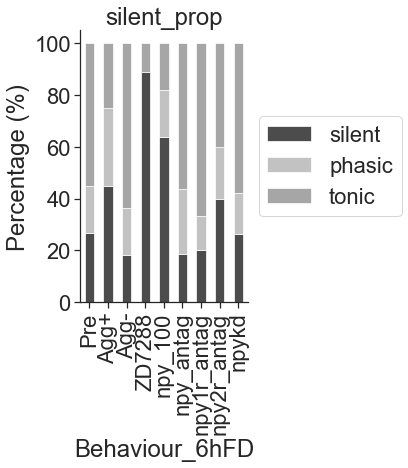

In [76]:
## silent proportion
cols = ['silent', 'phasic', 'tonic']
cat = ['Pre', 'Agg+', 'Agg-', 'ZD7288', 'npy_100',  'npy_antag','npy1r_antag', 'npy2r_antag', 'npykd']
silent_prop = proportion(ephys[ephys.Behaviour_6hFD.isin(cat)], 'Behaviour_6hFD', 'I_zero_reclassified', cols)
silent_prop['Behaviour_6hFD'] = pd.Categorical(silent_prop['Behaviour_6hFD'], cat)
silent_prop = silent_prop.sort_values(by = ['Behaviour_6hFD'])
prop_plot(silent_prop, 'Behaviour_6hFD')
plt.xticks(rotation = 90)
plt.title('silent_prop')
plt.savefig('output_figures/silent_prop.png',dpi = 300, bbox_inches = 'tight')

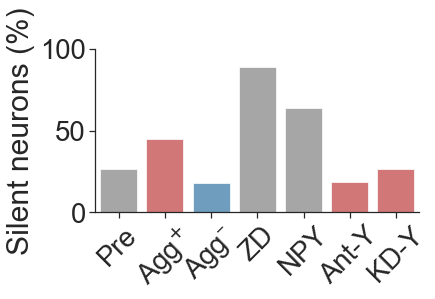

In [77]:
# % silent neurons - VERSION WITH ALL GROUPS
sns.set(rc={"figure.figsize": (5.8, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

g = sns.barplot(silent_prop, x="Behaviour_6hFD", y="silent", order=['Pre', 'Agg+', 'Agg-', 'ZD7288', 'npy_100','npy_antag', 'npykd'],
                palette = seven, alpha=0.7)
plt.ylabel('Silent neurons (%)', labelpad=5)
g.set_xticklabels( ('Pre', r'Agg$^{+}$', r'Agg$^{–}$','ZD', 'NPY', 'Ant-Y', 'KD-Y'), rotation=45)
plt.xlabel('')
plt.ylim(0,100)
g.yaxis.set_major_locator(plt.MaxNLocator(2)) 
sns.despine(bottom=False)
# plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Figure_3/linked_figure3/silent_prop_all.pdf',
# dpi=300,bbox_inches='tight', transparent=True)

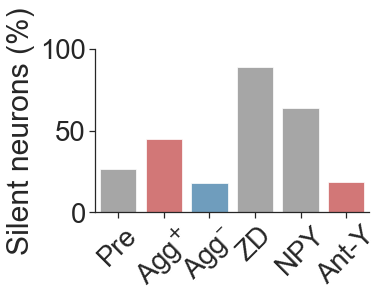

In [78]:
# % silent neurons - VERSION WITHOUT KD-Y
sns.set(rc={"figure.figsize": (4.9, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

g = sns.barplot(silent_prop, x="Behaviour_6hFD", y="silent", order=['Pre', 'Agg+', 'Agg-', 'ZD7288', 'npy_100','npy_antag'],
                palette = seven, alpha=0.7)
plt.ylabel('Silent neurons (%)', labelpad=5)
g.set_xticklabels( ('Pre', r'Agg$^{+}$', r'Agg$^{–}$','ZD', 'NPY', 'Ant-Y'), rotation=45)
plt.xlabel('')
plt.ylim(0,100)
g.yaxis.set_major_locator(plt.MaxNLocator(2)) 
sns.despine(bottom=False)
# plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Figure_3/linked_figure3/silent_prop_noKD.pdf',
# dpi=300,bbox_inches='tight', transparent=True)

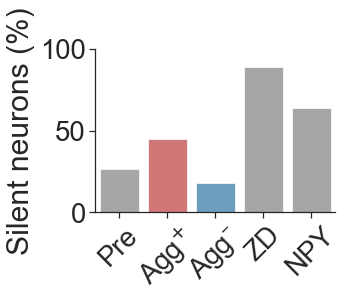

In [79]:
# % silent neurons - VERSION WITHOUT KD-Y and ANT
sns.set(rc={"figure.figsize": (4.3, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

g = sns.barplot(silent_prop, x="Behaviour_6hFD", y="silent", order=['Pre', 'Agg+', 'Agg-', 'ZD7288', 'npy_100'],
                palette = six, alpha=0.7)
plt.ylabel('Silent neurons (%)', labelpad=5)
g.set_xticklabels( ('Pre', r'Agg$^{+}$', r'Agg$^{–}$','ZD', 'NPY'), rotation=45)
plt.xlabel('')
plt.ylim(0,100)
g.yaxis.set_major_locator(plt.MaxNLocator(2)) 
sns.despine(bottom=False)
plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Figure_3/linked_figure3/silent_prop_noKD.pdf',
dpi=300,bbox_inches='tight', transparent=True)

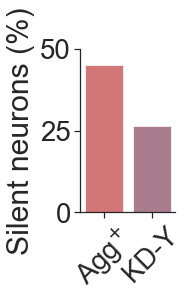

In [80]:
# % silent neurons - only Agg+ and KD-Y
sns.set(rc={"figure.figsize": (1.7, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

g = sns.barplot(silent_prop, x="Behaviour_6hFD", y="silent", order=['Agg+', 'npykd'],
                palette = ['Tab:red', '#8F3B5A'], alpha=0.7)
plt.ylabel('Silent neurons (%)', labelpad=5)
g.set_xticklabels( (r'Agg$^{+}$','KD-Y'), rotation=45)
plt.xlabel('')
plt.ylim(0,50)
g.yaxis.set_major_locator(plt.MaxNLocator(2)) 
sns.despine(bottom=False)
plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Figure_3/linked_figure3/silent_prop_KD.pdf',
dpi=300,bbox_inches='tight', transparent=True)

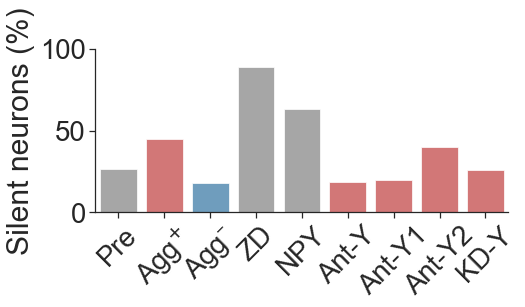

In [81]:
# % silent neurons - VERSION WITH ALL GROUPS INCL Y1/2
sns.set(rc={"figure.figsize": (7.4, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

g = sns.barplot(silent_prop, x="Behaviour_6hFD", y="silent", order=['Pre', 'Agg+', 'Agg-', 'ZD7288', 'npy_100','npy_antag', 'npy1r_antag', 'npy2r_antag','npykd'],
                palette = nine, alpha=0.7)
plt.ylabel('Silent neurons (%)', labelpad=5)
g.set_xticklabels( ('Pre', r'Agg$^{+}$', r'Agg$^{–}$','ZD', 'NPY', 'Ant-Y','Ant-Y1','Ant-Y2', 'KD-Y'), rotation=45)
plt.xlabel('')
plt.ylim(0,100)
g.yaxis.set_major_locator(plt.MaxNLocator(2)) 
sns.despine(bottom=False)
# plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_8/linked_figure_S8/silent_prop_all_Y12.pdf',
# dpi=300,bbox_inches='tight', transparent=True)

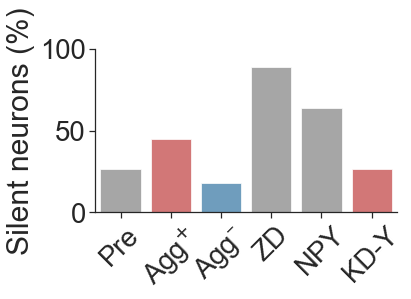

In [82]:
# % silent neurons - VERSION WITH ALL GROUPS but w/o Ant
sns.set(rc={"figure.figsize": (5.4, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

g = sns.barplot(silent_prop, x="Behaviour_6hFD", y="silent", order=['Pre', 'Agg+', 'Agg-', 'ZD7288', 'npy_100','npykd'],
                palette = six, alpha=0.7)
plt.ylabel('Silent neurons (%)', labelpad=5)
g.set_xticklabels( ('Pre', r'Agg$^{+}$', r'Agg$^{–}$','ZD', 'NPY', 'KD-Y'), rotation=45)
plt.xlabel('')
plt.ylim(0,100)
g.yaxis.set_major_locator(plt.MaxNLocator(2)) 
sns.despine(bottom=False)
plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_8/linked_figure_S8/silent_prop_all_Y12.pdf',
dpi=300,bbox_inches='tight', transparent=True)

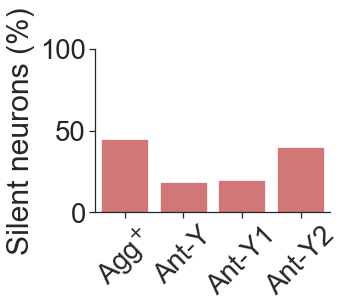

In [83]:
# % silent neurons - VERSION WITH ONLY ANT
sns.set(rc={"figure.figsize": (4.2, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

g = sns.barplot(silent_prop, x="Behaviour_6hFD", y="silent", order=['Agg+', 'npy_antag', 'npy1r_antag', 'npy2r_antag'],
                palette = ant, alpha=0.7)
plt.ylabel('Silent neurons (%)', labelpad=5)
g.set_xticklabels( (r'Agg$^{+}$', 'Ant-Y','Ant-Y1','Ant-Y2'), rotation=45)
plt.xlabel('')
plt.ylim(0,100)
g.yaxis.set_major_locator(plt.MaxNLocator(2)) 
sns.despine(bottom=False)
plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_8/linked_figure_S8/silent_prop_ant.pdf',
dpi=300,bbox_inches='tight', transparent=True)

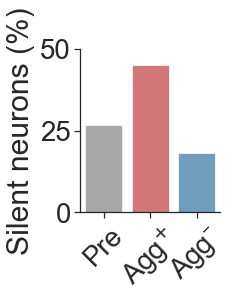

In [84]:
# % silent neurons - only Pre/Agg+/Agg-
sns.set(rc={"figure.figsize": (2.5, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

g = sns.barplot(silent_prop, x="Behaviour_6hFD", y="silent", order=['Pre', 'Agg+', 'Agg-'],
                palette = triple, alpha=0.7)
plt.ylabel('Silent neurons (%)', labelpad=5)
g.set_xticklabels( ('Pre', r'Agg$^{+}$', r'Agg$^{–}$'), rotation=45)
plt.xlabel('')
plt.ylim(0,50)
g.yaxis.set_major_locator(plt.MaxNLocator(2)) 
sns.despine(bottom=False)
plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Figure_3/linked_figure3/silent_prop_short.pdf',
dpi=300,bbox_inches='tight', transparent=True)

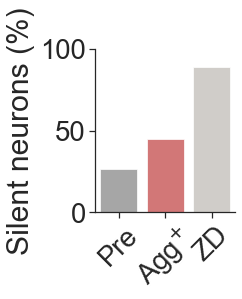

In [85]:
# % silent neurons - Pre/Agg+/ZD
sns.set(rc={"figure.figsize": (2.5, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

g = sns.barplot(silent_prop, x="Behaviour_6hFD", y="silent", order=['Pre', 'Agg+', 'ZD7288'],
                palette = ZD, alpha=0.7)
plt.ylabel('Silent neurons (%)', labelpad=5)
g.set_xticklabels( ('Pre', r'Agg$^{+}$', 'ZD'), rotation=45)
plt.xlabel('')
plt.ylim(0,100)
g.yaxis.set_major_locator(plt.MaxNLocator(2)) 
sns.despine(bottom=False)
plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_8/linked_figure_S8/silent_prop_ZD.pdf',
dpi=300,bbox_inches='tight', transparent=True)

In [86]:
# mouse numbers
filtered = ephys.dropna(subset=['I_zero_reclassified'])
mouse_counts = filtered.groupby('Behaviour_6hFD')['ID_mouse'].nunique()
mouse_counts

Behaviour_6hFD
Agg+               6
Agg-               3
Pre               17
ZD7288             1
ZD7288_20          1
agrp_100           5
npy1r_antag        2
npy2r_antag        3
npy_10             3
npy_100            4
npy_100_paired     0
npy_10_paired      0
npy_antag          3
npykd              3
Name: ID_mouse, dtype: int64

In [87]:
# stats
# make contingency table (based on ephys df, not silent_prop, which only has %)
ephys2 = ephys.copy()
ephys2['I_zero_reclassified'] = ephys2['I_zero_reclassified'].replace({'phasic': 'active', 'tonic': 'active'})
contingency_table = ephys2.groupby(['Behaviour_6hFD', 'I_zero_reclassified']).size().unstack(fill_value=0)
contingency_table['active'] = contingency_table.sum(axis=1) - contingency_table.get('silent', 0)
contingency_table = contingency_table[['silent', 'active']]
print(contingency_table)

# groups = ['Agg+','Agg-','Pre','ZD7288','npy_100','npy_antag','npykd'] #'npy1r_antag','npy2r_antag',

# (1) Pre/Agg+/Agg- ==================================

groups = ['Agg+','Agg-','Pre']
p_values = []
comparisons = []
from scipy.stats import fisher_exact

# Perform Fisher's exact test between each pair of groups
for i in range(len(groups)):
    for j in range(i + 1, len(groups)):
        group1 = groups[i]
        group2 = groups[j]
        
        # Create contingency table
        table = [
            [contingency_table.loc[group1, 'silent'], contingency_table.loc[group1, 'active']],
            [contingency_table.loc[group2, 'silent'], contingency_table.loc[group2, 'active']]
        ]
        
        # Perform Fisher's exact test
        _, p_value = fisher_exact(table)
        
        # Store the p-value and the comparison
        p_values.append(p_value)
        comparisons.append(f"{group1} vs {group2}")

# Apply Benjamini-Hochberg correction
reject, pvals_corrected, _, _ = multipletests(p_values, alpha=0.05, method='fdr_bh')

# Print the results
for comp, pval, pval_corr in zip(comparisons, p_values, pvals_corrected):
    print(f"Comparison: {comp}, Original p-value: {pval:.4e}, Corrected p-value: {pval_corr:.4e}")


# (2) Pre/ZD/NPY ==================================

groups = ['Pre', 'ZD7288', 'npy_100']
p_values = []
comparisons = []
from scipy.stats import fisher_exact

# Perform Fisher's exact test between each pair of groups
for i in range(len(groups)):
    for j in range(i + 1, len(groups)):
        group1 = groups[i]
        group2 = groups[j]
        
        # Create contingency table
        table = [
            [contingency_table.loc[group1, 'silent'], contingency_table.loc[group1, 'active']],
            [contingency_table.loc[group2, 'silent'], contingency_table.loc[group2, 'active']]
        ]
        
        # Perform Fisher's exact test
        _, p_value = fisher_exact(table)
        
        # Store the p-value and the comparison
        p_values.append(p_value)
        comparisons.append(f"{group1} vs {group2}")

# Apply Benjamini-Hochberg correction
reject, pvals_corrected, _, _ = multipletests(p_values, alpha=0.05, method='fdr_bh')

# Print the results
for comp, pval, pval_corr in zip(comparisons, p_values, pvals_corrected):
    print(f"Comparison: {comp}, Original p-value: {pval:.4e}, Corrected p-value: {pval_corr:.4e}")

# (3) Agg+/Ant-Y/KD-Y ==================================

groups = ['Agg+', 'npy_antag', 'npykd']
p_values = []
comparisons = []
from scipy.stats import fisher_exact

# Perform Fisher's exact test between each pair of groups
for i in range(len(groups)):
    for j in range(i + 1, len(groups)):
        group1 = groups[i]
        group2 = groups[j]
        
        # Create contingency table
        table = [
            [contingency_table.loc[group1, 'silent'], contingency_table.loc[group1, 'active']],
            [contingency_table.loc[group2, 'silent'], contingency_table.loc[group2, 'active']]
        ]
        
        # Perform Fisher's exact test
        _, p_value = fisher_exact(table)
        
        # Store the p-value and the comparison
        p_values.append(p_value)
        comparisons.append(f"{group1} vs {group2}")

# Apply Benjamini-Hochberg correction
reject, pvals_corrected, _, _ = multipletests(p_values, alpha=0.05, method='fdr_bh')

# Print the results
for comp, pval, pval_corr in zip(comparisons, p_values, pvals_corrected):
    print(f"Comparison: {comp}, Original p-value: {pval:.4e}, Corrected p-value: {pval_corr:.4e}")

I_zero_reclassified  silent  active
Behaviour_6hFD                     
Agg+                      9      11
Agg-                      4      18
Pre                      28      77
ZD7288                    8       1
ZD7288_20                 5       0
agrp_100                  5      10
npy1r_antag               3      12
npy2r_antag               6       9
npy_10                    2       8
npy_100                   7       4
npy_100_paired            4       0
npy_10_paired             5       1
npy_antag                 3      13
npykd                     5      14
Comparison: Agg+ vs Agg-, Original p-value: 9.5594e-02, Corrected p-value: 1.7103e-01
Comparison: Agg+ vs Pre, Original p-value: 1.1402e-01, Corrected p-value: 1.7103e-01
Comparison: Agg- vs Pre, Original p-value: 5.8986e-01, Corrected p-value: 5.8986e-01
Comparison: Pre vs ZD7288, Original p-value: 3.7867e-04, Corrected p-value: 1.1360e-03
Comparison: Pre vs npy_100, Original p-value: 1.7098e-02, Corrected p-value: 2.56

In [88]:
# % silent neurons CHECK WHETHER THESE VALUES ARE CORRECT!

ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
plt.savefig('output_figures/silent_prop.pdf',dpi = 300, bbox_inches = 'tight')

<Figure size 180x216 with 0 Axes>

I_zero        phasic  silent  tonic  All
Gal_positive                            
no                 0       6      4   10
yes                1       6      2    9
All                1      12      6   19
0.44518771279268876


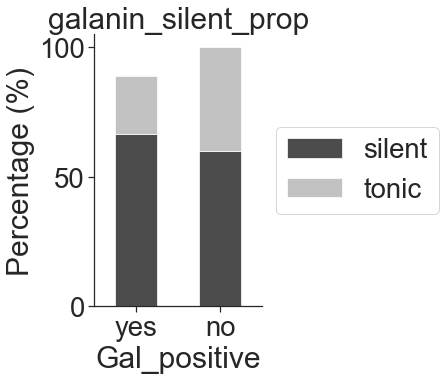

In [89]:
cols = ['silent', 'tonic']
silent_prop = proportion(gals, 'Gal_positive', 'I_zero', cols)
silent_prop['Gal_positive'] = pd.Categorical(silent_prop['Gal_positive'], ['yes', 'no'])
silent_prop = silent_prop.sort_values(by = ['Gal_positive'])
prop_plot(silent_prop, 'Gal_positive')
plt.title('galanin_silent_prop')
plt.savefig('output_figures/galanin_silent_prop.png',dpi = 300, bbox_inches = 'tight')

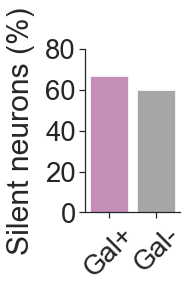

In [90]:
# % silent neurons
sns.set(rc={"figure.figsize": (1.7, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

g = sns.barplot(silent_prop, x="Gal_positive", y="silent", order=['yes', 'no'], palette = dual, alpha=0.7)
plt.ylabel('Silent neurons (%)', labelpad=10)
g.set_xticklabels(('Gal+', 'Gal-'), rotation=45)
plt.xlabel('')
plt.ylim(0,80)
g.yaxis.set_major_locator(plt.MaxNLocator(4)) 
sns.despine()
plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_6/linked_figure_S6/silent.pdf',
            dpi=300,bbox_inches='tight', transparent=True)

## Adaptive prop (DB)

In [91]:
## adaptive proportion
cols = ['yes', 'no']
cat = ['Pre', 'Agg+', 'Agg-', 'ZD7288', 'npy_100','npy_antag', 'npy1r_antag', 'npy2r_antag','npykd']
ad_prop = proportion(ephys[ephys.Behaviour_6hFD.isin(cat)], 'Behaviour_6hFD', 'Adaptive', cols)
# ad_prop['Behaviour_6hFD'] = pd.Categorical(ad_prop['Behaviour_6hFD'], cat)
# ad_prop = ad_prop.sort_values(by = ['Behaviour_6hFD'])
# ad_prop

Adaptive        ?  no  no   yes  All
Behaviour_6hFD                      
Agg+            1   7    0   12   20
Agg-            0  18    0    3   21
Pre             1  15    0   27   43
ZD7288          1   0    0    8    9
npy1r_antag     0   9    0    6   15
npy2r_antag     0  10    0    4   14
npy_100         0   7    0    2    9
npy_antag       0   5    0    5   10
npykd           0   9    1    9   19
All             3  80    1   76  160
0.009113257417879547


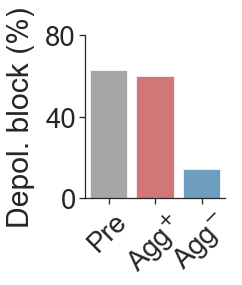

In [92]:
sns.set(rc={"figure.figsize": (2.5, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

g = sns.barplot(x = 'Behaviour_6hFD', y = 'yes', data = ad_prop, order=['Pre', 'Agg+', 'Agg-'], palette= triple, alpha = 0.7)

plt.ylabel('Depol. block (%)', labelpad=10)
g.set_xticklabels(('Pre', r'Agg$^{+}$', r'Agg$^{-}$'), rotation=45)

plt.xlabel('')
plt.ylim(top=60)
plt.yticks(np.arange(0, 81, 40))
sns.despine(bottom=False)

# plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Figure_3/linked_figure3/adaptive_prop.pdf',
# dpi=300,bbox_inches='tight', transparent=True)

In [93]:
# stats - Chi-Square test

cols = ['yes', 'no']
cat2 = ['Pre', 'Agg+', 'Agg-']
ad_prop2 = proportion(ephys[ephys.Behaviour_6hFD.isin(cat2)], 'Behaviour_6hFD', 'Adaptive', cols)

Adaptive        ?  no  yes  All
Behaviour_6hFD                 
Agg+            1   7   12   20
Agg-            0  18    3   21
Pre             1  15   27   43
All             2  40   42   84
0.0021382241674996086


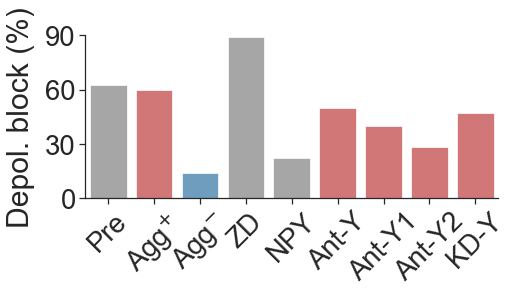

In [94]:
# adaptive proportion - VERSION WITH ALL GROUPS INCL Y1/2
sns.set(rc={"figure.figsize": (7.4, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

g = sns.barplot(x = 'Behaviour_6hFD', y = 'yes', data = ad_prop, order=['Pre', 'Agg+', 'Agg-', 'ZD7288', 'npy_100','npy_antag', 'npy1r_antag', 'npy2r_antag','npykd'], 
                palette= nine, alpha = 0.7)

ax.set_xlabel('')
plt.ylabel('Depol. block (%)', labelpad=10)

g.set_xticklabels( ('Pre', r'Agg$^{+}$', r'Agg$^{-}$','ZD','NPY','Ant-Y','Ant-Y1','Ant-Y2' ,'KD-Y'), rotation=45)

plt.xlabel('')
plt.yticks([0, 30, 60, 90])
plt.ylim(0, 90)
sns.despine(bottom=False)

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, .5))
    
# plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_8/linked_figure_S8/adaptive_prop_all.pdf',
#             dpi=300,bbox_inches='tight', transparent=True)

Adaptive      no  yes  All
Gal_positive              
no             5    3    8
yes            3    5    8
All            8    8   16
0.6170750774519739


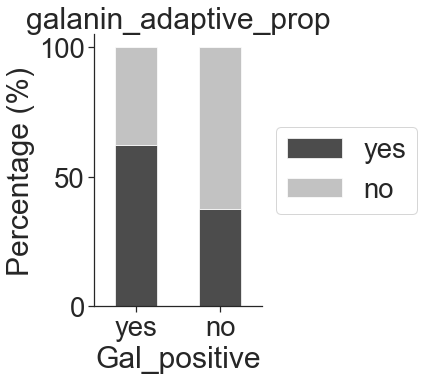

In [95]:
cols = ['yes', 'no']
ad_prop = proportion(gals, 'Gal_positive', 'Adaptive', cols)
ad_prop['Gal_positive'] = pd.Categorical(ad_prop['Gal_positive'], ['yes', 'no'])
ad_prop = ad_prop.sort_values(by = ['Gal_positive'])
prop_plot(ad_prop, 'Gal_positive')
plt.title('galanin_adaptive_prop')
plt.savefig('output_figures/galanin_adaptive_prop.png',dpi = 300, bbox_inches = 'tight')

## Calcium T prop

cat_categ        no  no   yes  yes   All
Behaviour_6hFD                          
Agg+             14    0    5     0   19
Agg-              9    1   11     1   22
Pre              51    0   31     0   82
ZD7288            6    0    3     0    9
ZD7288_20         2    0    1     0    3
agrp_100         13    0    2     0   15
npy1r_antag       9    0    6     0   15
npy2r_antag       9    0    5     0   14
npy_10            7    1    2     0   10
npy_100           6    0    5     0   11
npy_antag        14    0    1     0   15
npykd            14    0    5     0   19
All             154    2   77     1  234
0.20151323971527402


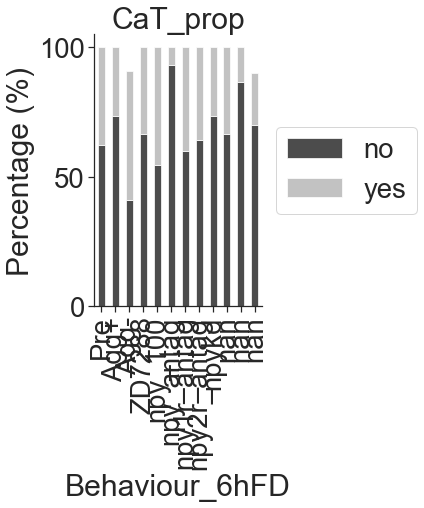

In [96]:
## calcium T proportion
cols = ['no', 'yes']
ca_prop = proportion(ephys, 'Behaviour_6hFD', 'cat_categ', cols)
ca_prop['Behaviour_6hFD'] = pd.Categorical(ca_prop['Behaviour_6hFD'],cat)
ca_prop = ca_prop.sort_values(by = ['Behaviour_6hFD'])
prop_plot(ca_prop, 'Behaviour_6hFD')
plt.xticks(rotation = 90)

plt.title('CaT_prop')
plt.savefig('output_figures/CaT_prop.png',dpi = 300, bbox_inches = 'tight')

cat_categ     no  yes  All
Gal_positive              
no             4    6   10
yes            5    3    8
All            9    9   18
0.6352562959972483


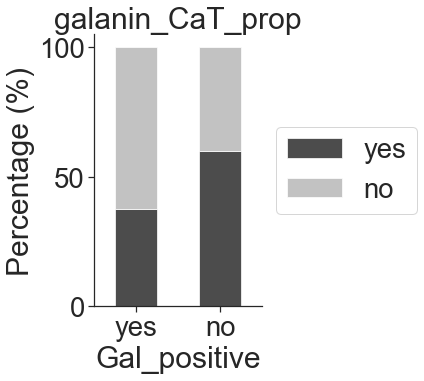

In [97]:
cols = ['yes', 'no']
ca_prop = proportion(gals, 'Gal_positive', 'cat_categ', cols)
ca_prop['Gal_positive'] = pd.Categorical(ca_prop['Gal_positive'], ['yes', 'no'])
ca_prop = ca_prop.sort_values(by = ['Gal_positive'])
prop_plot(ca_prop, 'Gal_positive')

plt.title('galanin_CaT_prop')
plt.savefig('output_figures/galanin_CaT_prop.png',dpi = 300, bbox_inches = 'tight')

## IH prop

IH              no  yes  All
Behaviour_6hFD              
Agg+             7   12   19
Agg-             1   21   22
Pre             24   58   82
ZD7288           9    0    9
ZD7288_20        3    0    3
agrp_100         6    9   15
npy1r_antag      4   11   15
npy2r_antag      2   12   14
npy_10           5    5   10
npy_100          6    5   11
npy_100_paired   2    1    3
npy_10_paired    0    5    5
npy_antag        3   12   15
npykd            1   18   19
All             73  169  242
9.489191283131947e-07


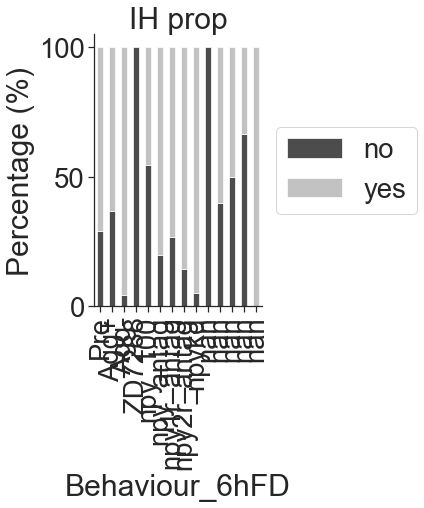

In [98]:
ephys.loc[(ephys['Ih_at_-120mV'] == 0), 'IH']  = 'no'
ephys.loc[(ephys['Ih_at_-120mV'] >0 ), 'IH']  = 'yes'
cols = ['no', 'yes']

ca_prop = proportion(ephys, 'Behaviour_6hFD', 'IH', cols)
ca_prop['Behaviour_6hFD'] = pd.Categorical(ca_prop['Behaviour_6hFD'], cat)
ca_prop = ca_prop.sort_values(by = ['Behaviour_6hFD'])
prop_plot(ca_prop, 'Behaviour_6hFD')

plt.title('IH prop')
plt.xticks(rotation = 90)
plt.savefig('output_figures/IH_prop.png',dpi = 300, bbox_inches = 'tight')

IH                   no  yes  All
I_zero_reclassified              
phasic                7   36   43
silent               36   49   85
tonic                30   84  114
All                  73  169  242
0.0046740809868728705


Text(0.5, 0, '')

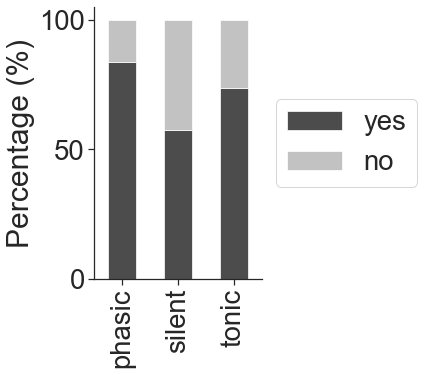

In [99]:
cols = ['yes', 'no']
ih_prop =  proportion(ephys, 'I_zero_reclassified', 'IH', cols)
# ca_prop = ca_prop.sort_values(by = ['Behaviour_6hFD'])
prop_plot(ih_prop, 'I_zero_reclassified')
plt.xticks(rotation = 90)
plt.xlabel('')

# Ramp analysis (excitability)

In [125]:
from glob import glob
path = '/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Figure_3/Analysis/Ramp'
states = ['Pre', 'Agg+', 'Agg-', 'NPY 10nM', 'NPY 100nM', 'NPY Antag', 'NPY-KD', 'ZD7288']

ramp_path = 'ramps_all.csv'
import os
if os.path.exists(ramp_path):
    df_state = pd.read_csv(ramp_path)

else:
    # list all directory in filepath
    df_state = pd.DataFrame()

    for state in states:
        files = [file for file in glob(f'{path}/{state}/*.xlsx')]
        df_files = []
        for file in files:
            try:
                df_file = pd.read_excel(file)
                df_file['filename'] = file
            except ValueError:
                print(file, state)
            df_files.append(df_file)

        df = pd.concat(df_files)
        df['state'] = state
        df_state = pd.concat([df_state, df])

    df_state.to_csv('ramps_all.csv')   

/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Figure_3/Analysis/Ramp/Agg-/~$S1C4 16102023.xlsx Agg-


In [126]:
df_state.rename(columns = {'I_Injected(pA)': 'Injected'}, inplace = True)
# df_state['Injected'] = pd.Categorical(df_state['Injected'], df_state['Injected'].unique()[:-2]).as_ordered()
df_state.sort_values('Injected', inplace = True)

df_state['state'] = pd.Categorical(df_state['state'], states).as_ordered()
# df_state.sort_values('Injected', inplace = True)


num_spike = df_state.groupby(by = ['filename', 'Injected']).size().reset_index(name ='num_spike')

df_all = df_state.groupby(['filename', 'Injected'], dropna = False).first().reset_index().drop_duplicates()

# df_state.loc[df['Event start '] == 0,'Event start '] = 2080
df_all['latency'] = df_all['Event start ']- df_all['Ramp_start']
df_all = df_all[df_all['latency'] > 0]
df_all = pd.merge(df_all, num_spike, on = ['filename', 'Injected'])

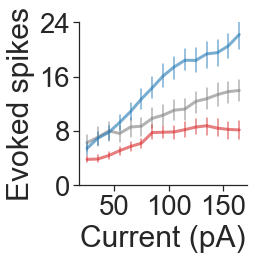

In [176]:
sns.set(font_scale=2.5) 
sns.set_style("ticks")

prop = 'num_spike'

plot_df = df_all[df_all.state.isin(['Pre', 'Agg+', 'Agg-'])]
fig, ax = plt.subplots(figsize = [3,3])

palette = ['gray', 'Tab:red', 'Tab:blue']
# df_all = df_all[df_all.state.isin(['Agg+', 'Pre'])]

sns.lineplot(data=plot_df, x="Injected", y=prop, hue = 'state', palette=palette, err_style="bars", ci=58,  
             linewidth=3, alpha=0.6)

leg = ax.get_legend()
if leg:
    leg.remove()

ax.set_ylabel("Evoked spikes")
ax.set_xlabel("Current (pA)")
plt.ylim(0,24)
ax.set_yticks([0, 8, 16, 24])
sns.despine(bottom=False)

plt.savefig(f'/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Figure_3/linked_figure3/{prop}.pdf',
            dpi=300,bbox_inches='tight', transparent=True)

In [103]:
# cell numbers
distinct_filename_counts = plot_df.groupby('state')['filename'].nunique()
print(distinct_filename_counts)

# stats - 2-WAY ANOVA
import statsmodels.api as sm
from statsmodels.formula.api import ols
model = ols('num_spike ~ C(Injected) + C(state) + C(Injected):C(state)', data=plot_df).fit()
result = sm.stats.anova_lm(model, type=2)
print(result)

import statsmodels.stats.multicomp as mc

# Perform Tukey's HSD test
mc_tukey = mc.MultiComparison(plot_df['num_spike'], plot_df['state'])
tukey_result = mc_tukey.tukeyhsd()
print(tukey_result)


state
Pre          23
Agg+         22
Agg-         21
NPY 10nM      0
NPY Antag     0
NPY-KD        0
ZD7288        0
Name: filename, dtype: int64
                         df        sum_sq      mean_sq          F  \
C(Injected)            14.0   7768.291510   554.877965   9.145485   
C(state)                6.0   9664.727168  1610.787861  26.548966   
C(Injected):C(state)   84.0   2593.413437    30.873969   0.508864   
Residual              848.0  51450.143346    60.672339        NaN   

                            PR(>F)  
C(Injected)           6.074856e-19  
C(state)              4.649029e-29  
C(Injected):C(state)  9.999173e-01  
Residual                       NaN  
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj  lower   upper  reject
---------------------------------------------------
  Agg+   Agg-   7.9699   0.0  6.3642  9.5755   True
  Agg+    Pre   3.6648   0.0  2.0699  5.2597   True
  Agg-    Pre  -4.3051   0.0 -5.9041 -2.7061   True
----------

In [104]:
df_all.state.unique()

['Agg+', 'Agg-', 'NPY 10nM', 'NPY Antag', 'NPY-KD', 'Pre', 'ZD7288']
Categories (7, object): ['Pre' < 'Agg+' < 'Agg-' < 'NPY 10nM' < 'NPY Antag' < 'NPY-KD' < 'ZD7288']

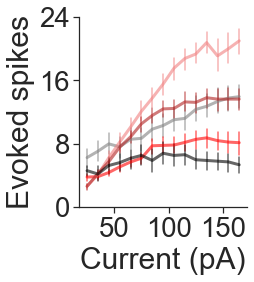

In [105]:
sns.set(font_scale=2.5) 
sns.set_style("ticks")

plot_df2 = df_all[df_all.state.isin(['Agg+', 'NPY Antag', 'NPY-KD', 'ZD7288', 'Pre'])]
fig, ax = plt.subplots(figsize = [3,3.5])

typ = 'Pre_Agg+_AntY_KD_ZD'
colors = {'Pre': 'gray', 'Agg+': 'red', 'ZD7288': 'black', 'NPY-KD': 'firebrick', 
          'NPY Antag': 'lightcoral', 'NPY 10nM': 'orange', 'Agg-': 'blue'}

sns.lineplot(data=plot_df2, x="Injected", y=prop, hue = 'state', palette=colors, err_style="bars", ci=58, linewidth=3, alpha=0.6)

leg = ax.get_legend()
if leg:
    leg.remove()

ax.set_ylabel("Evoked spikes")
ax.set_xlabel("Current (pA)")
ax.set_yticks([0, 8, 16, 24])
sns.despine(bottom=False)

# plt.savefig(f'/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Figure_3/linked_figure3/{typ}_pharma.pdf',
#             dpi=300,bbox_inches='tight', transparent=True)

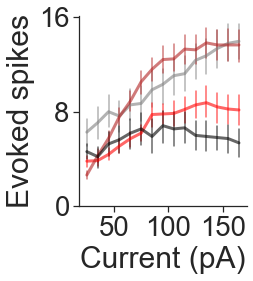

In [106]:
# without Ant-Y
sns.set(font_scale=2.5) 
sns.set_style("ticks")

plot_df_noAnt = df_all[df_all.state.isin(['Agg+', 'NPY-KD', 'ZD7288', 'Pre'])]
fig, ax = plt.subplots(figsize = [3,3.5])

typ = 'Pre_Agg+_KD_ZD'
colors = {'Pre': 'gray', 'Agg+': 'red', 'ZD7288': 'black', 'NPY-KD': 'firebrick', 
          'NPY Antag': 'lightcoral', 'NPY 10nM': 'orange', 'Agg-': 'blue'}

sns.lineplot(data=plot_df_noAnt, x="Injected", y=prop, hue = 'state', palette=colors, err_style="bars", ci=58, linewidth=3, alpha=0.6)

leg = ax.get_legend()
if leg:
    leg.remove()

ax.set_ylabel("Evoked spikes")
ax.set_xlabel("Current (pA)")
ax.set_yticks([0, 8, 16])
sns.despine(bottom=False)

plt.savefig(f'/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Figure_3/linked_figure3/{typ}_pharma.pdf',
            dpi=300,bbox_inches='tight', transparent=True)

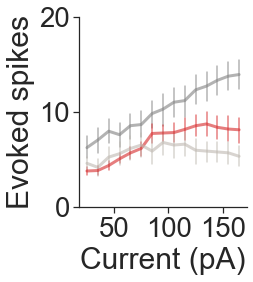

In [107]:
sns.set(font_scale=2.5) 
sns.set_style("ticks")

plot_df_zd = df_all[df_all.state.isin(['Agg+', 'ZD7288', 'Pre'])]
fig, ax = plt.subplots(figsize = [3,3.5])

typ = 'Pre_Agg+_ZD'
colors = {'Pre': 'gray', 'Agg+': 'Tab:red', 'ZD7288': warm_gray, 'NPY-KD': 'firebrick', 
          'NPY Antag': 'lightcoral', 'NPY 10nM': 'orange', 'Agg-': 'blue'}
sns.lineplot(data=plot_df_zd, x="Injected", y=prop, hue = 'state', palette=colors, err_style="bars", ci=58, linewidth=3, alpha=0.6)

leg = ax.get_legend()
if leg:
    leg.remove()

ax.set_ylabel("Evoked spikes")
ax.set_xlabel("Current (pA)")
ax.set_yticks([0, 10, 20])
sns.despine(bottom=False)

plt.savefig(f'/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Figure_3/linked_figure3/{typ}_pharma.pdf',
            dpi=300,bbox_inches='tight', transparent=True)

### Excitability across estrous cycle

In [108]:
# pull Pre cell IDs from df_all
unique_names_pre = df_all.loc[df_all['state'] == 'Pre', 'filename'].unique()
cell_names_pre = [filename.split('/')[-1] for filename in unique_names_pre if '/' in filename]

In [109]:
# Define dictionary with cell IDs and estrous state (data pulled from here: 
#/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Figure_3/Analysis/Ephys-6hFD-Virgin-vfinal.xlsx)
# NOTE: S1c1 27072023 is not in database - I'm assuming that's S1c1 24072023 in fact, which is E?

estrous_dict = {
    'S1C1 05012024': 'P',
    'S1C1 15012024': 'M',
    'S1C1 23112023': 'M',
    'S1C1 25052023': 'P',
    'S1C1 26092023': 'P',
    'S1C1 30072023': 'D',
    'S1C2 05012024': 'P',
    'S1C2 15012024': 'M',
    'S1C2 17062023': 'P',
    'S1C3 05012024': 'P',
    'S1C3 15012024': 'M',
    'S1C4 05012024': 'P',
    'S1C5 05012024': 'P',
    'S1C7 05012024': 'P',
    'S1c1 23072023': 'E',
    'S1c1 27072023': 'E',
    'S2C1 18092023': 'E', #original entry: P<E, used E after consulting Rachida
    'S2C1 25052023': 'M',
    'S2C1 25092023': 'D',
    'S2C1 30072023': 'D',
    'S2c1 24072023': 'E',
    'S3C1 19092023': 'M',
    'S3C1 30072023': 'D',
}

In [110]:
# function to loop over filenames and insert estrous state from dictionary when cell ID matches
def find_estrous_state(filename, state, estrous_dict):
    if state == 'Pre':
        for mouse_id in estrous_dict.keys():
            if mouse_id in filename:
                return estrous_dict[mouse_id]
    return None

df_all['estrous'] = df_all.apply(lambda row: find_estrous_state(row['filename'], row['state'], estrous_dict), axis=1)

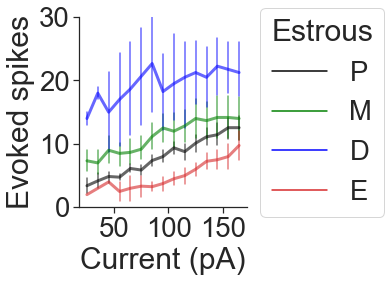

In [111]:
# plot excitability per estrous state
sns.set(font_scale=2.5) 
sns.set_style("ticks")

plot_df_e = df_all[df_all.state.isin(['Pre'])]
fig, ax = plt.subplots(figsize = [3,3.5])

typ = 'Pre_estrous'
colors = {'P': 'black', 'E': 'Tab:red', 'M': 'green', 'D': 'blue'}
sns.lineplot(data=plot_df_e, x="Injected", y=prop, palette=colors, hue = 'estrous', err_style="bars", ci=58, linewidth=3, alpha=0.6)

ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), title='Estrous')
ax.set_ylabel("Evoked spikes")
ax.set_xlabel("Current (pA)")
ax.set_yticks([0, 10, 20, 30])
plt.ylim(0, 30)
sns.despine(bottom=False)

# plt.savefig(f'/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Figure_3/linked_figure3/{typ}_pharma.pdf',
#             dpi=300,bbox_inches='tight', transparent=True)

In [112]:
# cell numbers
distinct_filename_counts2 = plot_df2.groupby('state')['filename'].nunique()
print(distinct_filename_counts2)

# stats - 2-WAY ANOVA
import statsmodels.api as sm
from statsmodels.formula.api import ols
model = ols('num_spike ~ C(Injected) + C(state) + C(Injected):C(state)', data=plot_df2).fit()
result = sm.stats.anova_lm(model, type=2)
print(result)

import statsmodels.stats.multicomp as mc

# Perform Tukey's HSD test
mc_tukey = mc.MultiComparison(plot_df2['num_spike'], plot_df2['state'])
tukey_result = mc_tukey.tukeyhsd()
print(tukey_result)

state
Pre          23
Agg+         22
Agg-          0
NPY 10nM      0
NPY Antag    10
NPY-KD       17
ZD7288       11
Name: filename, dtype: int64
                          df        sum_sq      mean_sq          F  \
C(Injected)             14.0   7292.202188   520.871585  12.539505   
C(state)                 6.0   7870.576216  1311.762703  31.579481   
C(Injected):C(state)    84.0   3528.515184    42.006133   1.011259   
Residual              1066.0  44279.987379    41.538450        NaN   

                            PR(>F)  
C(Injected)           1.459259e-27  
C(state)              4.477663e-35  
C(Injected):C(state)  4.540030e-01  
Residual                       NaN  
    Multiple Comparison of Means - Tukey HSD, FWER=0.05    
  group1    group2  meandiff p-adj   lower    upper  reject
-----------------------------------------------------------
     Agg+ NPY Antag   7.3847   -0.0   5.4058  9.3636   True
     Agg+    NPY-KD   3.6115    0.0    1.986   5.237   True
     Agg+       P

In [113]:
model = smf.ols('num_spike ~ C(Injected) * C(state)', data=df_all).fit()
sm.stats.anova_lm(model, typ=2)

,sum_sq,df,F,PR(>F)
C(Injected),15775.820789,14.0,23.619848,1.478581e-55
C(state),15298.990367,6.0,53.447166,8.688231e-60
C(Injected):C(state),4822.469130,84.0,1.203382,1.063789e-01
Residual,70320.883568,1474.0,NaN,NaN


In [114]:
# df['combination'] = df.Injected.astype(str) + " / " + df.Behaviour_6hFD
# m_comp = pairwise_tukeyhsd(endog=df['latency'], groups=df['combination'], alpha=0.05)
# m_comp._results_table

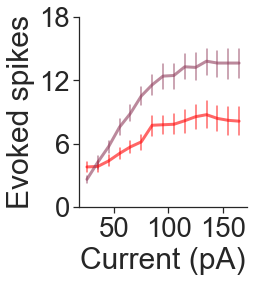

In [115]:
# only Agg+ and KD-Y

sns.set(font_scale=2.5) 
sns.set_style("ticks")

plot_df3 = df_all[df_all.state.isin(['Agg+', 'NPY-KD'])]
fig, ax = plt.subplots(figsize = [3,3.5])

typ = 'Agg+_KD'
colors = {'Pre': 'gray', 'Agg+': 'red', 'ZD7288': 'black', 'NPY-KD': '#8F3B5A', 
          'NPY Antag': 'lightcoral', 'NPY 10nM': 'orange', 'Agg-': 'blue'}
sns.lineplot(data=plot_df3, x="Injected", y=prop, hue = 'state', palette=colors, err_style="bars", ci=58, linewidth=3, alpha=0.6)

leg = ax.get_legend()
if leg:
    leg.remove()

ax.set_ylabel("Evoked spikes")
ax.set_xlabel("Current (pA)")
ax.set_yticks([0, 6, 12, 18])
sns.despine(bottom=False)

plt.savefig(f'/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Figure_3/linked_figure3/{typ}_pharma.pdf',
            dpi=300,bbox_inches='tight', transparent=True)

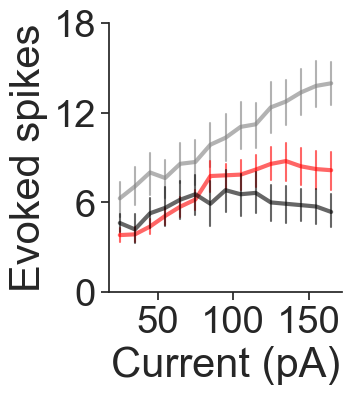

In [136]:
sns.set(font_scale=2.5) 
sns.set_style("ticks")
prop = 'num_spike'
plot_df3 = df_all[df_all.state.isin(['ZD7288', 'Agg+', 'Pre'])]
fig, ax = plt.subplots(figsize = [3,3.5])

typ = 'Agg+_KD'
colors = {'Pre': 'gray', 'Agg+': 'red', 'ZD7288': 'black', 'NPY-KD': '#8F3B5A', 
          'NPY Antag': 'lightcoral', 'NPY 10nM': 'orange', 'Agg-': 'blue', 'NPY 100nM': 'yellow'}
sns.lineplot(data=plot_df3, x="Injected", y=prop, hue = 'state', palette=colors, err_style="bars", ci=58, linewidth=3, alpha=0.6)

leg = ax.get_legend()
if leg:
    leg.remove()

ax.set_ylabel("Evoked spikes")
ax.set_xlabel("Current (pA)")
ax.set_yticks([0, 6, 12, 18])
sns.despine(bottom=False)

plt.savefig('/Volumes/lab-kohlj/home/shared/people/Mingran/theis_figure/Figure3/linked_figure3/excitability_ZD.pdf',
            dpi=300,bbox_inches='tight', transparent=True)

In [116]:
model = ols('num_spike ~ C(Injected) + C(state) + C(Injected):C(state)', data=plot_df3).fit()
result = sm.stats.anova_lm(model, type=2)
print(result)

                         df        sum_sq     mean_sq          F        PR(>F)
C(Injected)            14.0   3251.293345  232.235239   7.261325  7.069987e-14
C(state)                6.0   2041.680583  340.280097  10.639575  3.702339e-11
C(Injected):C(state)   84.0   1370.605541   16.316733   0.510177  9.998856e-01
Residual              516.0  16502.963887   31.982488        NaN           NaN


# Estrous cycle influence

I_zero_reclassified  phasic  silent  tonic  All
estrous_stage                                  
?                         1       1      2    4
D                         5       7     16   28
E                         2       3      3    8
M                         3       7     14   24
P                         6       6     12   24
VS to be stained          0       0      1    1
no VS                     1       2      9   12
not taken                 1       2      1    4
All                      19      28     58  105
0.9417552913501139
I_zero_reclassified  phasic  silent  tonic  All
estrous_stage                                  
D                         2       5      3   10
E                         3       1      0    4
P                         1       3      2    6
All                       6       9      5   20
0.27718991430409357


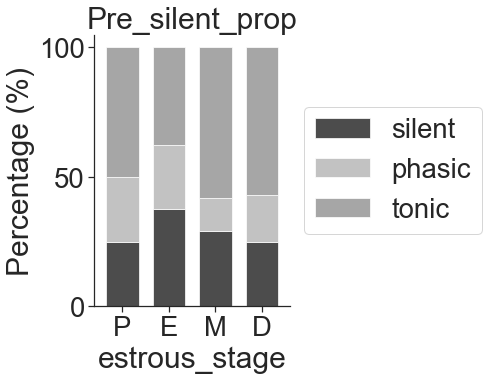

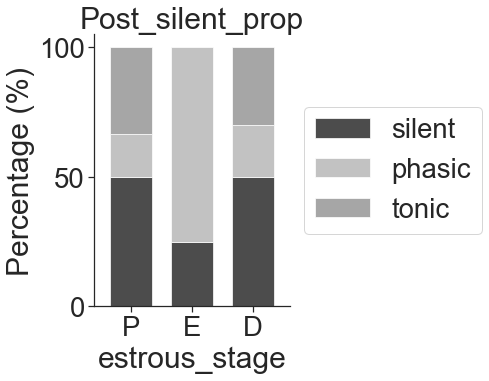

In [117]:
# silent proportion
ephys = pd.read_csv('sampled_ephys_data.csv')

ephys = ephys[ephys.I_zero_reclassified.isin(['silent', 'phasic', 'tonic'])] # was previously I_zero...
ephys.loc[(ephys['estrous_stage'] == 'P to E'), 'estrous_stage']  = 'P'
ephys.loc[(ephys['estrous_stage'] == 'D to P'), 'estrous_stage']  = 'D'
cols = ['silent', 'phasic', 'tonic']
ephys.loc[ephys.Behaviour_6hFD.isin(['Agg+']),'Behaviour_6hFD'] = 'Post'

for state in ['Pre', 'Post']:
    state_df = ephys[ephys.Behaviour_6hFD == state]
    silent_prop = proportion(state_df, 'estrous_stage', 'I_zero_reclassified', cols)
    silent_prop['estrous_stage'] = pd.Categorical(silent_prop['estrous_stage'], ['P', 'E', 'M', 'D'])
    silent_prop = silent_prop.sort_values(by = ['estrous_stage'])
    silent_prop = silent_prop[silent_prop.estrous_stage.isin(['P', 'E', 'M', 'D'])]
    


    silent_prop.plot(x = 'estrous_stage', 
            kind = 'bar', 
            stacked = True,  
            mark_right = False,
            color = ['black', 'darkgray','gray'],
            figsize = (3.5,5), alpha = 0.7, width = 0.7)
 
        
    plt.xticks(rotation = 0)
    ax = plt.gca()
    plt.ylabel('Percentage (%)')
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    
    plt.title(f'{state}_silent_prop')
    plt.savefig(f'output_figures/{state}_silent_prop.png',dpi = 300, bbox_inches = 'tight')

I_zero_reclassified  phasic  silent  tonic  All
estrous_stage                                  
?                         1       1      2    4
D                         5       7     16   28
E                         2       3      3    8
M                         3       7     14   24
P                         6       6     12   24
VS to be stained          0       0      1    1
no VS                     1       2      9   12
not taken                 1       2      1    4
All                      19      28     58  105
0.9417552913501139


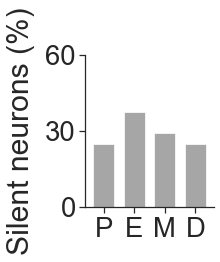

In [174]:
# silent proportion
ephys = pd.read_csv('sampled_ephys_data.csv')

ephys = ephys[ephys.I_zero_reclassified.isin(['silent', 'phasic', 'tonic'])]
ephys.loc[(ephys['estrous_stage'] == 'P to E'), 'estrous_stage']  = 'P'
ephys.loc[(ephys['estrous_stage'] == 'D to P'), 'estrous_stage']  = 'D'
cols = ['silent', 'phasic', 'tonic']
ephys.loc[ephys.Behaviour_6hFD.isin(['Agg-','Agg+']),'Behaviour_6hFD'] = 'Post'
ephys_stats = ephys.copy()

for state in ['Pre']: #Post Pre --> change filename accordingly
    state_df = ephys[ephys.Behaviour_6hFD == state]
    silent_prop = proportion(state_df, 'estrous_stage', 'I_zero_reclassified', cols) # was previously I_zero
    silent_prop['estrous_stage'] = pd.Categorical(silent_prop['estrous_stage'], ['P', 'E', 'M', 'D'])
    silent_prop = silent_prop.sort_values(by = ['estrous_stage'])
    silent_prop = silent_prop[silent_prop.estrous_stage.isin(['P', 'E', 'M', 'D'])]
    

    sns.set(font_scale=2.5)
    sns.set_style("ticks")
    silent_prop.plot(x = 'estrous_stage', y = 'silent',
            kind = 'bar', 
            stacked = False,  
            mark_right = False,
            color = ['gray'],
            figsize = (2.3,2.8), alpha = 0.7, width = 0.7)
 
        
    
    plt.xticks(rotation = 0)
    ax = plt.gca()
    plt.ylabel('Silent neurons (%)', labelpad=10)
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    plt.xlabel(None)
    plt.ylim(0,60) 
    plt.yticks([0, 60, 30])
    ax.get_legend().remove()

    plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_9/linked_figure_S9/silent_estrous_pre.pdf',
                dpi=300,bbox_inches='tight', transparent=True)

In [119]:
# STATS - PRE =================================================

ephys_pre = ephys_stats[ephys_stats['Behaviour_6hFD'] == 'Pre']

# Group the data by 'estrous_stage' and 'I_zero_reclassified', and count the occurrences
grouped_counts = ephys_pre.groupby(['estrous_stage', 'I_zero_reclassified']).size().unstack(fill_value=0)

# Filter out 'active' entries (phasic and tonic)
grouped_counts['active'] = grouped_counts.get('phasic', 0) + grouped_counts.get('tonic', 0)

# Drop the individual counts for 'phasic' and 'tonic'
grouped_counts.drop(columns=['phasic', 'tonic'], inplace=True, errors='ignore')

# Add a column for 'silent' if it doesn't exist
if 'silent' not in grouped_counts.columns:
    grouped_counts['silent'] = 0

# Filter to include only 'P', 'M', 'E', 'D'
pre_counts = grouped_counts.loc[grouped_counts.index.isin(['P', 'M', 'E', 'D'])]

print(pre_counts)

# Fisher's exact test 
def fisher_test(group1, group2, table):
    contingency_table = table.loc[[group1, group2], ['silent', 'active']].values
    oddsratio, p_value = stats.fisher_exact(contingency_table)
    return oddsratio, p_value

groups = ['P', 'M', 'E', 'D']

results = []
for i in range(len(groups)):
    for j in range(i+1, len(groups)):
        group1 = groups[i]
        group2 = groups[j]
        oddsratio, p_value = fisher_test(group1, group2, pre_counts)
        results.append((group1, group2, oddsratio, p_value))

results_pre_df = pd.DataFrame(results, columns=['Group1', 'Group2', 'OddsRatio', 'PValue'])
print(f"Pre stats: \n{results_pre_df}")

# STATS - POST =================================================

ephys_post = ephys_stats[ephys_stats['Behaviour_6hFD'] == 'Post']

# Group the data by 'estrous_stage' and 'I_zero_reclassified', and count the occurrences
grouped_counts = ephys_post.groupby(['estrous_stage', 'I_zero_reclassified']).size().unstack(fill_value=0)

# Filter out 'active' entries (phasic and tonic)
grouped_counts['active'] = grouped_counts.get('phasic', 0) + grouped_counts.get('tonic', 0)

# Drop the individual counts for 'phasic' and 'tonic'
grouped_counts.drop(columns=['phasic', 'tonic'], inplace=True, errors='ignore')

# Add a column for 'silent' if it doesn't exist
if 'silent' not in grouped_counts.columns:
    grouped_counts['silent'] = 0

# Filter to include only 'P', 'M', 'E', 'D'
post_counts = grouped_counts.loc[grouped_counts.index.isin(['P', 'M', 'E', 'D'])]

print(post_counts)

results = []
for i in range(len(groups)):
    for j in range(i+1, len(groups)):
        group1 = groups[i]
        group2 = groups[j]
        oddsratio, p_value = fisher_test(group1, group2, post_counts)
        results.append((group1, group2, oddsratio, p_value))

results_post_df = pd.DataFrame(results, columns=['Group1', 'Group2', 'OddsRatio', 'PValue'])
print(f"Post stats: \n{results_post_df}")

I_zero_reclassified  silent  active
estrous_stage                      
D                         7      21
E                         3       5
M                         7      17
P                         6      18
Pre stats: 
  Group1 Group2  OddsRatio    PValue
0      P      M   0.809524  1.000000
1      P      E   0.555556  0.654498
2      P      D   1.000000  1.000000
3      M      E   0.686275  0.680786
4      M      D   1.235294  0.763512
5      E      D   1.800000  0.657626
I_zero_reclassified  silent  active
estrous_stage                      
D                         5       5
E                         1       3
M                         1       9
P                         6      12
Post stats: 
  Group1 Group2  OddsRatio    PValue
0      P      M   4.500000  0.364244
1      P      E   1.500000  1.000000
2      P      D   0.500000  0.444263
3      M      E   0.333333  0.505495
4      M      D   0.111111  0.140867
5      E      D   0.333333  0.580420


-0.5709724581245323 0.42902754187546766


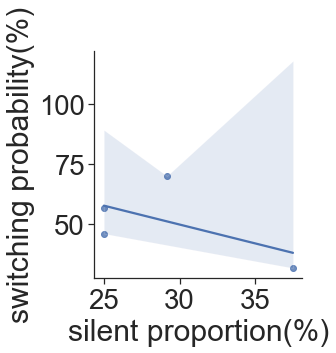

In [120]:
import scipy as sp
estrous_df = pd.read_csv('../NPS_behaviour_analysis/generated_datasets/estrous_data.csv')
estrous_df.rename(columns = {'Unnamed: 0':'estrous_stage', '0':'switching probability'}, inplace = True)
corr = pd.merge(silent_prop, estrous_df, on = 'estrous_stage')

r, p = sp.stats.pearsonr(corr['switching probability'], corr['silent'])
print(r, p)
sns.lmplot(x = 'silent', y = 'switching probability', data = corr)
plt.xlabel('silent proportion(%)')
plt.ylabel('switching probability(%)')
plt.savefig('output_figures/silent_switching_corr.png', dpi = 300, bbox_inches = 'tight')

In [121]:
# import multiple comparison
from statsmodels.stats.multicomp import pairwise_tukeyhsd

Ih_at_-120mV 0.009539512286860998
 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower    upper  reject
-----------------------------------------------------
     D      E  -0.0639    1.0  -6.9404  6.8126  False
     D      M  -5.7691  0.018  -10.791 -0.7472   True
     D      P  -0.2183 0.9995  -5.2996   4.863  False
     E      M  -5.7052 0.1378 -12.5817  1.1713  False
     E      P  -0.1544 0.9999  -7.0744  6.7656  False
     M      P   5.5508 0.0268   0.4695 10.6321   True
-----------------------------------------------------


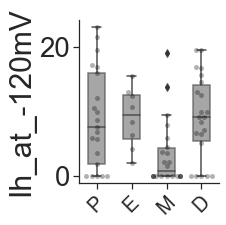

In [122]:
# IH current
ls = ['Cm(pF)', 'Firing_freq_(Hz)_I0','Instant_freq_(Hz)', 'isi_(ms)',  'CaT',  'Ih_at_-120mV', 'AP_ampl', 'AP_halfwidth', 'AP_time_to_peak','area(mV_ms)', 'rheobase_at_-60mV_(pA)', 'AHP_(mV)', 'Vm',
       'Input_Resistance', 'sPSC_frequency', 'sPSC_Amplitude(pA)','sPSCs_Rise time', 'sPSCs (decay)', 'AC-I0', 'AC_-60']

# ls = ['Ih_at_-120mV']

for state in ['Pre']:  #change Pre/Post accordingly!
    for column in ls:
        # state_df = ephys[ephys.Behaviour_6hFD == state]
        state_df = ephys.copy()
        state_df['estrous_stage'] = pd.Categorical(state_df['estrous_stage'], ['P', 'E', 'M', 'D'])
        state_df = state_df[state_df.Behaviour_6hFD == state]
        
        try:

            _, p = stats.f_oneway(state_df[column][state_df['estrous_stage'] == 'P'].dropna(),
                                    state_df[column][state_df['estrous_stage'] == 'E'].dropna(),
                                    state_df[column][state_df['estrous_stage'] == 'M'].dropna(),
                                    state_df[column][state_df['estrous_stage'] == 'D'].dropna())
        
            
            

            
            if p < 0.05:
                print(column , p)
                state_df = state_df.loc[:, ['estrous_stage', column]].dropna()
                multiple_comp_result = pairwise_tukeyhsd(endog=state_df[column],
                                         groups=state_df['estrous_stage'],
                                        alpha=0.05)
                print(multiple_comp_result.summary())

                fig,ax = plt.subplots(figsize = (2.5,3))
                sns.swarmplot(x='estrous_stage', y =column, data= state_df, alpha = 0.3, color = 'black')
                sns.boxplot(x='estrous_stage', y =column, data= state_df, boxprops=dict(alpha=0.7), width = 0.5, palette = ['gray'])
                sns.despine()
                plt.xticks(rotation = 45, fontsize = 20)
                # plt.ylabel('Ih current (pA)', fontsize = 25)
                plt.xlabel('')
            
                # plt.title(f'{state}_{column}', pad = 20)
                plt.savefig(f'output_figures/{state}_{column}.png',dpi = 300, bbox_inches = 'tight')
            
            plt.show()
        except Exception:
            continue

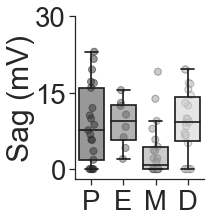

In [175]:
# Ih - estrous Pre/Post
sns.set(rc={"figure.figsize": (2.3, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

ax = sns.boxplot(x='estrous_stage', y='Ih_at_-120mV', data = state_df, order=['P', 'E', 'M', 'D'], saturation=8, 
                 linewidth=1.7, showfliers = False, palette = 'gray')
ax = sns.stripplot(x='estrous_stage', y='Ih_at_-120mV', data = state_df, order=['P', 'E', 'M', 'D'], jitter=True, dodge=False, 
                   marker='o', size=7, linewidth=1, edgecolor='gray', palette = 'gray', alpha=0.5, zorder=0)
ax.set_xlabel('')
ax.set_ylabel('Sag (mV)', labelpad=0)

ax.set_xticklabels( ('P', 'E', 'M', 'D'))
ax.yaxis.set_major_locator(plt.MaxNLocator(3))
plt.ylim(-2, 30)
sns.despine(bottom=False, trim=False)

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, .5))
    
# plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Figure_3/linked_figure3/Ih_estrous_pre.pdf',
#             dpi=300,bbox_inches='tight', transparent=True)

In [124]:
group_counts = state_df['estrous_stage'].value_counts()
print(f"Cell numbers: \n{group_counts}")
unique_counts = state_df.groupby('estrous_stage')['ID_mouse'].nunique()
print(f"Mouse numbers: \n{unique_counts}")

Cell numbers: 
D    28
P    24
M    24
E     8
Name: estrous_stage, dtype: int64
Mouse numbers: 
estrous_stage
P    8
E    3
M    6
D    3
Name: ID_mouse, dtype: int64


IH                 no  yes  All
estrous_stage                  
?                   0    4    4
D                   5   17   22
E                   0    8    8
M                  11   11   22
P                   5   16   21
VS to be stained    1    0    1
not taken           2    2    4
All                24   58   82
0.0352565677238345
IH estrous_stage         no         yes
4              P  23.809524   76.190476
2              E   0.000000  100.000000
3              M  50.000000   50.000000
1              D  22.727273   77.272727


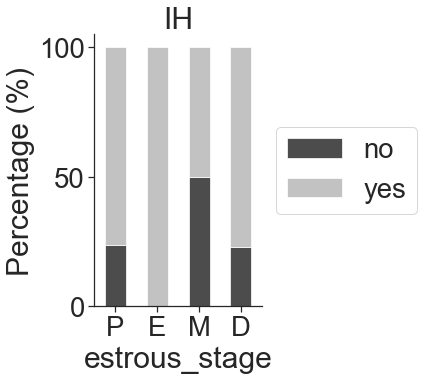

0.9665783850876505 0.03342161491234952


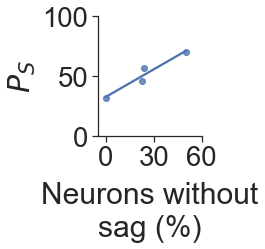

In [125]:
import scipy as sp
cols = ['no', 'yes']
ephys.loc[(ephys['Ih_at_-120mV'] == 0), 'IH']  = 'no'
ephys.loc[(ephys['Ih_at_-120mV'] >0 ), 'IH']  = 'yes'


estrous_df = pd.read_csv('../NPS_behaviour_analysis/generated_datasets/estrous_data.csv')
estrous_df.rename(columns = {'Unnamed: 0':'estrous_stage', '0':'switching probability'}, inplace = True)
ephys_pre = ephys[ephys.Behaviour_6hFD == 'Pre']

for column in ['IH']: #cat_categ', 'IH', 'Adaptive'
    esprop = proportion(ephys_pre, 'estrous_stage', column, cols)
    esprop['estrous_stage'] = pd.Categorical(esprop['estrous_stage'], ['P', 'E', 'M', 'D'])
    esprop = esprop.sort_values(by = ['estrous_stage']).dropna()
    prop_plot(esprop, 'estrous_stage')
    print(esprop)
    plt.title(column)
    plt.show()

    corr = pd.merge(esprop, estrous_df, on = 'estrous_stage')
    r, p = sp.stats.pearsonr(corr['switching probability'], corr['no'])
    print(r, p)

    sns.set(font_scale=2.5)
    sns.set_style("ticks")
    sns.lmplot(x = 'no', y = 'switching probability', data = corr, ci = None, height=3.5, aspect=1) #plt.xlabel(r'$\mathit{P}_{\mathit{S}}$')
    plt.ylim([0, 100])
    plt.xlim([-5, 60])
    plt.xticks([0, 30, 60])
    plt.xlabel('Neurons without\nsag (%)', labelpad=10)#plt.xlabel(f'% {column}')
    plt.ylabel(r'$\mathit{P}_{\mathit{S}}$') #plt.ylabel('Switching probability(%)')
#     plt.savefig(f'/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_9/linked_figure_S9/{column}_switching_corr.pdf',
#             dpi=300,bbox_inches='tight', transparent=True)
    plt.show()

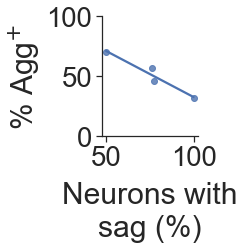

In [126]:
corr['100_minus_no'] = 100 - corr['no']

sns.set(font_scale=2.5)
sns.set_style("ticks")
sns.lmplot(x = '100_minus_no', y = 'switching probability', data = corr, ci = None, height=3.5, aspect=1) #plt.xlabel(r'$\mathit{P}_{\mathit{S}}$')
plt.ylim([0, 100])
# plt.xlim([-5, 60])
# plt.xticks([0, 30, 60])
plt.xlabel('Neurons with\nsag (%)', labelpad=10)#plt.xlabel(f'% {column}')
plt.ylabel(r'% Agg$^{+}$') #plt.ylabel('Switching probability(%)')
plt.savefig(f'/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_9/linked_figure_S9/sag_switching_corr.pdf',
            dpi=300,bbox_inches='tight', transparent=True)

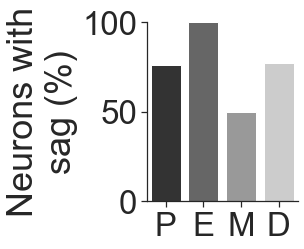

In [127]:
# Plot % of neurons that have Ih per estrous state
sns.set(rc={"figure.figsize": (2.7, 3.3)})
sns.set(font_scale=3) 
sns.set_style("ticks")
sns.barplot(x='estrous_stage', y='yes', data=esprop,  palette = 'gray')
plt.xlabel('')
plt.ylabel('Neurons with\nsag (%)')
plt.ylim(0, 100)
sns.despine(bottom=False)
# plt.savefig(f'/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_9/linked_figure_S9/percent_sag_estrous.pdf',
#             dpi=300,bbox_inches='tight', transparent=True)

IH                 no  yes  All
estrous_stage                  
?                   0    4    4
D                   5   17   22
E                   0    8    8
M                  11   11   22
P                   5   16   21
VS to be stained    1    0    1
not taken           2    2    4
All                24   58   82
0.0352565677238345
Adaptive           ?  no  yes  All
estrous_stage                     
?                  0   0    1    1
D                  0   4    6   10
E                  0   1    1    2
M                  0   7   11   18
P                  1   3    7   11
VS to be stained   0   0    1    1
All                1  15   27   43
0.9166519983189608
-0.28454513665146397 0.715454863348536


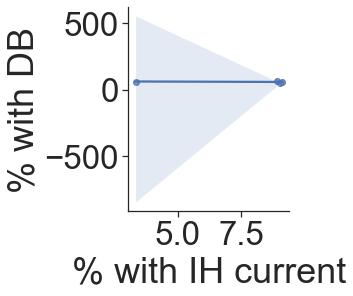

In [128]:

cols = ['no', 'yes']
estrous_stages = ['P', 'E', 'M', 'D']
ih_prop = proportion(ephys_pre, 'estrous_stage', 'IH', cols)
ih_est_mean = ephys_pre.groupby('estrous_stage')['Ih_at_-120mV'].mean().reset_index()
adaptive_prop = proportion(ephys_pre, 'estrous_stage', 'Adaptive', cols)
merged_df = pd.merge(ih_est_mean, adaptive_prop, on = 'estrous_stage')
merged_df = merged_df[merged_df.estrous_stage.isin(estrous_stages)]


r, p = sp.stats.pearsonr(merged_df['Ih_at_-120mV'], merged_df['yes'])
print(r, p)

sns.lmplot(x = 'Ih_at_-120mV', y = 'yes', data = merged_df)
# plt.ylim([0, /100])
plt.xlabel('% with IH current')
plt.ylabel('% with DB')
plt.show()

### Corr btw Sag amplitude and %Agg+

In [129]:
from scipy.optimize import curve_fit

def func(x, a, b, c):
    return a * np.exp(-b * x) + c

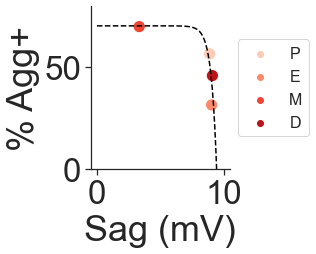

In [130]:
# mean of IH with estrous stage
mean_ih = ephys_pre.groupby('estrous_stage')['Ih_at_-120mV'].mean().reset_index()
grouped_df = pd.merge(mean_ih, estrous_df, on = 'estrous_stage')

x = grouped_df['Ih_at_-120mV']
y = grouped_df['switching probability']*100
popt, pcov = curve_fit(func, x, y)

plot_x = np.linspace(0, 10, 100)
plot_y = func(plot_x, *popt) /100


plt.subplots(figsize = (2.5, 3))
plt.plot(plot_x, plot_y, color = 'black', linestyle = '--')

sns.scatterplot(x = 'Ih_at_-120mV', y = 'switching probability', hue = 'estrous_stage',data = grouped_df, 
                hue_order=  ['P', 'E', 'M', 'D'], palette = 'Reds', alpha = 1, s = 150 )
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize = 16)
plt.xlabel('Sag (mV)')
plt.ylabel('% Agg+')
plt.ylim(0,80)
# plt.xlim(0,10)
sns.despine()
plt.show()

## Individual plots

### Pre

In [131]:
# We're plotting by estrous state from all 'Pre' values here
ephys_estrous = ephys[ephys['Behaviour_6hFD'] == 'Pre']

In [132]:
print(f"Number of P neurons: {(ephys_estrous['estrous_stage'] == 'P').sum()} from {ephys_estrous[ephys_estrous['estrous_stage'] == 'P']['ID_mouse'].nunique()} mice")
print(f"Number of E neurons: {(ephys_estrous['estrous_stage'] == 'E').sum()} from {ephys_estrous[ephys_estrous['estrous_stage'] == 'E']['ID_mouse'].nunique()} mice")
print(f"Number of M neurons: {(ephys_estrous['estrous_stage'] == 'M').sum()} from {ephys_estrous[ephys_estrous['estrous_stage'] == 'M']['ID_mouse'].nunique()} mice")
print(f"Number of D neurons: {(ephys_estrous['estrous_stage'] == 'D').sum()} from {ephys_estrous[ephys_estrous['estrous_stage'] == 'D']['ID_mouse'].nunique()} mice")

Number of P neurons: 24 from 8 mice
Number of E neurons: 8 from 3 mice
Number of M neurons: 24 from 6 mice
Number of D neurons: 28 from 3 mice


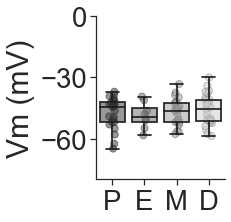

In [133]:
# Membrane voltage - estrous Pre

sns.set(rc={"figure.figsize": (2.3, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

ax = sns.boxplot(x='estrous_stage', y='Vm', data = ephys_estrous, order=['P', 'E', 'M', 'D'], saturation=8, 
                 linewidth=1.7, showfliers = False, palette = 'gray')
ax = sns.stripplot(x='estrous_stage', y='Vm', data = ephys_estrous, order=['P', 'E', 'M', 'D'], jitter=True, dodge=False, 
                   marker='o', size=7, linewidth=1, edgecolor='gray', palette = 'gray', alpha=0.5, zorder=0)
ax.set_xlabel('')
ax.set_ylabel('Vm (mV)', labelpad=5)

ax.set_xticklabels( ('P', 'E', 'M', 'D'))
ax.yaxis.set_major_locator(plt.MaxNLocator(3))
plt.ylim(-80, 0)
sns.despine(bottom=False, trim=False)

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, .5))
    
# plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_9/linked_figure_S9/Vm_estrous_pre.pdf',
#             dpi=300,bbox_inches='tight', transparent=True)

In [134]:
# stats - one-way ANOVA
groups = ephys_estrous.groupby('estrous_stage')['Vm'].apply(lambda x: x.dropna().tolist())
groups = [group for group in groups if len(group) > 0]
anova_result = f_oneway(*groups)
print("One-way ANOVA p-value:", anova_result.pvalue)

One-way ANOVA p-value: 0.22429936442994927


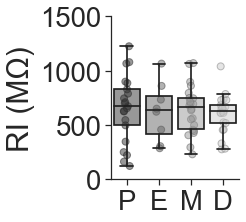

In [135]:
# Input resistance - estrous Pre

sns.set(rc={"figure.figsize": (2.3, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

ax = sns.boxplot(x='estrous_stage', y='Input_Resistance', data = ephys_estrous, order=['P', 'E', 'M', 'D'], saturation=8, 
                 linewidth=1.7, showfliers = False, palette = 'gray')
ax = sns.stripplot(x='estrous_stage', y='Input_Resistance', data = ephys_estrous, order=['P', 'E', 'M', 'D'], jitter=True, dodge=False, 
                   marker='o', size=7, linewidth=1, edgecolor='gray', palette = 'gray', alpha=0.5, zorder=0)
ax.set_xlabel('')
ax.set_ylabel('RI (MΩ)', labelpad=5)

ax.set_xticklabels( ('P', 'E', 'M', 'D'))
ax.yaxis.set_major_locator(plt.MaxNLocator(3))
plt.ylim(0, 1500)
sns.despine(bottom=False, trim=False)

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, .5))
    
# plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_9/linked_figure_S9/Ri_estrous_pre.pdf',
#             dpi=300,bbox_inches='tight', transparent=True)

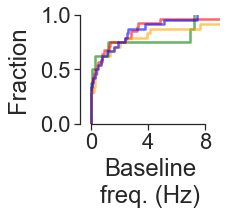

In [136]:
# Firing frequency - estrous Pre

# 'estrous_stage' contains entries that are not P, E, M or D. Filter those out first.
custom_palette = {'P': 'blue', 'E': 'green', 'M': 'orange', 'D': 'red'}
valid_estrous_stages = ['P', 'E', 'M', 'D']
ephys_estrous2 = ephys_estrous[ephys_estrous['estrous_stage'].isin(valid_estrous_stages)]

sns.set(rc={"figure.figsize": (2.5, 2.0)})
sns.set(font_scale=2) 
sns.set_style("ticks")

cum = sns.ecdfplot(data=ephys_estrous2, x="Firing_freq_(Hz)_I0", hue="estrous_stage", linewidth=2.5, legend=False,
                   stat='proportion', palette = custom_palette, alpha=.6)
cum.set_xlabel('Baseline\nfreq. (Hz)',labelpad=5)
cum.set_ylabel('Fraction',labelpad=10)
cum.xaxis.set_major_locator(plt.MaxNLocator(3))
plt.xlim(right=9)
sns.despine(trim=True)

# plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_9/linked_figure_S9/ff_estrous_pre.pdf',
#             dpi=300,bbox_inches='tight', transparent=True)

In [137]:
estrous_counts = ephys_estrous2['estrous_stage'].value_counts()
estrous_counts

D    28
P    24
M    24
E     8
Name: estrous_stage, dtype: int64

In [138]:
# stats - one-way ANOVA
groups = ephys_estrous2.groupby('estrous_stage')['Firing_freq_(Hz)_I0'].apply(lambda x: x.dropna().tolist())
groups = [group for group in groups if len(group) > 0]
anova_result = f_oneway(*groups)
print("One-way ANOVA p-value:", anova_result.pvalue)

One-way ANOVA p-value: 0.8407559272648756


### Post (Agg+/- pooled)

In [139]:
# We're plotting by estrous state from all 'Agg+' and 'Agg-' values here
ephys = pd.read_csv('sampled_ephys_data.csv')
ephys_post = ephys[(ephys['Behaviour_6hFD'] == 'Agg+') | (ephys['Behaviour_6hFD'] == 'Agg-')]

In [140]:
print(f"Number of P neurons: {(ephys_post['estrous_stage'] == 'P').sum()} from {ephys_post[ephys_post['estrous_stage'] == 'P']['ID_mouse'].nunique()} mice")
print(f"Number of E neurons: {(ephys_post['estrous_stage'] == 'E').sum()} from {ephys_post[ephys_post['estrous_stage'] == 'E']['ID_mouse'].nunique()} mice")
print(f"Number of M neurons: {(ephys_post['estrous_stage'] == 'M').sum()} from {ephys_post[ephys_post['estrous_stage'] == 'M']['ID_mouse'].nunique()} mice")
print(f"Number of D neurons: {(ephys_post['estrous_stage'] == 'D').sum()} from {ephys_post[ephys_post['estrous_stage'] == 'D']['ID_mouse'].nunique()} mice")

Number of P neurons: 12 from 2 mice
Number of E neurons: 4 from 1 mice
Number of M neurons: 10 from 1 mice
Number of D neurons: 8 from 2 mice


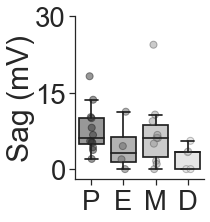

In [141]:
# Ih - Post
sns.set(rc={"figure.figsize": (2.3, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

ax = sns.boxplot(x='estrous_stage', y='Ih_at_-120mV', data = ephys_post, order=['P', 'E', 'M', 'D'], saturation=8, 
                 linewidth=1.7, showfliers = False, palette = 'gray')
ax = sns.stripplot(x='estrous_stage', y='Ih_at_-120mV', data = ephys_post, order=['P', 'E', 'M', 'D'], jitter=True, dodge=False, 
                   marker='o', size=7, linewidth=1, edgecolor='gray', palette = 'gray', alpha=0.5, zorder=1)
ax.set_xlabel('')
ax.set_ylabel('Sag (mV)', labelpad=0)

ax.set_xticklabels( ('P', 'E', 'M', 'D'))
ax.yaxis.set_major_locator(plt.MaxNLocator(3))
plt.ylim(-2, 30)
sns.despine(bottom=False, trim=False)

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, .5))
    
# plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_9/linked_figure_S9/Ih_estrous_post.pdf',
#             dpi=300,bbox_inches='tight', transparent=True)

In [142]:
# stats - one-way ANOVA
groups = ephys_post.groupby('estrous_stage')['Ih_at_-120mV'].apply(lambda x: x.dropna().tolist())
groups = [group for group in groups if len(group) > 0]
anova_result = f_oneway(*groups)
print("One-way ANOVA p-value:", anova_result.pvalue)

One-way ANOVA p-value: 0.1936249789011663


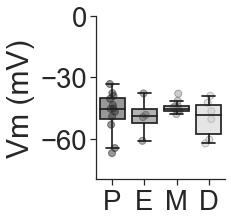

In [143]:
# Membrane voltage - estrous Post

sns.set(rc={"figure.figsize": (2.3, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

ax = sns.boxplot(x='estrous_stage', y='Vm', data = ephys_post, order=['P', 'E', 'M', 'D'], saturation=8, 
                 linewidth=1.7, showfliers = False, palette = 'gray')
ax = sns.stripplot(x='estrous_stage', y='Vm', data = ephys_post, order=['P', 'E', 'M', 'D'], jitter=True, dodge=False, 
                   marker='o', size=7, linewidth=1, edgecolor='gray', palette = 'gray', alpha=0.5, zorder=0)
ax.set_xlabel('')
ax.set_ylabel('Vm (mV)', labelpad=5)

ax.set_xticklabels( ('P', 'E', 'M', 'D'))
ax.yaxis.set_major_locator(plt.MaxNLocator(3))
plt.ylim(-80, 0)
sns.despine(bottom=False, trim=False)

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, .5))
    
# plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_9/linked_figure_S9/Vm_estrous_post.pdf',
#             dpi=300,bbox_inches='tight', transparent=True)

In [144]:
# stats - one-way ANOVA
groups = ephys_post.groupby('estrous_stage')['Vm'].apply(lambda x: x.dropna().tolist())
groups = [group for group in groups if len(group) > 0]
anova_result = f_oneway(*groups)
print("One-way ANOVA p-value:", anova_result.pvalue)

One-way ANOVA p-value: 0.8264960448371363


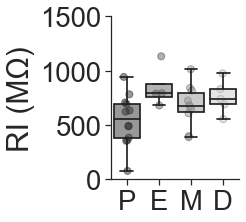

In [145]:
# Input resistance - estrous Post

sns.set(rc={"figure.figsize": (2.3, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

ax = sns.boxplot(x='estrous_stage', y='Input_Resistance', data = ephys_post, order=['P', 'E', 'M', 'D'], saturation=8, 
                 linewidth=1.7, showfliers = False, palette = 'gray')
ax = sns.stripplot(x='estrous_stage', y='Input_Resistance', data = ephys_post, order=['P', 'E', 'M', 'D'], jitter=True, dodge=False, 
                   marker='o', size=7, linewidth=1, edgecolor='gray', palette = 'gray', alpha=0.5, zorder=0)
ax.set_xlabel('')
ax.set_ylabel('RI (MΩ)', labelpad=5)

ax.set_xticklabels( ('P', 'E', 'M', 'D'))
ax.yaxis.set_major_locator(plt.MaxNLocator(3))
plt.ylim(0, 1500)
sns.despine(bottom=False, trim=False)

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, .5))
    
# plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_9/linked_figure_S9/Ri_estrous_post.pdf',
#             dpi=300,bbox_inches='tight', transparent=True)

In [146]:
# stats - one-way ANOVA
groups = ephys_post.groupby('estrous_stage')['Input_Resistance'].apply(lambda x: x.dropna().tolist())
groups = [group for group in groups if len(group) > 0]
anova_result = f_oneway(*groups)
print("One-way ANOVA p-value:", anova_result.pvalue)

One-way ANOVA p-value: 0.104779402307478


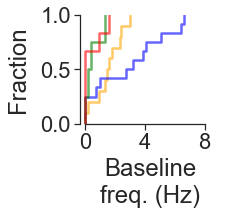

In [147]:
# Firing frequency - estrous Post

# 'estrous_stage' contains entries that are not P, E, M or D. Filter those out first. NOTE THAT THIS REMOVES E.G. 'P to E' ETC. 
#- IT MIGHT BE BETTER TO RECLASSIFY THOSE
custom_palette = {'P': 'blue', 'E': 'green', 'M': 'orange', 'D': 'red'}
valid_estrous_stages = ['P', 'E', 'M', 'D']
ephys_post2 = ephys_post[ephys_post['estrous_stage'].isin(valid_estrous_stages)]

sns.set(rc={"figure.figsize": (2.5, 2.0)})
sns.set(font_scale=2) 
sns.set_style("ticks")

cum = sns.ecdfplot(data=ephys_post2, x="Firing_freq_(Hz)_I0", hue="estrous_stage", linewidth=2.5, legend=False,
                   stat='proportion', palette = custom_palette, alpha=.6)
cum.set_xlabel('Baseline\nfreq. (Hz)',labelpad=5)
cum.set_ylabel('Fraction',labelpad=10)
cum.xaxis.set_major_locator(plt.MaxNLocator(3))
plt.xlim(right=9)
sns.despine(trim=True)

# plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_9/linked_figure_S9/ff_estrous_post.pdf',
#             dpi=300,bbox_inches='tight', transparent=True)

In [148]:
# stats - one-way ANOVA
groups = ephys_post2.groupby('estrous_stage')['Firing_freq_(Hz)_I0'].apply(lambda x: x.dropna().tolist())
groups = [group for group in groups if len(group) > 0]
anova_result = f_oneway(*groups)
print("One-way ANOVA p-value:", anova_result.pvalue)

# Tukey HSD 
ephys_post3 = ephys_post2.dropna(subset=['Firing_freq_(Hz)_I0', 'estrous_stage'])
tukey_results = pairwise_tukeyhsd(ephys_post3['Firing_freq_(Hz)_I0'], ephys_post3['estrous_stage'])
print(tukey_results)

One-way ANOVA p-value: 0.02302615717756743
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
     D      E   0.0408    1.0  -2.908 2.9896  False
     D      M   1.0803  0.601 -1.2787 3.4394  False
     D      P   2.3917 0.0375  0.1075 4.6758   True
     E      M   1.0395 0.7218 -1.6631 3.7421  False
     E      P   2.3508 0.0937 -0.2867 4.9883  False
     M      P   1.3113 0.2808 -0.6447 3.2674  False
---------------------------------------------------


# NPY administration

In [51]:
# reload data and convert all instances of NPY application to 'npy'
# UPDATE: use updated npy_100 column!
ephys = pd.read_csv('sampled_ephys_data.csv')
ephys_npy = ephys.copy()
# ephys_npy['Behaviour_6hFD'] = ephys_npy['Behaviour_6hFD'].replace(['npy_10_paired', 'npy_10', 'npy_100_paired', 'npy_100'], 'npy')


In [52]:
print(f"Number of Pre neurons: {(ephys_npy['Behaviour_6hFD'] == 'Pre').sum()} from {ephys_npy[ephys_npy['Behaviour_6hFD'] == 'Pre']['ID_mouse'].nunique()} mice")
print(f"Number of NPY neurons: {(ephys_npy['Behaviour_6hFD'] == 'npy_100').sum()} from {ephys_npy[ephys_npy['Behaviour_6hFD'] == 'npy_100']['ID_mouse'].nunique()} mice")

Number of Pre neurons: 107 from 17 mice
Number of NPY neurons: 11 from 4 mice


In [53]:
# ephys_npy

In [54]:
ephys_npy.Behaviour_6hFD.unique()

array(['Pre', 'Agg+', 'Agg-', 'npy_antag', 'npy1r_antag', 'npy2r_antag',
       'npy_10_paired', 'npy_10', 'npy_100_paired', 'npy_100', 'agrp_100',
       'ZD7288', 'ZD7288_20', 'npykd'], dtype=object)

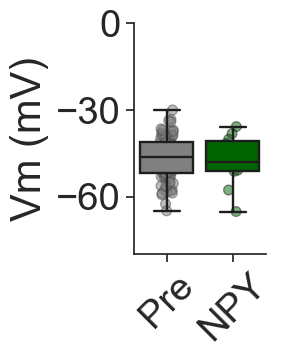

In [55]:
# Membrane voltage / RMP + NPY

sns.set(rc={"figure.figsize": (1.7, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

ax = sns.boxplot(x='Behaviour_6hFD', y='Vm', data = ephys_npy, order=['Pre', 'npy_100'], saturation=8, 
                 linewidth=1.7, showfliers = False, palette = npy)
ax = sns.stripplot(x='Behaviour_6hFD', y='Vm', data = ephys_npy, order = ['Pre', 'npy_100'], jitter=True, 
                   dodge=False, marker='o', size=7, linewidth=1, edgecolor='gray', palette = npy, alpha=0.5, zorder=0)
ax.set_xlabel('')
ax.set_ylabel('Vm (mV)', labelpad=5)

ax.set_xticklabels( ('Pre', 'NPY'), rotation=45)
ax.yaxis.set_major_locator(plt.MaxNLocator(3))
plt.ylim(-80, 0)
sns.despine(bottom=False, trim=False)

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, .5))
    
plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_7/linked_figure_S7/Vm_npy.pdf',
            dpi=300,bbox_inches='tight', transparent=True)

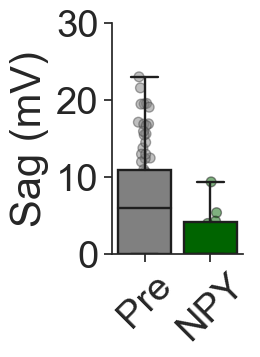

In [56]:
# Ih + NPY

sns.set(rc={"figure.figsize": (1.7, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

ax = sns.boxplot(x='Behaviour_6hFD', y='Ih_at_-120mV', data = ephys_npy, order=['Pre', 'npy_100'], saturation=8, 
                 linewidth=1.7, showfliers = False, palette = npy)
ax = sns.stripplot(x='Behaviour_6hFD', y='Ih_at_-120mV', data = ephys_npy, order = ['Pre', 'npy_100'], jitter=True, 
                   dodge=False, marker='o', size=7, linewidth=1, edgecolor='gray', palette = npy, alpha=0.5, zorder=0)
ax.set_xlabel('')
ax.set_ylabel('Sag (mV)', labelpad=5)

ax.set_xticklabels( ('Pre', 'NPY'), rotation=45)
ax.yaxis.set_major_locator(plt.MaxNLocator(3))
plt.ylim(0, 30)
sns.despine(bottom=False, trim=False)

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, .5))
    
plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_7/linked_figure_S7/Ih_npy.pdf',
            dpi=300,bbox_inches='tight', transparent=True)

In [57]:
# stats U test
pre_data = ephys_npy[ephys_npy['Behaviour_6hFD'] == 'Pre']['Ih_at_-120mV'].dropna()
npy_100_data = ephys_npy[ephys_npy['Behaviour_6hFD'] == 'npy_100']['Ih_at_-120mV'].dropna()
u_statistic, p_value = mannwhitneyu(pre_data, npy_100_data)
print("Mann-Whitney U test p-value:", p_value)

NameError: name 'mannwhitneyu' is not defined

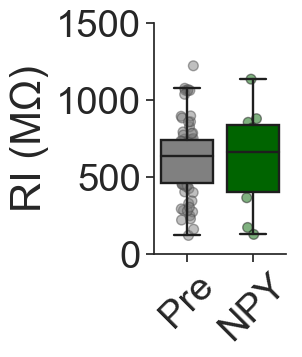

In [58]:
# RI + NPY

sns.set(rc={"figure.figsize": (1.7, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

ax = sns.boxplot(x='Behaviour_6hFD', y='Input_Resistance', data = ephys_npy, order=['Pre', 'npy_100'], saturation=8, 
                 linewidth=1.7, showfliers = False, palette = npy)
ax = sns.stripplot(x='Behaviour_6hFD', y='Input_Resistance', data = ephys_npy, order = ['Pre', 'npy_100'], jitter=True, 
                   dodge=False, marker='o', size=7, linewidth=1, edgecolor='gray', palette = npy, alpha=0.5, zorder=0)
ax.set_xlabel('')
ax.set_ylabel('RI (MΩ)', labelpad=5)

ax.set_xticklabels( ('Pre', 'NPY'), rotation=45)
ax.yaxis.set_major_locator(plt.MaxNLocator(3))
plt.ylim(0, 1500)
sns.despine(bottom=False, trim=False)

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, .5))
    
plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_7/linked_figure_S7/Ri_npy.pdf',
            dpi=300,bbox_inches='tight', transparent=True)

In [59]:
# Proportion of silent neurons 
cols = ['silent', 'phasic', 'tonic']
cat = ['Pre', 'npy_100']
silent_npy = proportion(ephys_npy[ephys_npy.Behaviour_6hFD.isin(cat)], 'Behaviour_6hFD', 'I_zero', cols)
silent_npy['Behaviour_6hFD'] = pd.Categorical(silent_npy['Behaviour_6hFD'], cat)
silent_npy = silent_npy.sort_values(by = ['Behaviour_6hFD'])

I_zero          phasic  silent  tonic  All
Behaviour_6hFD                            
Pre                 19      28     58  105
npy_100              2       7      2   11
All                 21      35     60  116
0.027963756691906115


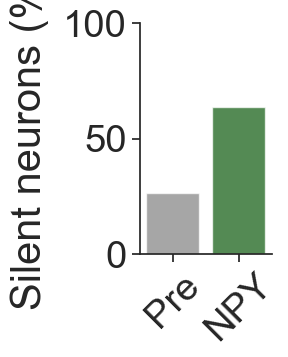

In [60]:
sns.set(rc={"figure.figsize": (1.7, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

g = sns.barplot(silent_npy, x="Behaviour_6hFD", y="silent", order=['Pre', 'npy_100'], palette = npy, alpha=0.7)
g.yaxis.set_major_locator(plt.MaxNLocator(3)) 
plt.ylabel('Silent neurons (%)', labelpad=10)
g.set_xticklabels(('Pre', 'NPY'), rotation=45)
plt.xlabel('')
plt.yticks(np.arange(0, 101, 50))
plt.ylim(0,100)
# ax.yaxis.set_major_locator(plt.MaxNLocator(5))
sns.despine()
plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_7/linked_figure_S7/silent_npy.pdf',
            dpi=300,bbox_inches='tight', transparent=True)

In [159]:
# subset df for those groups needed for firing freq. plot
ephys_npy_ff = ephys_npy.loc[(ephys_npy['Behaviour_6hFD'] == 'Pre') | (ephys_npy['Behaviour_6hFD'] == 'npy_100')]

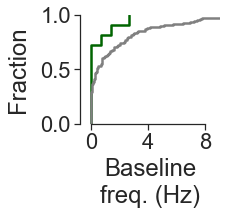

In [160]:
# Firing frequency
sns.set(rc={"figure.figsize": (2.5, 2.0)})
sns.set(font_scale=2) 
sns.set_style("ticks")

cum = sns.ecdfplot(data=ephys_npy_ff, x="Firing_freq_(Hz)_I0", hue="Behaviour_6hFD", palette = npy, linewidth=2.5, legend=False, stat='proportion')
cum.set_xlabel('Baseline\nfreq. (Hz)',labelpad=5)
cum.set_ylabel('Fraction',labelpad=10)
cum.xaxis.set_major_locator(plt.MaxNLocator(3))
plt.xlim(right=9)
sns.despine(trim=True)

plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_7/linked_figure_S7/ff_npy.pdf',
            dpi=300,bbox_inches='tight', transparent=True)

In [161]:
# stats U test
pre_ff = ephys_npy_ff[ephys_npy_ff['Behaviour_6hFD'] == 'Pre']['Firing_freq_(Hz)_I0'].dropna()
npy_ff = ephys_npy_ff[ephys_npy_ff['Behaviour_6hFD'] == 'npy_100']['Firing_freq_(Hz)_I0'].dropna()
u_statistic, p_value = mannwhitneyu(pre_ff, npy_ff)
print("Mann-Whitney U test p-value:", p_value)

Mann-Whitney U test p-value: 0.02323222231920088


# AgRP administration

In [162]:
# reload data and convert all instances of AgRP application to 'agrp'
# UPDATE: use the updated agrp_100 column!
ephys = pd.read_csv('sampled_ephys_data.csv')
ephys_agrp = ephys.copy()
ephys_agrp['Behaviour_6hFD'] = ephys_agrp['Behaviour_6hFD'].replace(['agrp_100_paired', 'agrp_100'], 'agrp')

In [163]:
print(f"Number of Pre neurons: {(ephys_agrp['Behaviour_6hFD'] == 'Pre').sum()} from {ephys_agrp[ephys_agrp['Behaviour_6hFD'] == 'Pre']['ID_mouse'].nunique()} mice")
print(f"Number of AgRP neurons: {(ephys_agrp['Behaviour_6hFD'] == 'agrp').sum()} from {ephys_agrp[ephys_agrp['Behaviour_6hFD'] == 'agrp']['ID_mouse'].nunique()} mice")

Number of Pre neurons: 107 from 17 mice
Number of AgRP neurons: 15 from 5 mice


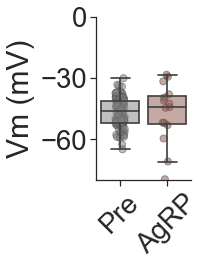

In [164]:
# Membrane voltage / RMP + AgRP

sns.set(rc={"figure.figsize": (1.7, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

ax = sns.boxplot(x='Behaviour_6hFD', y='Vm', data = ephys_agrp, order=['Pre', 'agrp'], saturation=8, 
                 linewidth=1.7, showfliers = False, palette = agrp)
ax = sns.stripplot(x='Behaviour_6hFD', y='Vm', data = ephys_agrp, order = ['Pre', 'agrp'], jitter=True, 
                   dodge=False, marker='o', size=7, linewidth=1, edgecolor='gray', palette = agrp, alpha=0.5, zorder=0)
ax.set_xlabel('')
ax.set_ylabel('Vm (mV)', labelpad=5)

ax.set_xticklabels( ('Pre', 'AgRP'), rotation=45)
ax.yaxis.set_major_locator(plt.MaxNLocator(3))
plt.ylim(-80, 0)
sns.despine(bottom=False, trim=False)

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, .5))
    
# plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_7/linked_figure_S7/Vm_agrp.pdf',
#             dpi=300,bbox_inches='tight', transparent=True)

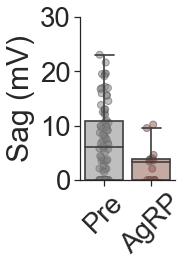

In [165]:
# Ih + AgRP

sns.set(rc={"figure.figsize": (1.7, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

ax = sns.boxplot(x='Behaviour_6hFD', y='Ih_at_-120mV', data = ephys_agrp, order=['Pre', 'agrp'], saturation=8, 
                 linewidth=1.7, showfliers = False, palette = agrp)
ax = sns.stripplot(x='Behaviour_6hFD', y='Ih_at_-120mV', data = ephys_agrp, order = ['Pre', 'agrp'], jitter=True, 
                   dodge=False, marker='o', size=7, linewidth=1, edgecolor='gray', palette = agrp, alpha=0.5, zorder=0)
ax.set_xlabel('')
ax.set_ylabel('Sag (mV)', labelpad=5)

ax.set_xticklabels( ('Pre', 'AgRP'), rotation=45)
ax.yaxis.set_major_locator(plt.MaxNLocator(3))
plt.ylim(0, 30)
sns.despine(bottom=False, trim=False)

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, .5))
    
plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_7/linked_figure_S7/Ih_agrp.pdf',
            dpi=300,bbox_inches='tight', transparent=True)

In [166]:
# stats U test
pre_sag = ephys_agrp[ephys_agrp['Behaviour_6hFD'] == 'Pre']['Ih_at_-120mV'].dropna()
agrp_sag = ephys_agrp[ephys_agrp['Behaviour_6hFD'] == 'agrp']['Ih_at_-120mV'].dropna()
u_statistic, p_value = mannwhitneyu(pre_sag, agrp_sag)
print("Mann-Whitney U test p-value:", p_value)

Mann-Whitney U test p-value: 0.04600857530752238


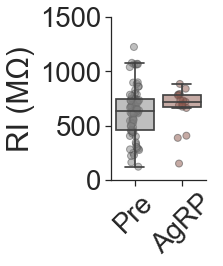

In [167]:
# RI + NPY

sns.set(rc={"figure.figsize": (1.7, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

ax = sns.boxplot(x='Behaviour_6hFD', y='Input_Resistance', data = ephys_agrp, order=['Pre', 'agrp'], saturation=8, 
                 linewidth=1.7, showfliers = False, palette = agrp)
ax = sns.stripplot(x='Behaviour_6hFD', y='Input_Resistance', data = ephys_agrp, order = ['Pre', 'agrp'], jitter=True, 
                   dodge=False, marker='o', size=7, linewidth=1, edgecolor='gray', palette = agrp, alpha=0.5, zorder=0)
ax.set_xlabel('')
ax.set_ylabel('RI (MΩ)', labelpad=5)

ax.set_xticklabels( ('Pre', 'AgRP'), rotation=45)
ax.yaxis.set_major_locator(plt.MaxNLocator(3))
plt.ylim(0, 1500)
sns.despine(bottom=False, trim=False)

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, .5))
    
# plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_7/linked_figure_S7/Ri_agrp.pdf',
#             dpi=300,bbox_inches='tight', transparent=True)

In [168]:
# stats U test
pre_ri = ephys_agrp[ephys_agrp['Behaviour_6hFD'] == 'Pre']['Input_Resistance'].dropna()
agrp_ri = ephys_agrp[ephys_agrp['Behaviour_6hFD'] == 'agrp']['Input_Resistance'].dropna()
u_statistic, p_value = mannwhitneyu(pre_ri, agrp_ri)
print("Mann-Whitney U test p-value:", p_value)

Mann-Whitney U test p-value: 0.2105021892393052


In [169]:
# Proportion of silent neurons 
cols = ['silent', 'phasic', 'tonic']
cat = ['Pre', 'agrp']
silent_agrp = proportion(ephys_agrp[ephys_agrp.Behaviour_6hFD.isin(cat)], 'Behaviour_6hFD', 'I_zero', cols)
silent_agrp['Behaviour_6hFD'] = pd.Categorical(silent_agrp['Behaviour_6hFD'], cat)
silent_agrp = silent_agrp.sort_values(by = ['Behaviour_6hFD'])

I_zero          phasic  silent  tonic  All
Behaviour_6hFD                            
Pre                 19      28     58  105
agrp                 2       5      8   15
All                 21      33     66  120
0.8224861593723192


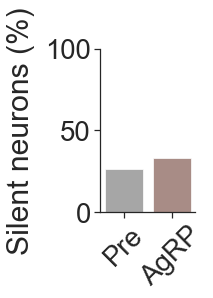

In [ ]:
sns.set(rc={"figure.figsize": (1.7, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

g = sns.barplot(silent_agrp, x="Behaviour_6hFD", y="silent", order=['Pre', 'agrp'], palette = agrp, alpha=0.7)
g.yaxis.set_major_locator(plt.MaxNLocator(3)) 
plt.ylabel('Silent neurons (%)', labelpad=10)
g.set_xticklabels(('Pre', 'AgRP'), rotation=45)
plt.xlabel('')
plt.yticks(np.arange(0, 101, 50))
plt.ylim(0,100)
sns.despine()
plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_7/linked_figure_S7/silent_agrp.pdf',
            dpi=300,bbox_inches='tight', transparent=True)

In [171]:
# subset df for those groups needed for firing freq. plot
ephys_agrp_ff = ephys_agrp.loc[(ephys_agrp['Behaviour_6hFD'] == 'Pre') | (ephys_agrp['Behaviour_6hFD'] == 'agrp')]

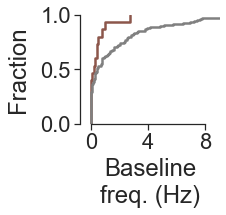

In [172]:
# Firing frequency
sns.set(rc={"figure.figsize": (2.5, 2.0)})
sns.set(font_scale=2) 
sns.set_style("ticks")

cum = sns.ecdfplot(data=ephys_agrp_ff, x="Firing_freq_(Hz)_I0", hue="Behaviour_6hFD", palette = agrp, linewidth=2.5, legend=False, stat='proportion')
cum.set_xlabel('Baseline\nfreq. (Hz)',labelpad=5)
cum.set_ylabel('Fraction',labelpad=10)
cum.xaxis.set_major_locator(plt.MaxNLocator(3))
plt.xlim(right=9)
sns.despine(trim=True)

plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_7/linked_figure_S7/ff_agrp.pdf',
            dpi=300,bbox_inches='tight', transparent=True)

In [173]:
# stats U test
pre_ff = ephys_agrp_ff[ephys_agrp_ff['Behaviour_6hFD'] == 'Pre']['Firing_freq_(Hz)_I0'].dropna()
agrp_ff = ephys_agrp_ff[ephys_agrp_ff['Behaviour_6hFD'] == 'agrp']['Firing_freq_(Hz)_I0'].dropna()
u_statistic, p_value = mannwhitneyu(pre_ff, agrp_ff)
print("Mann-Whitney U test p-value:", p_value)

Mann-Whitney U test p-value: 0.08952854221309393


# ZD7288 administration

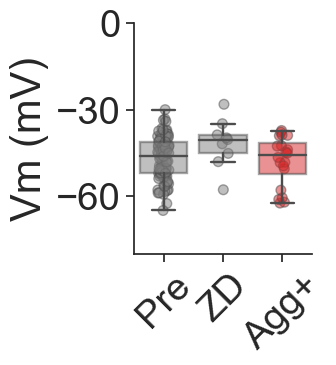

In [95]:
sns.set(rc={"figure.figsize": (2.3, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

ax = sns.boxplot(x='Behaviour_6hFD', y='Vm', data = ephys, order=['Pre', 'ZD7288', 'Agg+'], saturation=8, 
                 linewidth=1.7, showfliers = False, palette = ['gray', 'gray', 'Tab:red'], boxprops=dict(alpha=.5))
ax = sns.stripplot(x='Behaviour_6hFD', y='Vm', data = ephys, order = ['Pre', 'ZD7288', 'Agg+'], jitter=True, 
                   dodge=False, marker='o', size=7, linewidth=1, edgecolor='gray', palette = ['gray', 'gray', 'Tab:red'], alpha=0.5, zorder=0)
ax.set_xlabel('')
ax.set_ylabel('Vm (mV)', labelpad=5)

ax.set_xticklabels( ('Pre', 'ZD', 'Agg+'), rotation=45)
ax.yaxis.set_major_locator(plt.MaxNLocator(3))
plt.ylim(-80, 0)
sns.despine(bottom=False, trim=False)

    
plt.savefig('/Volumes/lab-kohlj/home/shared/people/Mingran/theis_figure/Figure3/linked_figure3/Vm_ZD.pdf',
            dpi=300,bbox_inches='tight', transparent=True)

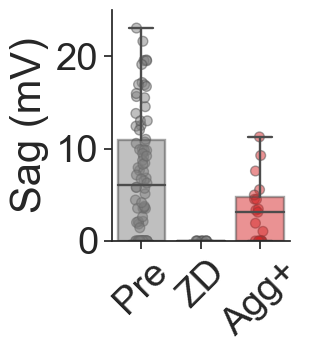

In [96]:
ax = sns.boxplot(x='Behaviour_6hFD', y='Ih_at_-120mV', data = ephys, order=['Pre', 'ZD7288', 'Agg+'], saturation=8, 
                 linewidth=1.7, showfliers = False, palette = ['gray', 'gray', 'Tab:red'], boxprops=dict(alpha=.5))
ax = sns.stripplot(x='Behaviour_6hFD', y='Ih_at_-120mV', data = ephys, order = ['Pre', 'ZD7288', 'Agg+'], jitter=True, 
                   dodge=False, marker='o', size=7, linewidth=1, edgecolor='gray', palette = ['gray', 'gray', 'Tab:red'], alpha=0.5, zorder=0)
ax.set_xlabel('')
ax.set_ylabel('Vm (mV)', labelpad=5)

ax.set_xticklabels( ('Pre', 'ZD', 'Agg+'), rotation=45)
ax.yaxis.set_major_locator(plt.MaxNLocator(3))
plt.ylim( 0, 25)
sns.despine(bottom=False, trim=False)
ax.set_xlabel('')
ax.set_ylabel('Sag (mV)', labelpad=5)

    
plt.savefig('/Volumes/lab-kohlj/home/shared/people/Mingran/theis_figure/Figure3/linked_figure3/Sag_ZD.pdf',
            dpi=300,bbox_inches='tight', transparent=True)

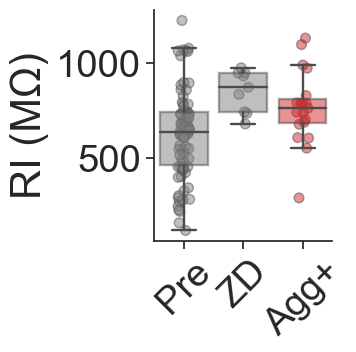

In [97]:
ax = sns.boxplot(x='Behaviour_6hFD', y='Input_Resistance', data = ephys, order=['Pre', 'ZD7288', 'Agg+'], saturation=8, 
                 linewidth=1.7, showfliers = False, palette = ['gray', 'gray', 'Tab:red'], boxprops=dict(alpha=.5))
ax = sns.stripplot(x='Behaviour_6hFD', y='Input_Resistance', data = ephys, order = ['Pre', 'ZD7288', 'Agg+'], jitter=True, 
                   dodge=False, marker='o', size=7, linewidth=1, edgecolor='gray', palette = ['gray', 'gray', 'Tab:red'], alpha=0.5, zorder=0)
ax.set_xlabel('')
ax.set_ylabel('RI (MΩ)', labelpad=5)

ax.set_xticklabels( ('Pre', 'ZD', 'Agg+'), rotation=45)
ax.yaxis.set_major_locator(plt.MaxNLocator(3))

sns.despine(bottom=False, trim=False)

plt.savefig('/Volumes/lab-kohlj/home/shared/people/Mingran/theis_figure/Figure3/linked_figure3/IR_ZD.pdf',
            dpi=300,bbox_inches='tight', transparent=True)


In [10]:
cols = ['silent', 'phasic', 'tonic']
cat = ['Pre', 'ZD7288', 'Agg+']
silent_ZD = proportion(ephys[ephys.Behaviour_6hFD.isin(cat)], 'Behaviour_6hFD', 'I_zero', cols)
silent_ZD['Behaviour_6hFD'] = pd.Categorical(silent_ZD['Behaviour_6hFD'], cat)
silent_ZD = silent_ZD.sort_values(by = ['Behaviour_6hFD'])

I_zero          phasic  silent  tonic  All
Behaviour_6hFD                            
Agg+                 6       9      5   20
Pre                 19      28     58  105
ZD7288               0       8      1    9
All                 25      45     64  134
0.0006337658864808178


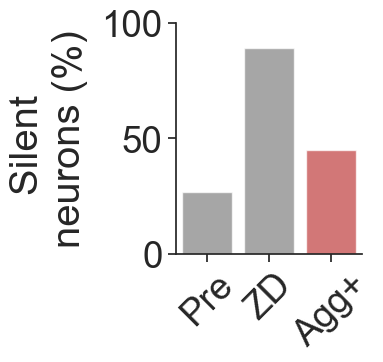

In [102]:

plt.subplots(figsize=(2.4, 3))
sns.set(font_scale=2.4) 
sns.set_style("ticks")


g = sns.barplot(silent_ZD, x="Behaviour_6hFD", y="silent", order=['Pre', 'ZD7288', 'Agg+'], palette = ['gray', 'gray', 'Tab:red'], alpha=0.7)
g.yaxis.set_major_locator(plt.MaxNLocator(3)) 
plt.ylabel('Silent \nneurons (%)', labelpad=10)
g.set_xticklabels(('Pre', 'ZD', 'Agg+'), rotation=45)
plt.xlabel('')
plt.yticks(np.arange(0, 101, 50))
plt.ylim(0,100)
sns.despine()


plt.savefig('/Volumes/lab-kohlj/home/shared/people/Mingran/theis_figure/Figure3/linked_figure3/Silent_ZD.pdf',
            dpi=300,bbox_inches='tight', transparent=True)

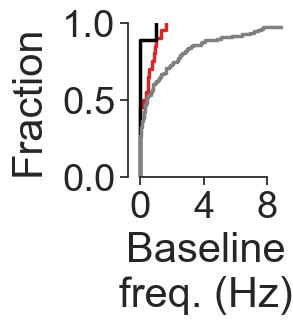

In [137]:
plt.subplots(figsize=(2., 2))
ZD_ff = ephys[ephys.Behaviour_6hFD.isin(['Pre', 'ZD7288', 'Agg+'])]

cum = sns.ecdfplot(data= ZD_ff, x="Firing_freq_(Hz)_I0", hue="Behaviour_6hFD",hue_order=['Pre', 'ZD7288', 'Agg+'], palette = ['gray', 'black', 'Tab:red'], linewidth=2.5, legend=False, stat='proportion')
cum.set_xlabel('Baseline\nfreq. (Hz)',labelpad=5)
cum.set_ylabel('Fraction',labelpad=10)
cum.xaxis.set_major_locator(plt.MaxNLocator(3))
plt.xlim(right=9)
sns.despine(trim=True)

plt.savefig('/Volumes/lab-kohlj/home/shared/people/Mingran/theis_figure/Figure3/linked_figure3/ff_ZD.pdf',
            dpi=300,bbox_inches='tight', transparent=True)